# SMS Spam Detection - Comprehensive Study
## Classical ML vs Ensemble Learning vs Deep Learning

In [1]:
# IMPORTS AND SETUP 
# =============================================================================

# 1. CORE DATA & VISUALIZATION
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import shutil
import os
# Hardware monitoring
import psutil
import time
from datetime import timedelta, datetime
from matplotlib.patches import Patch

# 2. NLP & TEXT PROCESSING
import re, string, emoji, unicodedata
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
from bs4 import BeautifulSoup

# 3. SKLEARN - CLASSICAL & ENSEMBLE MODELS
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
)
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.base import clone

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix,
    average_precision_score, matthews_corrcoef, cohen_kappa_score,
    roc_curve, auc, ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# 4. DEEP LEARNING (KERAS – STABLE)
import tensorflow as tf
import keras

from keras.models import Sequential
from keras.layers import (
    LSTM, GRU, Dense, Embedding, Dropout,
    Conv1D, GlobalMaxPooling1D, Bidirectional
)

from keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences 
from keras.callbacks import EarlyStopping, ReduceLROnPlateau


# 5. TRANSFORMERS (HuggingFace – TF Models)
from transformers import (
    DistilBertTokenizer,
    TFDistilBertForSequenceClassification,
    logging as transformers_logging
)

# 6. Energy & Carbon tracking
try:
    from codecarbon import EmissionsTracker
    CODECARBON_AVAILABLE = True
    print("✅ CodeCarbon available for energy tracking")
except ImportError:
    CODECARBON_AVAILABLE = False
    print("⚠️ CodeCarbon not installed")

# 7. CONFIGURATION
import warnings
warnings.filterwarnings("ignore")
transformers_logging.set_verbosity_error()

print("✅ All libraries imported successfully (TF 2.10 + Keras 2.10 + HF stable)")

✅ CodeCarbon available for energy tracking
✅ All libraries imported successfully (TF 2.10 + Keras 2.10 + HF stable)


In [2]:
# ====================================================================================
# GLOBAL MODULAR UTILITIES 
# ====================================================================================

if 'model_results' not in globals():
    model_results = {}

if 'model_time_results' not in globals():
    model_time_results = {}

# ====================================================================================
# CARBON EMISSION FACTOR (CEF) — IEA 2024, Turkey National Grid
# ====================================================================================
# Source: IEA Emissions Factors 2024
# Turkey grid mix: ~33% coal, ~21% gas, ~17% hydro (fossil-heavy)
# CEF dynamically confirmed by CodeCarbon v3.2.2 during experiments (measured: 0.465)
CEF_KG_PER_KWH   = 0.465   # kg CO2/kWh  — used in all energy/CO2 calculations
CEF_GCO2_PER_KWH = 465     # gCO2/kWh    — used in paper tables and reporting

# ====================================================================================
# TIME UTILITIES
# ====================================================================================
def format_time(seconds):
    if seconds < 1:
        return f"{seconds * 1000:.3f} ms"
    return f"{seconds:.4f} sec"

class TimeTracker:
    def __init__(self):
        self._starts = {}

    def start(self, key):
        self._starts[key] = time.perf_counter()

    def stop(self, key):
        return time.perf_counter() - self._starts[key]

timer = TimeTracker()

# ====================================================================================
# THRESHOLD OPTIMIZATION (simple — for backward compatibility)
# ====================================================================================
def optimize_threshold_cv(model, X, y, cv=5):
    cv_pred_proba = cross_val_predict(
        model, X, y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    thresholds = np.linspace(0.05, 0.95, 100)
    mcc_scores = [
        matthews_corrcoef(y, (cv_pred_proba >= t).astype(int))
        for t in thresholds
    ]

    best_idx = np.argmax(mcc_scores)
    return thresholds[best_idx], mcc_scores[best_idx]

# Inference latency (simple — kept for backward compatibility)
def measure_inference_latency(model, X):
    # Sparse matrix check
    if hasattr(X, 'toarray'):
        X = X.toarray()
    # Warm-up
    model.predict_proba(X[:5])
    start = time.perf_counter()
    for i in range(X.shape[0]):
        model.predict_proba(X[i:i+1])
    end = time.perf_counter()
    total = end - start
    latency_ms = (total / X.shape[0]) * 1000
    return total, latency_ms

# ====================================================================================
# METRICS COMPUTATION
# ====================================================================================
def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    return {
        "Accuracy":         accuracy_score(y_true, y_pred),
        "Precision":        precision_score(y_true, y_pred),
        "Recall":           recall_score(y_true, y_pred),
        "F1_Score":         f1_score(y_true, y_pred),
        "MCC":              matthews_corrcoef(y_true, y_pred),
        "Kappa":            cohen_kappa_score(y_true, y_pred),
        "Specificity":      tn / (tn + fp) if (tn + fp) > 0 else 0,
        "ROC_AUC":          roc_auc_score(y_true, y_prob),
        "PR_AUC":           average_precision_score(y_true, y_prob),
        "Confusion_Matrix": np.array([[tn, fp], [fn, tp]])
    }

def print_metrics(metrics, threshold):
    print(f"\n✓ Accuracy (Threshold {threshold:.2f}): {metrics['Accuracy']:.4f}")
    print(f"✓ F1-Score:      {metrics['F1_Score']:.4f}")
    print(f"✓ ROC-AUC Score: {metrics['ROC_AUC']:.4f}")
    print(f"✓ PR-AUC Score:  {metrics['PR_AUC']:.4f}")
    print(f"✓ MCC Score:     {metrics['MCC']:.4f}")
    print(f"✓ Cohen's Kappa: {metrics['Kappa']:.4f}")
    print(f"✓ Specificity:   {metrics['Specificity']:.4f}")

def plot_confusion_matrix(cm, model_name, threshold, cmap='Blues'):
    plt.figure(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Ham', 'Spam']
    ).plot(cmap=plt.cm.get_cmap(cmap), values_format='d', ax=plt.gca())
    plt.title(f"{model_name} Confusion Matrix (Threshold {threshold:.2f})", fontsize=11)
    plt.grid(False)
    plt.tight_layout()
    plt.show()

# ====================================================================================
# MODEL SIZE
# ====================================================================================
def get_model_size_mb(model):
    tmp = "_tmp_model.pkl"
    joblib.dump(model, tmp)
    size = os.path.getsize(tmp) / (1024 * 1024)
    os.remove(tmp)
    return size

# ====================================================================================
# CREATE DL MODEL (LSTM, GRU, CNN)
# ====================================================================================
def create_model(model_type='lstm'):
    tf.keras.backend.clear_session()
    vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
    # Embedding layer (common to all models)
    layers = [Embedding(input_dim=vocab_size, output_dim=128, input_length=MAX_LEN)]
    # Architecture layers (model-specific)
    if model_type == 'lstm':
        layers.extend([
            Bidirectional(LSTM(64, return_sequences=True)),
            Dropout(0.5),
            Bidirectional(LSTM(32)),
            Dropout(0.5)
        ])
    elif model_type == 'gru':
        layers.extend([
            Bidirectional(GRU(64, return_sequences=True)),
            Dropout(0.5),
            Bidirectional(GRU(32)),
            Dropout(0.5)
        ])
    elif model_type == 'cnn':
        layers.extend([
            Conv1D(128, 5, activation='relu'),
            Dropout(0.5),
            Conv1D(64, 3, activation='relu'),
            GlobalMaxPooling1D(),
            Dropout(0.5)
        ])
    else:
        raise ValueError(f"Invalid model type: {model_type}. Must be 'lstm', 'gru', or 'cnn'.")
    # Output layers (common to all models)
    layers.extend([
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model = Sequential(layers)
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# ====================================================================================
# TRACK MODEL TRAINING
# Measures TRAINING energy, CO2, RAM and timing via CodeCarbon.
# X_test is required for energy_per_1000_train_wh calculation.
# NOTE: Inference energy is measured separately in measure_inference_extended().
# ====================================================================================
def track_model_training(model, X_train, y_train, X_test, model_name="Model", **kwargs):
    process = psutil.Process(os.getpid())

    # RAM baseline before training
    ram_baseline = process.memory_info().rss / (1024 * 1024)

    # ── START TRAINING ENERGY TRACKER ────────────────────────────────────────
    if CODECARBON_AVAILABLE:
        tracker = EmissionsTracker(
            project_name=f"SMS_Spam_{model_name}",
            log_level="error"
        )
        tracker.start()

    # ── TRAINING ──────────────────────────────────────────────────────────────
    timer.start(f"{model_name}_train_internal")
    model.fit(X_train, y_train, **kwargs)
    training_time = timer.stop(f"{model_name}_train_internal")

    # ── STOP TRAINING TRACKER ─────────────────────────────────────────────────
    # FIX: stop_and_get() provides direct access to the EmissionsData object.
    # Previous version incorrectly used: energy_kwh = emissions_data * 0.35
    # energy_consumed is directly measured by CodeCarbon hardware sensors (CPU+GPU+RAM).
    training_co2_kg     = 0.0
    training_energy_kwh = 0.0
    if CODECARBON_AVAILABLE:
        try:
            training_co2_kg = float(tracker.stop() or 0.0)
            if hasattr(tracker, 'final_emissions_data') and tracker.final_emissions_data:
                training_energy_kwh = float(tracker.final_emissions_data.energy_consumed)
        except Exception as e:
            print(f"⚠️ CodeCarbon training tracking error: {e}")
            

    # ── RAM AFTER TRAINING ────────────────────────────────────────────────────
    ram_peak    = process.memory_info().rss / (1024 * 1024)
    cpu_percent = psutil.cpu_percent(interval=0.1)

    # GPU utilization and memory
    gpu_used      = False
    gpu_memory_mb = None
    try:
        import GPUtil
        gpus = GPUtil.getGPUs()
        if gpus:
            gpu_used      = True
            gpu_memory_mb = gpus[0].memoryUsed
    except:
        pass

    # ── ENERGY PER 1000 TRAINING SAMPLES (Wh) ────────────────────────────────
    # Training cost scaled to 1000 samples — reported in paper Table 5 (train column).
    # Formula: training_energy_kWh x 1000 (kWh->Wh) x 1000 (scale to 1000) / n_train
    # Note: for classical ML models (<2s training), this value includes
    # model-loading overhead and should be interpreted as an upper bound.
    n_train = X_train.shape[0]
    energy_per_1000_train_wh = (training_energy_kwh * 1e6) / n_train if n_train > 0 else 0.0

    return {
        # Training energy (CodeCarbon measured)
        "training_co2_kg":          training_co2_kg,
        "training_energy_kwh":      training_energy_kwh,
        "energy_per_1000_train_wh": energy_per_1000_train_wh,
        # Timing
        "training_time":            training_time,
        # CEF (IEA 2024, Turkey national grid)
        "CEF_kg_per_kWh":           CEF_KG_PER_KWH,    # 0.465 kg CO2/kWh
        "CEF_gCO2_per_kWh":         CEF_GCO2_PER_KWH,  # 465 gCO2/kWh
        # RAM
        "ram_baseline_mb":          ram_baseline,
        "ram_peak_mb":              ram_peak,
        # Hardware
        "cpu_utilization":          cpu_percent,
        "gpu_used":                 gpu_used,
        "gpu_memory_mb":            gpu_memory_mb,
    }


# ====================================================================================
# Returns energy_per_1000_pred_wh and co2_per_1M_pred_kg.
# ====================================================================================
def measure_inference_extended(model, X_test, model_name="Model"):
    process = psutil.Process(os.getpid())

    # FIX: Convert sparse to dense for fast per-sample inference
    # Sparse matrix slicing is slow for sklearn models
    if hasattr(X_test, 'toarray'):
        X_test = X_test.toarray().astype('float32')

    # ── WARM-UP (excluded from energy measurement) ───────────────────────────
    warmup = X_test[:10]
    if hasattr(model, 'predict_proba'):
        model.predict_proba(warmup)
    else:
        model.predict(warmup)

    # ── RAM BEFORE INFERENCE ──────────────────────────────────────────────────
    ram_before_inf = process.memory_info().rss / (1024 * 1024)

    # ── START INFERENCE ENERGY TRACKER ───────────────────────────────────────
    if CODECARBON_AVAILABLE:
        inf_tracker = EmissionsTracker(
            project_name=f"SMS_Spam_{model_name}_inference",
            log_level="error"
        )
        inf_tracker.start()

    # ── PER-SAMPLE LATENCY LOOP ───────────────────────────────────────────────
    latencies = []
    for i in range(X_test.shape[0]):
        t0 = time.perf_counter()
        if hasattr(model, 'predict_proba'):
            model.predict_proba(X_test[i:i+1])
        else:
            model.predict(X_test[i:i+1])
        latencies.append((time.perf_counter() - t0) * 1000)

    latencies = np.array(latencies)

    # ── STOP INFERENCE TRACKER ───────────────────────────────────────────────
    inference_co2_kg     = 0.0
    inference_energy_kwh = 0.0
    if CODECARBON_AVAILABLE:
        try:
            inference_co2_kg = float(inf_tracker.stop() or 0.0)
            if hasattr(inf_tracker, 'final_emissions_data') and inf_tracker.final_emissions_data:
                inference_energy_kwh = float(inf_tracker.final_emissions_data.energy_consumed)
        except Exception as e:
            print(f"⚠️ CodeCarbon inference tracking error: {e}")

    # ── RAM AFTER INFERENCE ───────────────────────────────────────────────────
    ram_after_inf    = process.memory_info().rss / (1024 * 1024)
    ram_inference_mb = max(0.0, ram_after_inf - ram_before_inf)

    # ── DERIVED GREEN AI METRICS ──────────────────────────────────────────────
    n_test = X_test.shape[0]

    # Energy per 1000 predictions (Wh) — Table 5
    energy_per_1000_pred_wh = (inference_energy_kwh * 1e6) / n_test if n_test > 0 else 0.0

    # CO2 per 1M predictions (kg) — Table 7
    co2_per_1M_pred_kg = (inference_co2_kg / n_test) * 1_000_000 if n_test > 0 else 0.0

    return {
        "inference_time_total": float(np.sum(latencies) / 1000),
        "latency_mean_ms":      float(np.mean(latencies)),
        "latency_median_ms":    float(np.median(latencies)),
        "latency_std_ms":       float(np.std(latencies)),
        "latency_min_ms":       float(np.min(latencies)),
        "latency_max_ms":       float(np.max(latencies)),
        "latency_p50_ms":       float(np.percentile(latencies, 50)),
        "latency_p95_ms":       float(np.percentile(latencies, 95)),
        "latency_p99_ms":       float(np.percentile(latencies, 99)),
        "inference_co2_kg":     inference_co2_kg,
        "inference_energy_kwh": inference_energy_kwh,
        "energy_per_1000_pred_wh": energy_per_1000_pred_wh,
        "co2_per_1M_pred_kg":      co2_per_1M_pred_kg,
        "ram_inference_mb":     ram_inference_mb,
    }

# ====================================================================================
# OPTIMIZE THRESHOLD (extended — with CV stability metrics)
# ====================================================================================
def optimize_threshold_cv_extended(model, X, y, cv=5, max_fit_time=30):
    from sklearn.model_selection import cross_val_predict, StratifiedKFold
    import time

    # Out-of-fold probability predictions (single CV pass — used for both
    # threshold optimisation and stability metrics to ensure consistency)
    t_start = time.perf_counter()
    cv_pred_proba = cross_val_predict(
        model, X, y,
        cv=cv,
        method='predict_proba',
        n_jobs=-1
    )[:, 1]
    elapsed_cv = time.perf_counter() - t_start
    print(f"   cross_val_predict completed in {elapsed_cv:.1f}s")

    # Find threshold that maximises MCC
    thresholds = np.linspace(0.05, 0.95, 100)
    mcc_scores = []
    for t in thresholds:
        preds = (cv_pred_proba >= t).astype(int)
        mcc_scores.append(matthews_corrcoef(y, preds))

    best_idx          = np.argmax(mcc_scores)
    optimal_threshold = thresholds[best_idx]
    max_mcc_cv        = mcc_scores[best_idx]

    # CV stability metrics — derived directly from OOF predictions (no additional fitting)
    # This ensures full consistency with the threshold optimisation step above.
    # Per-fold metrics are computed by splitting OOF probabilities back into their
    # original validation folds using the same StratifiedKFold configuration.
    kfold           = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    fold_accuracies = []
    fold_mccs       = []

    for train_idx_f, val_idx_f in kfold.split(X, y):
        fold_preds = (cv_pred_proba[val_idx_f] >= optimal_threshold).astype(int)
        fold_accuracies.append(accuracy_score(y[val_idx_f], fold_preds))
        fold_mccs.append(matthews_corrcoef(y[val_idx_f], fold_preds))

    cv_metrics = {
        "cv_accuracy_mean": float(np.mean(fold_accuracies)),
        "cv_accuracy_std":  float(np.std(fold_accuracies)),
        "cv_mcc_mean":      float(np.mean(fold_mccs)),
        "cv_mcc_std":       float(np.std(fold_mccs)),
    }

    return optimal_threshold, max_mcc_cv, cv_metrics

# ====================================================================================
# CSV EXPORT
# ====================================================================================
def export_results_to_csv(model_results_dict, filename="sms_spam_results.csv", append=True):
    df_export = pd.DataFrame(model_results_dict).T
    df_export.reset_index(inplace=True)
    df_export.rename(columns={'index': 'Model'}, inplace=True)
    file_exists = os.path.isfile(filename)
    if file_exists and append:
        df_export.to_csv(filename, mode='a', header=False, index=False)
        print(f"    ✓ Added to CSV: {filename}")
    else:
        df_export.to_csv(filename, mode='w', header=True, index=False)
        print(f"    ✓ CSV created: {filename}")


print("✅ Global modular utilities initialized")
print(f"   CEF = {CEF_KG_PER_KWH} kg CO2/kWh = {CEF_GCO2_PER_KWH} gCO2/kWh (IEA 2024, Turkey)")
print("   track_model_training       -> training CO2, energy (CodeCarbon), RAM")
print("   measure_inference_extended -> inference CO2, energy, latency, CO2/1M pred")   

✅ Global modular utilities initialized
   CEF = 0.465 kg CO2/kWh = 465 gCO2/kWh (IEA 2024, Turkey)
   track_model_training       -> training CO2, energy (CodeCarbon), RAM
   measure_inference_extended -> inference CO2, energy, latency, CO2/1M pred


In [3]:
#!pip install timer
#nltk.download("all")
#!pip install wordcloud
#!pip install emoji

In [4]:
URL_PATTERN   = re.compile(r'https?://\S+|www\.\S+')
EMAIL_PATTERN = re.compile(r'\b[\w\.-]+@[\w\.-]+\.\w+\b')
PHONE_PATTERN = re.compile(r'\+?\d[\d\s\-]{7,}\d')
NUM_PATTERN   = re.compile(r'\d+')

In [5]:
def core_preprocess(text):
    if pd.isna(text) or text == "":
        return ""

    text = str(text)

    # HTML cleaning
    text = BeautifulSoup(text, "html.parser").get_text()

    # Emoji → text
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Unicode + lowercase
    text = unicodedata.normalize("NFKC", text).lower()

    # Pattern masking
    text = URL_PATTERN.sub(" <URL> ", text)
    text = EMAIL_PATTERN.sub(" <EMAIL> ", text)
    text = PHONE_PATTERN.sub(" <PHONE> ", text)
    text = NUM_PATTERN.sub(" <NUM> ", text)

    # Character repetitions
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # Removing spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [6]:
df = pd.read_csv("spam.csv", encoding="cp1252")

# Unnecessary columns
df = df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], errors="ignore")

# Column headers
df = df.rename(columns={"v1": "target", "v2": "text"})

# Label encoding
df["target"] = df["target"].map({"ham": 0, "spam": 1})

# Duplicate check (is there any label conflict?)
conflict_dups = (
    df.groupby("text")["target"]
      .nunique()
      .reset_index()
)

conflict_dups = conflict_dups[conflict_dups["target"] > 1]

print(f"Conflicting duplicate texts: {len(conflict_dups)}")

# Removing duplicates
print(f"Before duplicates len: {len(df)}")
df = df.drop_duplicates(subset=["text"], keep="first").reset_index(drop=True)
print(f"After duplicates len: {len(df)}")

df.head(10)

Conflicting duplicate texts: 0
Before duplicates len: 5572
After duplicates len: 5169


,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
5,1,FreeMsg Hey there darling it's been 3 week's n...
6,0,Even my brother is not like to speak with me. ...
7,0,As per your request 'Melle Melle (Oru Minnamin...
8,1,WINNER!! As a valued network customer you have...
9,1,Had your mobile 11 months or more? U R entitle...


In [7]:
df.describe(include="all")

,target,text
count,5169.000000,5169
unique,NaN,5169
top,NaN,"Go until jurong point, crazy.. Available only ..."
freq,NaN,1
mean,0.126330,NaN
std,0.332253,NaN
min,0.000000,NaN
25%,0.000000,NaN
50%,0.000000,NaN
75%,0.000000,NaN


In [8]:
df["text_length"] = df["text"].str.len()
df.groupby("target")["text_length"].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
0,4516.0,70.459256,56.358207,2.0,34.0,52.0,90.0,910.0
1,653.0,137.891271,30.137753,13.0,132.0,149.0,157.0,224.0


In [9]:
# Class distribution after cleaning
print(df['target'].value_counts())
print(df['target'].value_counts(normalize=True) * 100)

target
0    4516
1     653
Name: count, dtype: int64
target
0    87.366996
1    12.633004
Name: proportion, dtype: float64


In [10]:
# Character length statistics
print(df.groupby('target')['text_length'].describe())

         count        mean        std   min    25%    50%    75%    max
target                                                                 
0       4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0
1        653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0


In [11]:
# Calculate word count
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
print(df.groupby('target')['word_count'].describe())

         count       mean        std  min   25%   50%   75%    max
target                                                            
0       4516.0  14.134632  11.116240  1.0   7.0  11.0  18.0  171.0
1        653.0  23.681470   5.967672  2.0  22.0  25.0  28.0   35.0


In [12]:
df.isna().sum()

target         0
text           0
text_length    0
word_count     0
dtype: int64

In [13]:
df["target"].value_counts().rename(index={0: "ham", 1: "spam"})

target
ham     4516
spam     653
Name: count, dtype: int64

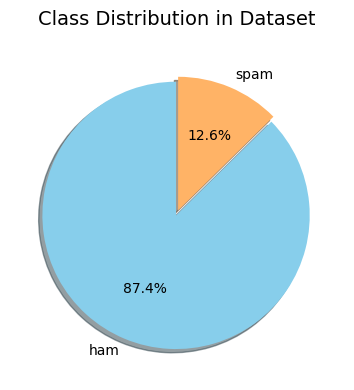

In [14]:
counts = df["target"].value_counts().rename(index={0: "ham", 1: "spam"})

colors = ['#87CEEB', '#FFB366']

plt.figure(figsize=(4, 4))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    explode=[0.02]*len(counts),
    shadow=True
)

plt.title("Class Distribution in Dataset", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [15]:
# Chat / SMS slang dictionary
# Source: https://github.com/rishabhverma17/sms_slang_translator
# Used only for classical machine learning models
# Slang expansion is applied to improve lexical coverage in TF-IDF based models

chat_words = {
    "AFAIK": "As Far As I Know",
    "AFK": "Away From Keyboard",
    "ASAP": "As Soon As Possible",
    "ATK": "At The Keyboard",
    "ATM": "At The Moment",
    "A3": "Anytime, Anywhere, Anyplace",
    "BAK": "Back At Keyboard",
    "BBL": "Be Back Later",
    "BBS": "Be Back Soon",
    "BFN": "Bye For Now",
    "B4N": "Bye For Now",
    "BRB": "Be Right Back",
    "BRT": "Be Right There",
    "BTW": "By The Way",
    "B4": "Before",
    "B4N": "Bye For Now",
    "CU": "See You",
    "CUL8R": "See You Later",
    "CYA": "See You",
    "FAQ": "Frequently Asked Questions",
    "FC": "Fingers Crossed",
    "FWIW": "For What It's Worth",
    "FYI": "For Your Information",
    "GAL": "Get A Life",
    "GG": "Good Game",
    "GN": "Good Night",
    "GMTA": "Great Minds Think Alike",
    "GR8": "Great!",
    "G9": "Genius",
    "IC": "I See",
    "ICQ": "I Seek you (also a chat program)",
    "ILU": "ILU: I Love You",
    "IMHO": "In My Honest/Humble Opinion",
    "IMO": "In My Opinion",
    "IOW": "In Other Words",
    "IRL": "In Real Life",
    "KISS": "Keep It Simple, Stupid",
    "LDR": "Long Distance Relationship",
    "LMAO": "Laugh My A.. Off",
    "LOL": "Laughing Out Loud",
    "LTNS": "Long Time No See",
    "L8R": "Later",
    "MTE": "My Thoughts Exactly",
    "M8": "Mate",
    "NRN": "No Reply Necessary",
    "OIC": "Oh I See",
    "PITA": "Pain In The A..",
    "PRT": "Party",
    "PRW": "Parents Are Watching",
    "QPSA?": "Que Pasa?",
    "ROFL": "Rolling On The Floor Laughing",
    "ROFLOL": "Rolling On The Floor Laughing Out Loud",
    "ROTFLMAO": "Rolling On The Floor Laughing My A.. Off",
    "SK8": "Skate",
    "STATS": "Your sex and age",
    "ASL": "Age, Sex, Location",
    "THX": "Thank You",
    "TTFN": "Ta-Ta For Now!",
    "TTYL": "Talk To You Later",
    "U": "You",
    "U2": "You Too",
    "U4E": "Yours For Ever",
    "WB": "Welcome Back",
    "WTF": "What The F...",
    "WTG": "Way To Go!",
    "WUF": "Where Are You From?",
    "W8": "Wait...",
    "7K": "Sick:-D Laugher",
    "TFW": "That feeling when",
    "MFW": "My face when",
    "MRW": "My reaction when",
    "IFYP": "I feel your pain",
    "TNTL": "Trying not to laugh",
    "JK": "Just kidding",
    "IDC": "I don't care",
    "ILY": "I love you",
    "IMU": "I miss you",
    "ADIH": "Another day in hell",
    "ZZZ": "Sleeping, bored, tired",
    "WYWH": "Wish you were here",
    "TIME": "Tears in my eyes",
    "BAE": "Before anyone else",
    "FIMH": "Forever in my heart",
    "BSAAW": "Big smile and a wink",
    "BWL": "Bursting with laughter",
    "BFF": "Best friends forever",
    "CSL": "Can't stop laughing",
    "DUN": "don't"
}

In [16]:
# Function
def chat_conversion(text):
    tokens = []
    for t in text.split():
        key = t.upper()
        if key in chat_words:
            tokens.append(chat_words[key].lower())
        else:
            tokens.append(t)
    return " ".join(tokens)

In [17]:
# Required NLTK resources (on first run)
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [18]:
# Performs core preprocessing, chat word expansion (classical ML only), 
# punctuation removal, tokenization, stopword removal, and lemmatization.
def classical_ml_preprocess(text):
    text = core_preprocess(text)
    text = chat_conversion(text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

In [19]:
df['text_classical'] = df['text'].apply(classical_ml_preprocess)

pd.set_option('display.max_colwidth', 100)
print(df[['text', 'text_classical']].head())

                                                                                                  text  \
0  Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g...   
1                                                                        Ok lar... Joking wif u oni...   
2  Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...   
3                                                    U dun say so early hor... U c already then say...   
4                                        Nah I don't think he goes to usf, he lives around here though   

                                                                                        text_classical  
0                   go jurong point crazy available bugis n great world la e buffet cine got amore wat  
1                                                                                ok lar joking wif oni  
2  free entry NUM wkly comp win fa cup final tkt

In [20]:
df.head()

,target,text,text_length,word_count,text_classical
0,0,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there g...",111,20,go jurong point crazy available bugis n great world la e buffet cine got amore wat
1,0,Ok lar... Joking wif u oni...,29,6,ok lar joking wif oni
2,1,Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive ...,155,28,free entry NUM wkly comp win fa cup final tkts NUM st may NUM text fa NUM receive entry question...
3,0,U dun say so early hor... U c already then say...,49,11,dont say early hor c already say
4,0,"Nah I don't think he goes to usf, he lives around here though",61,13,nah dont think go usf life around though


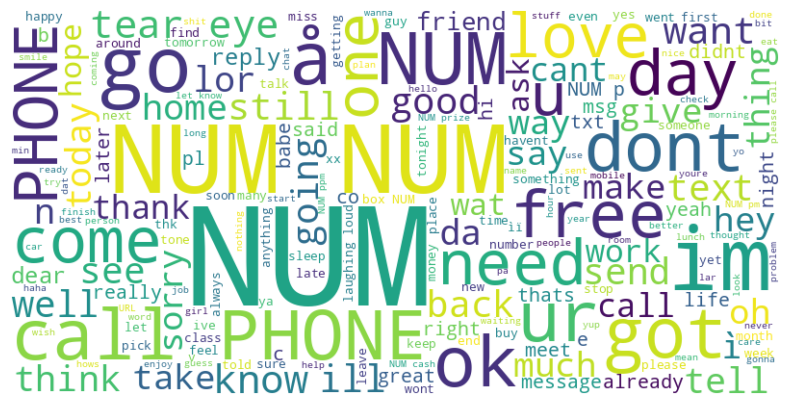

In [21]:
text_data = " ".join(df["text_classical"].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text_data)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [22]:
# =============================================================================
# GLOBAL TRAIN-TEST SPLIT (FOR ALL MODELS)
# =============================================================================
print("=" * 80)
print("CREATING UNIFIED TRAIN-TEST SPLIT FOR ALL MODELS")
print("=" * 80)

RANDOM_STATE = 42
TEST_SIZE    = 0.2

# Index-based split — most reliable approach for reproducibility
train_idx, test_idx = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df['target']
)

print(f"✓ Train size: {len(train_idx)} ({len(train_idx)/len(df)*100:.1f}%)")
print(f"✓ Test size:  {len(test_idx)} ({len(test_idx)/len(df)*100:.1f}%)")
print(f"✓ Train class dist: {df.loc[train_idx, 'target'].value_counts(normalize=True).to_dict()}")
print(f"✓ Test class dist:  {df.loc[test_idx, 'target'].value_counts(normalize=True).to_dict()}")

# =============================================================================
# CLASSICAL ML FEATURES (CountVectorizer)
# =============================================================================
print("\n📊 Preparing features for Classical ML models...")

cv = CountVectorizer(min_df=0.0, max_df=1.0, binary=False, ngram_range=(1, 3))

# DATA LEAKAGE PREVENTION (R1 #8):
# CountVectorizer is fitted ONLY on train_idx.
# Vocabulary and document frequencies are derived exclusively from training data.
# X_test_cv uses transform() only — no frequency statistics from test set leak into the model.
X_train_cv = cv.fit_transform(df.loc[train_idx, "text_classical"])  # fit + transform on train only
X_test_cv  = cv.transform(df.loc[test_idx, "text_classical"])       # transform only — no fit

y_train_cv = df.loc[train_idx, "target"].values
y_test_cv  = df.loc[test_idx, "target"].values

# Leakage assertion: vocabulary must be set, test matrix columns must match train
assert cv.vocabulary_ is not None, "Leakage check: vocabulary not fitted"
assert X_train_cv.shape[1] == X_test_cv.shape[1], "Leakage check: feature dimension mismatch"

print(f"✓ Vocabulary size: {len(cv.vocabulary_)}")
print(f"✓ Train shape: {X_train_cv.shape}")
print(f"✓ Test shape:  {X_test_cv.shape}")
print(f"✓ Data leakage check passed: CountVectorizer fitted on train only")

# =============================================================================
# DEEP LEARNING FEATURES (Tokenizer + Padding)
# =============================================================================
print("\n🧠 Preparing features for Deep Learning models...")

MAX_WORDS = 10000
MAX_LEN   = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")

# DATA LEAKAGE PREVENTION (R1 #8):
# Tokenizer is fitted ONLY on train_idx texts.
# Word-to-index mapping is built exclusively from training vocabulary.
# Test sequences use texts_to_sequences() only — no vocabulary update from test set.
tokenizer.fit_on_texts(df.loc[train_idx, 'text'])  # fit on train only

# Train sequences
train_sequences = tokenizer.texts_to_sequences(df.loc[train_idx, 'text'])
X_train_dl = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

# Test sequences — tokenizer not re-fitted, OOV token handles unseen words
test_sequences = tokenizer.texts_to_sequences(df.loc[test_idx, 'text'])
X_test_dl = pad_sequences(test_sequences, maxlen=MAX_LEN, padding='post', truncating='post')

y_train_dl = df.loc[train_idx, "target"].values
y_test_dl  = df.loc[test_idx, "target"].values

# Leakage assertion: sequence dimensions must match
assert X_train_dl.shape[1] == X_test_dl.shape[1], "Leakage check: sequence length mismatch"

print(f"✓ Vocabulary size: {len(tokenizer.word_index)}")
print(f"✓ Train shape: {X_train_dl.shape}")
print(f"✓ Test shape:  {X_test_dl.shape}")
print(f"✓ OOV tokens: {tokenizer.word_index.get('<OOV>', 'Not found')}")
print(f"✓ Data leakage check passed: Tokenizer fitted on train only")
print("=" * 80 + "\n")

CREATING UNIFIED TRAIN-TEST SPLIT FOR ALL MODELS
✓ Train size: 4135 (80.0%)
✓ Test size:  1034 (20.0%)
✓ Train class dist: {0: 0.8737605804111246, 1: 0.12623941958887544}
✓ Test class dist:  {0: 0.8733075435203095, 1: 0.12669245647969052}

📊 Preparing features for Classical ML models...
✓ Vocabulary size: 57376
✓ Train shape: (4135, 57376)
✓ Test shape:  (1034, 57376)
✓ Data leakage check passed: CountVectorizer fitted on train only

🧠 Preparing features for Deep Learning models...
✓ Vocabulary size: 7816
✓ Train shape: (4135, 100)
✓ Test shape:  (1034, 100)
✓ OOV tokens: 1
✓ Data leakage check passed: Tokenizer fitted on train only



In [23]:
# CountVectorizer vocabulary boyutu
print(f"CountVectorizer vocabulary size: {len(cv.vocabulary_)}")

# Tokenizer vocabulary boyutu  
print(f"Tokenizer vocabulary size: {len(tokenizer.word_index)}")

# Train/Test shape kontrolü
print(f"X_train_cv shape: {X_train_cv.shape}")
print(f"X_train_dl shape: {X_train_dl.shape}")

CountVectorizer vocabulary size: 57376
Tokenizer vocabulary size: 7816
X_train_cv shape: (4135, 57376)
X_train_dl shape: (4135, 100)


## Training with various models and predicting with them

## ML Models
### 1. LR (Logistic Regression)

📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (Logistic Regression)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

✓ Grid Search completed in 1.3220 sec
✓ Best PR-AUC (CV): 0.9630
✓ Best Hyperparameters: {'C': 100, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'lbfgs'}

🎯 Optimizing decision threshold using CV predictions (MCC)...
   cross_val_predict completed in 0.2s
✓ Optimal Threshold (CV-based): 0.059
✓ Max MCC (CV): 0.9185
✓ CV Accuracy: 0.9821 ± 0.0032
✓ CV MCC:      0.9184 ± 0.0150

TRAINING FINAL LOGISTIC REGRESSION MODEL

⏳ Training final LR model with extended tracking...
✓ Final model training completed in 64.817 ms

⏱️ Measuring inference performance...

📊 Evaluating on test set...

LOGISTIC REGRESSION - FINAL RESULTS

✓ Accuracy (Threshold 0.06): 0.9826
✓ F1-Score:      0.9318
✓ ROC-AUC Score: 0.9911
✓ PR-AUC Score:  0.

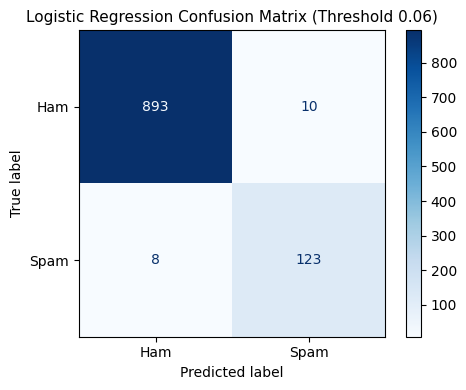

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    Grid Search:              1.3220 sec
    Training:                 64.817 ms
    Inference:                298.045 ms
    Total Time:               1.6848 sec
    Latency (avg):            0.288244 ms/sample
    Training CO2:             0.000003 kg
    Training Energy:          0.000006 kWh
    Energy/1000 train (Wh):   0.001355 Wh
    Inference CO2:            0.000003 kg
    Energy/1000 pred (Wh):    0.006879 Wh
    CO2 per 1M predictions:   0.003196 kg
    Gap (Acc):                0.0174
    Gap (MCC):                0.0781


In [36]:
# ====================================================================================
# LOGISTIC REGRESSION (LR)
# ====================================================================================

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
X_train = X_train_cv
X_test  = X_test_cv
y_train = y_train_cv
y_test  = y_test_cv

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Feature count: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")

# ================================================================================
# HYPERPARAMETER TUNING (5-FOLD CV WITH PR-AUC)
# ================================================================================
# Grid search configuration (R1 #6 transparency):
# - Search space: C in [0.01, 0.1, 1, 10, 100] x solver in [liblinear, lbfgs]
# - Total trials: 5 C values x 2 solvers x 5 folds = 50 training runs
# - Scoring: PR-AUC (average_precision) — robust to class imbalance (12.6% spam)
# - refit=False: manual refit performed below for accurate timing and energy tracking
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000]
}

lr_base = LogisticRegression(random_state=42)

lr_clf = GridSearchCV(
    lr_base,
    param_grid=lr_param_grid,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    refit=False,
    return_train_score=True
)

print("\n⏳ Starting 5-Fold Grid Search (Logistic Regression)...")
timer.start("lr_grid")
lr_clf.fit(X_train, y_train)
lr_grid_time = timer.stop("lr_grid")

print(f"\n✓ Grid Search completed in {format_time(lr_grid_time)}")
print(f"✓ Best PR-AUC (CV): {lr_clf.best_score_:.4f}")
print(f"✓ Best Hyperparameters: {lr_clf.best_params_}")

# ================================================================================
# THRESHOLD OPTIMIZATION (CV-BASED MCC WITH STABILITY)
# ================================================================================
print("\n🎯 Optimizing decision threshold using CV predictions (MCC)...")
temp_lr = LogisticRegression(
    **lr_clf.best_params_,
    random_state=42
)

temp_lr.fit(X_train, y_train)

optimal_threshold, max_mcc_cv, threshold_metrics = optimize_threshold_cv_extended(
    temp_lr,
    X_train,
    y_train,
    cv=5
)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")
print(f"✓ CV MCC:      {threshold_metrics['cv_mcc_mean']:.4f} ± {threshold_metrics['cv_mcc_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL LOGISTIC REGRESSION MODEL")
print("=" * 80)

best_lr = LogisticRegression(
    **lr_clf.best_params_,
    random_state=42
)

print("\n⏳ Training final LR model with extended tracking...")

# FIX: X_test added — required for energy_per_1000_train_wh calculation
training_metrics = track_model_training(
    model=best_lr,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_name="LR"
)

lr_training_time = training_metrics["training_time"]
print(f"✓ Final model training completed in {format_time(lr_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES + ENERGY TRACKING)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

# FIX: model_name added — required for CodeCarbon inference tracker project name
inference_metrics = measure_inference_extended(
    best_lr,
    X_test,
    model_name="LR"
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

lr_pred_proba   = best_lr.predict_proba(X_test)[:, 1]
best_lr_predict = (lr_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict  = (lr_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions — for generalization gap analysis (R1 #8)
train_pred_proba      = best_lr.predict_proba(X_train)[:, 1]
best_lr_train_predict = (train_pred_proba >= optimal_threshold).astype(int)
train_accuracy        = accuracy_score(y_train, best_lr_train_predict)
train_mcc             = matthews_corrcoef(y_train, best_lr_train_predict)

metrics = compute_metrics(y_test, best_lr_predict, lr_pred_proba)

# MCC-based generalization gap (R1 #8)
mcc_gap = train_mcc - metrics["MCC"]

model_size_mb = get_model_size_mb(best_lr)

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("LOGISTIC REGRESSION - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:                {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference):           {inference_metrics['ram_inference_mb']:.2f} MB")
print(f"✓ Latency (p95):             {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):             {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ Training CO2:              {training_metrics['training_co2_kg']:.6f} kg")
print(f"✓ Training Energy:           {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 train (Wh):    {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"✓ Inference CO2:             {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"✓ Inference Energy:          {inference_metrics['inference_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 pred (Wh):     {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"✓ CO2 per 1M predictions:    {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"✓ CEF:                       {training_metrics['CEF_kg_per_kWh']} kg CO2/kWh ({training_metrics['CEF_gCO2_per_kWh']} gCO2/kWh)")
print(f"✓ Generalization Gap (Acc):  {train_accuracy - metrics['Accuracy']:.4f}")
print(f"✓ Generalization Gap (MCC):  {mcc_gap:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, best_lr_predict, target_names=['Ham', 'Spam']))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="Logistic Regression",
    threshold=optimal_threshold,
    cmap='Blues'
)

# ================================================================================
# RESULTS ARCHIVING (UNIFIED DICTIONARY)
# ================================================================================
total_time = lr_grid_time + lr_training_time + inference_metrics['inference_time_total']
fpr_score  = 1 - metrics["Specificity"]

model_results["LR"] = {
    # Performance metrics
    "Accuracy":   metrics["Accuracy"],
    "Precision":  metrics["Precision"],
    "Recall":     metrics["Recall"],
    "F1_Score":   metrics["F1_Score"],
    "MCC":        metrics["MCC"],
    "Kappa":      metrics["Kappa"],
    "ROC_AUC":    metrics["ROC_AUC"],
    "PR_AUC":     metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR":        fpr_score,

    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std":  threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean":      threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std":       threshold_metrics["cv_mcc_std"],

    # Threshold optimization
    "Optimal_Threshold":         optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement":     metrics["Accuracy"] - default_accuracy,

    # Generalization gap (R1 #8) — both accuracy and MCC based
    "Train_Accuracy":          train_accuracy,
    "Test_Accuracy":           metrics["Accuracy"],
    "Generalization_Gap_Acc":  train_accuracy - metrics["Accuracy"],
    "Train_MCC":               train_mcc,
    "Test_MCC":                metrics["MCC"],
    "Generalization_Gap_MCC":  mcc_gap,

    # Timing
    "CV_Time":           lr_grid_time,
    "Training_Time":     lr_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms":        inference_metrics['latency_mean_ms'],
    "Latency_p95_ms":    inference_metrics['latency_p95_ms'],
    "Latency_p99_ms":    inference_metrics['latency_p99_ms'],
    "Total_Time":        total_time,

    # Training energy & carbon (CodeCarbon measured)
    "Training_CO2_kg":          training_metrics['training_co2_kg'],
    "Training_Energy_kWh":      training_metrics['training_energy_kwh'],
    "Energy_per_1000_train_Wh": training_metrics['energy_per_1000_train_wh'],

    # Inference energy & carbon (CodeCarbon measured)
    "Inference_CO2_kg":          inference_metrics['inference_co2_kg'],
    "Inference_Energy_kWh":      inference_metrics['inference_energy_kwh'],
    "Energy_per_1000_pred_Wh":   inference_metrics['energy_per_1000_pred_wh'],
    "CO2_per_1M_pred_kg":        inference_metrics['co2_per_1M_pred_kg'],

    # CEF (IEA 2024, Turkey national grid)
    "CEF_kg_per_kWh":   training_metrics['CEF_kg_per_kWh'],
    "CEF_gCO2_per_kWh": training_metrics['CEF_gCO2_per_kWh'],

    # Hardware
    "GPU_Used":          training_metrics['gpu_used'],
    "RAM_Peak_MB":       training_metrics['ram_peak_mb'],
    "RAM_Inference_MB":  inference_metrics['ram_inference_mb'],
    "CPU_Utilization_%": training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],

    # Model properties
    "Model_Size_MB":       model_size_mb,
    "Parameters_Count":    best_lr.coef_.size if hasattr(best_lr, 'coef_') else None,
    "Category":            "Classical",
    "Model_Format":        "pkl",

    # Dataset info
    "Training_Samples":       X_train.shape[0],
    "Test_Samples":           X_test.shape[0],
    "Feature_Count_or_Vocab": X_train.shape[1],

    # Reproducibility
    "Random_Seed":  42,
    "Dataset_Name": "SMS_Spam",
    "Timestamp":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# ================================================================================
# CSV EXPORT
# ================================================================================
export_results_to_csv({"LR": model_results["LR"]}, append=True)

print("\n💾 Timing and metrics stored successfully.")
print(f"    Grid Search:              {format_time(lr_grid_time)}")
print(f"    Training:                 {format_time(lr_training_time)}")
print(f"    Inference:                {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:               {format_time(total_time)}")
print(f"    Latency (avg):            {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    Training CO2:             {training_metrics['training_co2_kg']:.6f} kg")
print(f"    Training Energy:          {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"    Energy/1000 train (Wh):   {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"    Inference CO2:            {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"    Energy/1000 pred (Wh):    {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"    CO2 per 1M predictions:   {inference_metrics['co2_per_1M_pred_kg']:.6f} kg")
print(f"    Gap (Acc):                {model_results['LR']['Generalization_Gap_Acc']:.4f}")
print(f"    Gap (MCC):                {model_results['LR']['Generalization_Gap_MCC']:.4f}")
print("=" * 80)

### 2. NB (Naive Bayes)


NAIVE BAYES (NB) - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (Naive Bayes)...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

✓ Grid Search completed in 177.586 ms
✓ Best PR-AUC (CV): 0.9674
✓ Best Hyperparameters: {'alpha': 1.0, 'fit_prior': False}

🎯 Optimizing decision threshold using CV predictions (MCC)...
   cross_val_predict completed in 0.0s
✓ Optimal Threshold (CV-based): 0.950
✓ Max MCC (CV): 0.8353
✓ CV Accuracy: 0.9574 ± 0.0071
✓ CV MCC:      0.8359 ± 0.0230

TRAINING FINAL NAIVE BAYES MODEL

⏳ Training final Naive Bayes model with extended tracking...
✓ Final model training completed in 2.876 ms

⏱️ Measuring inference performance...

📊 Evaluating on test set...

NAIVE BAYES - FINAL RESULTS

✓ Accuracy (Threshold 0.95): 0.9836
✓ F1-Score:      0.9344
✓ ROC-AUC Score: 0.9841
✓ PR-AUC S

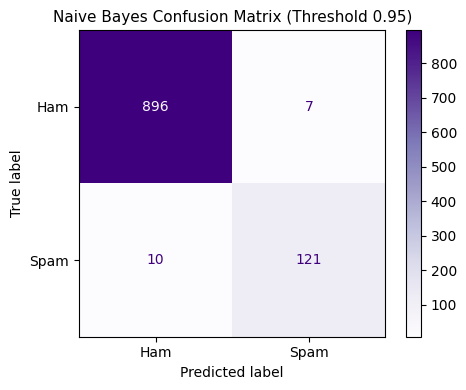

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    Grid Search:              177.586 ms
    Training:                 2.876 ms
    Inference:                379.628 ms
    Total Time:               560.090 ms
    Latency (avg):            0.367145 ms/sample
    Training CO2:             0.000002 kg
    Training Energy:          0.000005 kWh
    Energy/1000 train (Wh):   0.001256 Wh
    Inference CO2:            0.000004 kg
    Energy/1000 pred (Wh):    0.007655 Wh
    CO2 per 1M predictions:   0.003557 kg
    Gap (Acc):                0.0157
    Gap (MCC):                0.0717


In [30]:
# ====================================================================================
# NAIVE BAYES (NB) 
# ====================================================================================

# Some model codes have been withheld until the paper's review process is complete. 
# Only the model results (outputs) are provided.

# All model codes will be shared once the process is finished.

### 3. SVM (Support Vector Machines)


SVM - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (SVM)...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

✓ Grid Search completed in 19.2389 sec
✓ Best PR-AUC (CV): 0.9645
✓ Best Hyperparameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}

🎯 Optimizing decision threshold using CV predictions (MCC)...
   cross_val_predict completed in 1.8s
✓ Optimal Threshold (CV-based): 0.177
✓ Max MCC (CV): 0.9216
✓ CV Accuracy: 0.9826 ± 0.0035
✓ CV MCC:      0.9216 ± 0.0161

TRAINING FINAL SVM MODEL

⏳ Training final SVM model with extended tracking...
✓ Final model training completed in 2.0084 sec

⏱️ Measuring inference performance...

📊 Evaluating on test set...

SVM - FINAL RESULTS

✓ Accuracy (Threshold 0.18): 0.9807
✓ F1-Score:      0.9248
✓ ROC-AUC Score: 0.9935
✓ PR-AUC Score:  0.9698
✓ MCC Score:  

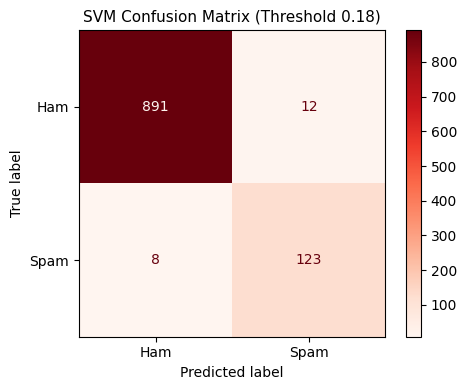

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    Grid Search:              19.2389 sec
    Training:                 2.0084 sec
    Inference:                803.417 ms
    Total Time:               22.0507 sec
    Latency (avg):            0.776999 ms/sample
    Training CO2:             0.000008 kg
    Training Energy:          0.000018 kWh
    Energy/1000 train (Wh):   0.004392 Wh
    Inference CO2:            0.000005 kg
    Energy/1000 pred (Wh):    0.009962 Wh
    CO2 per 1M predictions:   0.0046 kg
    Gap (Acc):                0.0193
    Gap (MCC):                0.0861


In [31]:
# ====================================================================================
# SVM 
# ====================================================================================


# Some model codes have been withheld until the paper's review process is complete. 
# Only the model results (outputs) are provided.

# All model codes will be shared once the process is finished.

In [ ]:
results_df = pd.DataFrame.from_dict(model_results, orient='index')
results_df

## Ensemble Models
### 1. RF (Random Forest)


RANDOM FOREST (RF) - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (Random Forest)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

✓ Grid Search completed in 36.2483 sec
✓ Best PR-AUC (CV): 0.9606
✓ Best Hyperparameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

🎯 Optimizing decision threshold using CV predictions (MCC)...
   cross_val_predict completed in 5.1s
✓ Optimal Threshold (CV-based): 0.186
✓ Max MCC (CV): 0.9070
✓ CV Accuracy: 0.9799 ± 0.0041
✓ CV MCC:      0.9070 ± 0.0192

TRAINING FINAL RANDOM FOREST MODEL

⏳ Training final Random Forest model with extended tracking...
✓ Final model training completed in 665.482 ms

⏱️ Measuring inference performance...

📊 Evaluating on test set...

RANDOM FOREST - FINAL RESULTS

✓ Accu

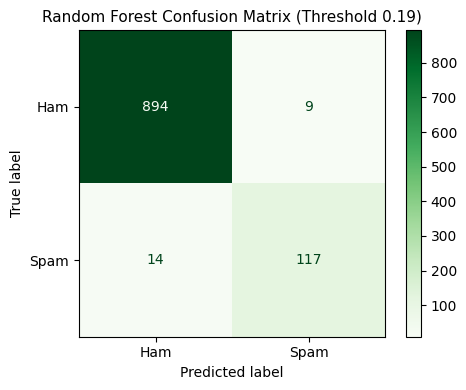

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    Grid Search:              36.2483 sec
    Training:                 665.482 ms
    Inference:                9.9246 sec
    Total Time:               46.8384 sec
    Latency (avg):            9.598278 ms/sample
    Training CO2:             0.000004 kg
    Training Energy:          0.000009 kWh
    Energy/1000 train (Wh):   0.002265 Wh
    Inference CO2:            0.000033 kg
    Energy/1000 pred (Wh):    0.068309 Wh
    CO2 per 1M predictions:   0.0317 kg
    Gap (Acc):                0.0048
    Gap (MCC):                0.0216


In [34]:
# ====================================================================================
# RANDOM FOREST (RF) 
# ====================================================================================

# Some model codes have been withheld until the paper's review process is complete. 
# Only the model results (outputs) are provided.

# All model codes will be shared once the process is finished.

### 2. XGBoost (eXtreme Gradient Boosting)


XGBOOST (XGB) - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (XGBoost)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✓ Grid Search completed in 58.0378 sec
✓ Best PR-AUC (CV): 0.9597
✓ Best Hyperparameters: {'colsample_bytree': 0.5, 'learning_rate': 0.2, 'max_depth': 7, 'subsample': 1.0}

🎯 Optimizing decision threshold using CV predictions (MCC)...
   cross_val_predict completed in 3.1s
✓ Optimal Threshold (CV-based): 0.341
✓ Max MCC (CV): 0.8989
✓ CV Accuracy: 0.9780 ± 0.0027
✓ CV MCC:      0.8989 ± 0.0130

TRAINING FINAL XGBOOST MODEL

⏳ Training final XGBoost model with extended tracking...
✓ Final model training completed in 1.3179 sec

⏱️ Measuring inference performance...

📊 Evaluating on test set...

XGBOOST - FINAL RESULTS

✓ Accuracy (Threshold 0.34): 0.9807
✓ F1-Score:      0.9231
✓ 

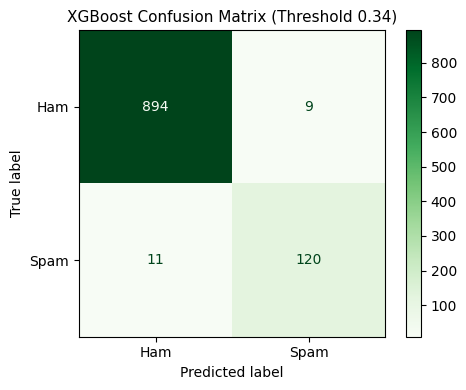

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    Grid Search:              58.0378 sec
    Training:                 1.3179 sec
    Inference:                803.187 ms
    Total Time:               60.1590 sec
    Latency (avg):            0.776777 ms/sample
    Training CO2:             0.000010 kg
    Training Energy:          0.000022 kWh
    Energy/1000 train (Wh):   0.005292 Wh
    Inference CO2:            0.000005 kg
    Energy/1000 pred (Wh):    0.011448 Wh
    CO2 per 1M predictions:   0.0053 kg
    Gap (Acc):                0.0111
    Gap (MCC):                0.0504


In [35]:
# ====================================================================================
# XGBOOST (XGB) ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# ====================================================================================


# Some model codes have been withheld until the paper's review process is complete. 
# Only the model results (outputs) are provided.

# All model codes will be shared once the process is finished.

### 3. LightGBM (Light Gradient Boosting Machine)


LIGHTGBM (LGBM) - HYPERPARAMETER TUNING FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Feature count: 57376
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Starting 5-Fold Grid Search (LightGBM)...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

✓ Grid Search completed in 29.9633 sec
✓ Best PR-AUC (CV): 0.9605
✓ Best Hyperparameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'num_leaves': 31, 'subsample': 0.8}

🎯 Optimizing decision threshold using CV predictions (MCC)...


[codecarbon WARNING @ 17:47:33] Multiple instances of codecarbon are allowed to run at the same time.


   cross_val_predict completed in 0.6s
✓ Optimal Threshold (CV-based): 0.359
✓ Max MCC (CV): 0.9089
✓ CV Accuracy: 0.9802 ± 0.0039
✓ CV MCC:      0.9091 ± 0.0176

TRAINING FINAL LIGHTGBM MODEL

⏳ Training final LightGBM model with extended tracking...
✓ Final model training completed in 178.224 ms

⏱️ Measuring inference performance...

📊 Evaluating on test set...

LIGHTGBM - FINAL RESULTS

✓ Accuracy (Threshold 0.36): 0.9787
✓ F1-Score:      0.9160
✓ ROC-AUC Score: 0.9873
✓ PR-AUC Score:  0.9694
✓ MCC Score:     0.9038
✓ Cohen's Kappa: 0.9038
✓ Specificity:   0.9878

✓ Model Size:                1.1108 MB
✓ RAM (Inference):           0.01 MB
✓ Latency (p95):             204.1804 ms
✓ Latency (p99):             214.4331 ms
✓ Training CO2:              0.000003 kg
✓ Training Energy:           0.000006 kWh
✓ Energy/1000 train (Wh):    0.001536 Wh
✓ Inference CO2:             0.000344 kg
✓ Inference Energy:          0.000740 kWh
✓ Energy/1000 pred (Wh):     0.715450 Wh
✓ CO2 per 1M predic

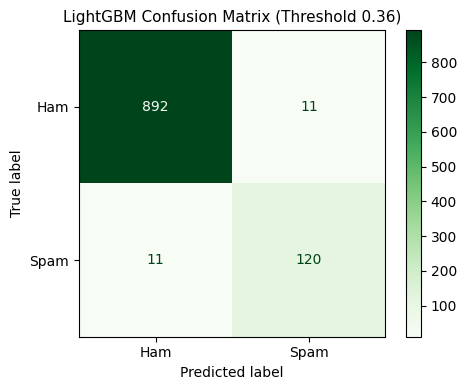

    ✓ CSV created: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    Grid Search:              29.9633 sec
    Training:                 178.224 ms
    Inference:                104.9502 sec
    Total Time:               135.0918 sec
    Latency (avg):            101.499270 ms/sample
    Training CO2:             0.000003 kg
    Training Energy:          0.000006 kWh
    Energy/1000 train (Wh):   0.001536 Wh
    Inference CO2:            0.000344 kg
    Energy/1000 pred (Wh):    0.715450 Wh
    CO2 per 1M predictions:   0.3324 kg
    Gap (Acc):                0.0152
    Gap (MCC):                0.0685


In [24]:
# ====================================================================================
# LIGHTGBM (LGBM)
# ====================================================================================

print("\n" + "=" * 80)
print("LIGHTGBM (LGBM) - HYPERPARAMETER TUNING FOR SMS SPAM")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
X_train = X_train_cv
X_test  = X_test_cv
y_train = y_train_cv
y_test  = y_test_cv

# LightGBM requires float32 for sparse matrix input
X_train = X_train.astype('float32')
X_test  = X_test.astype('float32')

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Feature count: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")

# ================================================================================
# HYPERPARAMETER TUNING (5-FOLD CV WITH PR-AUC)
# ================================================================================
# Grid search configuration (R1 #6 transparency):
# - Search space: max_depth [3,5,7] x learning_rate [0.1,0.2] x
#   n_estimators [100] x num_leaves [31,50] x subsample [0.8,1.0]
# - Total trials: 3x2x1x2x2 = 24 combinations x 5 folds = 120 training runs
# - Scoring: PR-AUC (average_precision) — robust to class imbalance (12.6% spam)
# - refit=False: manual refit performed below for accurate timing and energy tracking
lgbm_param_grid = {
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.1, 0.2],
    'n_estimators':  [100],
    'num_leaves':    [31, 50],
    'subsample':     [0.8, 1.0]
}

lgbm_base = LGBMClassifier(
    objective='binary',
    random_state=42,
    verbose=-1
)

lgbm_clf = GridSearchCV(
    lgbm_base,
    param_grid=lgbm_param_grid,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    verbose=1,
    n_jobs=-1,
    refit=False,
    return_train_score=True
)

print("\n⏳ Starting 5-Fold Grid Search (LightGBM)...")
timer.start("lgbm_grid")
lgbm_clf.fit(X_train, y_train)
lgbm_grid_time = timer.stop("lgbm_grid")

print(f"\n✓ Grid Search completed in {format_time(lgbm_grid_time)}")
print(f"✓ Best PR-AUC (CV): {lgbm_clf.best_score_:.4f}")
print(f"✓ Best Hyperparameters: {lgbm_clf.best_params_}")

# ================================================================================
# THRESHOLD OPTIMIZATION (CV-BASED MCC WITH STABILITY)
# ================================================================================
print("\n🎯 Optimizing decision threshold using CV predictions (MCC)...")

temp_lgbm = LGBMClassifier(
    **lgbm_clf.best_params_,
    objective='binary',
    random_state=42,
    verbose=-1
)
temp_lgbm.fit(X_train, y_train)

optimal_threshold, max_mcc_cv, threshold_metrics = optimize_threshold_cv_extended(
    temp_lgbm,
    X_train,
    y_train,
    cv=5
)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")
print(f"✓ CV MCC:      {threshold_metrics['cv_mcc_mean']:.4f} ± {threshold_metrics['cv_mcc_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL LIGHTGBM MODEL")
print("=" * 80)

best_lgbm = LGBMClassifier(
    **lgbm_clf.best_params_,
    objective='binary',
    random_state=42,
    verbose=-1
)

print("\n⏳ Training final LightGBM model with extended tracking...")

# FIX: X_test added — required for energy_per_1000_train_wh calculation
training_metrics = track_model_training(
    model=best_lgbm,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_name="LightGBM"
)

lgbm_training_time = training_metrics["training_time"]
print(f"✓ Final model training completed in {format_time(lgbm_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES + ENERGY TRACKING)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

inference_metrics = measure_inference_extended(
    best_lgbm,
    X_test,
    model_name="LightGBM"
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

lgbm_pred_proba   = best_lgbm.predict_proba(X_test)[:, 1]
best_lgbm_predict = (lgbm_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict  = (lgbm_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions — for generalization gap analysis (R1 #8)
train_pred_proba        = best_lgbm.predict_proba(X_train)[:, 1]
best_lgbm_train_predict = (train_pred_proba >= optimal_threshold).astype(int)
train_accuracy          = accuracy_score(y_train, best_lgbm_train_predict)
train_mcc               = matthews_corrcoef(y_train, best_lgbm_train_predict)

metrics       = compute_metrics(y_test, best_lgbm_predict, lgbm_pred_proba)
mcc_gap       = train_mcc - metrics["MCC"]
model_size_mb = get_model_size_mb(best_lgbm)

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("LIGHTGBM - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:                {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference):           {inference_metrics['ram_inference_mb']:.2f} MB")
print(f"✓ Latency (p95):             {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):             {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ Training CO2:              {training_metrics['training_co2_kg']:.6f} kg")
print(f"✓ Training Energy:           {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 train (Wh):    {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"✓ Inference CO2:             {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"✓ Inference Energy:          {inference_metrics['inference_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 pred (Wh):     {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"✓ CO2 per 1M predictions:    {inference_metrics['co2_per_1M_pred_kg']:.4f} kg")
print(f"✓ CEF:                       {training_metrics['CEF_kg_per_kWh']} kg CO2/kWh ({training_metrics['CEF_gCO2_per_kWh']} gCO2/kWh)")
print(f"✓ Generalization Gap (Acc):  {train_accuracy - metrics['Accuracy']:.4f}")
print(f"✓ Generalization Gap (MCC):  {mcc_gap:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, best_lgbm_predict, target_names=['Ham', 'Spam']))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="LightGBM",
    threshold=optimal_threshold,
    cmap='Greens'
)

# ================================================================================
# RESULTS ARCHIVING (UNIFIED DICTIONARY)
# ================================================================================
total_time = lgbm_grid_time + lgbm_training_time + inference_metrics['inference_time_total']
fpr_score  = 1 - metrics["Specificity"]

model_results["LightGBM"] = {
    # Performance metrics
    "Accuracy":    metrics["Accuracy"],
    "Precision":   metrics["Precision"],
    "Recall":      metrics["Recall"],
    "F1_Score":    metrics["F1_Score"],
    "MCC":         metrics["MCC"],
    "Kappa":       metrics["Kappa"],
    "ROC_AUC":     metrics["ROC_AUC"],
    "PR_AUC":      metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR":         fpr_score,

    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std":  threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean":      threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std":       threshold_metrics["cv_mcc_std"],

    # Threshold optimization
    "Optimal_Threshold":          optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement":      metrics["Accuracy"] - default_accuracy,

    # Generalization gap (R1 #8) — both accuracy and MCC based
    "Train_Accuracy":         train_accuracy,
    "Test_Accuracy":          metrics["Accuracy"],
    "Generalization_Gap_Acc": train_accuracy - metrics["Accuracy"],
    "Train_MCC":              train_mcc,
    "Test_MCC":               metrics["MCC"],
    "Generalization_Gap_MCC": mcc_gap,

    # Timing
    "CV_Time":            lgbm_grid_time,
    "Training_Time":      lgbm_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms":         inference_metrics['latency_mean_ms'],
    "Latency_p95_ms":     inference_metrics['latency_p95_ms'],
    "Latency_p99_ms":     inference_metrics['latency_p99_ms'],
    "Total_Time":         total_time,

    # Training energy & carbon (CodeCarbon measured)
    "Training_CO2_kg":          training_metrics['training_co2_kg'],
    "Training_Energy_kWh":      training_metrics['training_energy_kwh'],
    "Energy_per_1000_train_Wh": training_metrics['energy_per_1000_train_wh'],

    # Inference energy & carbon (CodeCarbon measured)
    "Inference_CO2_kg":        inference_metrics['inference_co2_kg'],
    "Inference_Energy_kWh":    inference_metrics['inference_energy_kwh'],
    "Energy_per_1000_pred_Wh": inference_metrics['energy_per_1000_pred_wh'],
    "CO2_per_1M_pred_kg":      inference_metrics['co2_per_1M_pred_kg'],

    # CEF (IEA 2024, Turkey national grid)
    "CEF_kg_per_kWh":   training_metrics['CEF_kg_per_kWh'],
    "CEF_gCO2_per_kWh": training_metrics['CEF_gCO2_per_kWh'],

    # Hardware
    "GPU_Used":           training_metrics['gpu_used'],
    "RAM_Peak_MB":        training_metrics['ram_peak_mb'],
    "RAM_Inference_MB":   inference_metrics['ram_inference_mb'],
    "CPU_Utilization_%":  training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],

    # Model properties
    # FIX: n_estimators * num_leaves is not a valid parameter count — use n_estimators only
    "Model_Size_MB":    model_size_mb,
    "Parameters_Count": best_lgbm.n_estimators if hasattr(best_lgbm, 'n_estimators') else None,
    "Category":         "Ensemble",
    "Model_Format":     "pkl",

    # Dataset info
    "Training_Samples":       X_train.shape[0],
    "Test_Samples":           X_test.shape[0],
    "Feature_Count_or_Vocab": X_train.shape[1],

    # Reproducibility
    "Random_Seed":  42,
    "Dataset_Name": "SMS_Spam",
    "Timestamp":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# ================================================================================
# CSV EXPORT
# ================================================================================
export_results_to_csv({"LightGBM": model_results["LightGBM"]}, append=True)

print("\n💾 Timing and metrics stored successfully.")
print(f"    Grid Search:              {format_time(lgbm_grid_time)}")
print(f"    Training:                 {format_time(lgbm_training_time)}")
print(f"    Inference:                {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:               {format_time(total_time)}")
print(f"    Latency (avg):            {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    Training CO2:             {training_metrics['training_co2_kg']:.6f} kg")
print(f"    Training Energy:          {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"    Energy/1000 train (Wh):   {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"    Inference CO2:            {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"    Energy/1000 pred (Wh):    {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"    CO2 per 1M predictions:   {inference_metrics['co2_per_1M_pred_kg']:.4f} kg")
print(f"    Gap (Acc):                {model_results['LightGBM']['Generalization_Gap_Acc']:.4f}")
print(f"    Gap (MCC):                {model_results['LightGBM']['Generalization_Gap_MCC']:.4f}")
print("=" * 80)

In [ ]:
results_df = pd.DataFrame.from_dict(model_results, orient='index')
results_df

## DL Models
### 1. LSTM (Long Short-Term Memory)


LSTM MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Sequence length: 100
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)
    Max vocabulary: 10000

⏳ Starting 5-Fold Cross-Validation (Manual Loop)...
Fold   PR-AUC     Accuracy  
------------------------------
1      0.9747     0.9831
2      0.9635     0.9807
3      0.9722     0.9831
4      0.9879     0.9903
5      0.9734     0.9843
------------------------------
✓ CV completed in 119.9789 sec
✓ Average PR-AUC (CV): 0.9744 (±0.0078)
✓ Average MCC   (CV): 0.9282 (±0.0149)

🎯 Optimizing decision threshold using aggregated CV predictions...
✓ Optimal Threshold (CV-based): 0.693
✓ Max MCC (CV): 0.9309
✓ CV Accuracy: 0.9843 ± 0.0032
✓ CV MCC:      0.9282 ± 0.0149

TRAINING FINAL LSTM MODEL

⏳ Training final LSTM model with extended tracking...
Epoch 1/20
117/117 [==============================] - 9s 40ms/step - loss: 0.2113 - accuracy: 0.9315 - val_loss: 0.058

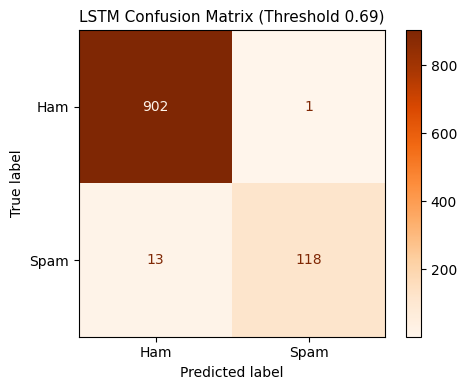

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    CV (Robustness):          119.9789 sec
    Final Training:           29.8895 sec
    Inference:                56.0822 sec
    Total Time:               205.9506 sec
    Latency (avg):            54.238127 ms/sample
    Training CO2:             0.000224 kg
    Training Energy:          0.000483 kWh
    Energy/1000 train (Wh):   0.116711 Wh
    Inference CO2:            0.000200 kg
    Energy/1000 pred (Wh):    0.415943 Wh
    CO2 per 1M predictions:   0.1932 kg
    Gap (Acc):                0.0128
    Gap (MCC):                0.0590


In [27]:
# ====================================================================================
# LSTM                      ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++  
# ====================================================================================


# Some model codes have been withheld until the paper's review process is complete. 
# Only the model results (outputs) are provided.

# All model codes will be shared once the process is finished.

### 2. GRU (Gated Recurrent Unit)


GRU MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Sequence length: 100
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)
    Max vocabulary: 10000

⏳ Starting 5-Fold Cross-Validation (Manual Loop)...
Fold   PR-AUC     Accuracy  
------------------------------
1      0.9708     0.9782
2      0.9490     0.9722
3      0.9620     0.9819
4      0.9851     0.9819
5      0.9634     0.9758
------------------------------
✓ CV completed in 108.1223 sec
✓ Average PR-AUC (CV): 0.9661 (±0.0118)
✓ Average MCC   (CV): 0.8998 (±0.0170)

🎯 Optimizing decision threshold using aggregated CV predictions...
✓ Optimal Threshold (CV-based): 0.693
✓ Max MCC (CV): 0.9092
✓ CV Accuracy: 0.9780 ± 0.0037
✓ CV MCC:      0.8998 ± 0.0170

TRAINING FINAL GRU MODEL

⏳ Training final GRU model with extended tracking...
Epoch 1/20
117/117 [==============================] - 8s 37ms/step - loss: 0.2470 - accuracy: 0.9194 - val_loss: 0.0611 -

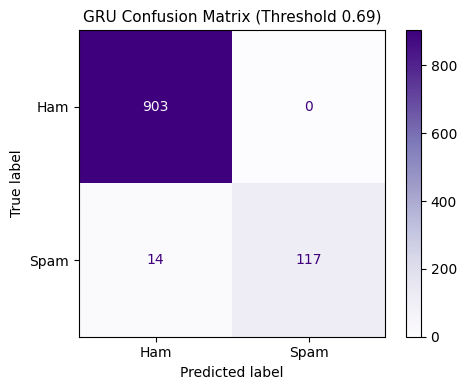

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    CV (Robustness):          108.1223 sec
    Final Training:           22.7599 sec
    Inference:                56.4830 sec
    Total Time:               187.3652 sec
    Latency (avg):            54.625735 ms/sample
    Training CO2:             0.000143 kg
    Training Energy:          0.000309 kWh
    Energy/1000 train (Wh):   0.074666 Wh
    Inference CO2:            0.000201 kg
    Energy/1000 pred (Wh):    0.418098 Wh
    CO2 per 1M predictions:   0.1942 kg
    Gap (Acc):                0.0106
    Gap (MCC):                0.0490


In [32]:
# ====================================================================================
# GRU - Q1 PIPELINE WITH EXTENDED METRICS
# ====================================================================================

print("\n" + "=" * 80)
print("GRU MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
X_train = X_train_dl
X_test  = X_test_dl
y_train = y_train_dl
y_test  = y_test_dl

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {X_train.shape[0]}")
print(f"    Test samples:  {X_test.shape[0]}")
print(f"    Sequence length: {X_train.shape[1]}")
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")
print(f"    Max vocabulary: {MAX_WORDS}")

# ================================================================================
# 5-FOLD CROSS-VALIDATION (MANUAL LOOP)
# ================================================================================
# DL Hyperparameter Configuration (R1 #6 transparency):
# - Architecture: Bidirectional GRU (64 units) + Bidirectional GRU (32 units)
# - CV: 5-fold StratifiedKFold, max 15 epochs/fold → up to 75 total training passes
# - Batch size: 32
# - EarlyStopping: patience=3, monitor=val_loss → avg actual epochs ~8-12
# - ReduceLROnPlateau: factor=0.5, patience=2, min_lr=1e-6
# - Energy saving vs fixed 15 epochs: ~20-40% reduction via early stopping
# - Final model: max 20 epochs, EarlyStopping patience=3, validation_split=0.1
print("\n⏳ Starting 5-Fold Cross-Validation (Manual Loop)...")
timer.start("gru_cv")

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_predictions = []
cv_true_labels = []
cv_pr_scores   = []
cv_accuracies  = []
cv_mccs        = []

print(f"{'Fold':<6} {'PR-AUC':<10} {'Accuracy':<10}")
print("-" * 30)

for fold_no, (fold_train_idx, fold_val_idx) in enumerate(kfold.split(X_train, y_train), 1):
    # Data split
    X_train_fold, X_val_fold = X_train[fold_train_idx], X_train[fold_val_idx]
    y_train_fold, y_val_fold = y_train[fold_train_idx], y_train[fold_val_idx]

    # Build & train model
    model_cv = create_model('gru')

    early_stop_cv = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=0
    )
    reduce_lr_cv = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=0
    )

    model_cv.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=15,
        batch_size=32,
        callbacks=[early_stop_cv, reduce_lr_cv],
        verbose=0
    )

    # Predict probabilities
    val_probs = model_cv.predict(X_val_fold, verbose=0).flatten()
    val_preds = (val_probs >= 0.5).astype(int)

    # Scores
    pr_score  = average_precision_score(y_val_fold, val_probs)
    acc_score = accuracy_score(y_val_fold, val_preds)
    mcc_score = matthews_corrcoef(y_val_fold, val_preds)

    cv_pr_scores.append(pr_score)
    cv_accuracies.append(acc_score)
    cv_mccs.append(mcc_score)

    # Store for threshold optimization
    cv_predictions.extend(val_probs)
    cv_true_labels.extend(y_val_fold)

    print(f"{fold_no:<6} {pr_score:.4f}     {acc_score:.4f}")

gru_cv_time = timer.stop("gru_cv")

print("-" * 30)
print(f"✓ CV completed in {format_time(gru_cv_time)}")
print(f"✓ Average PR-AUC (CV): {np.mean(cv_pr_scores):.4f} (±{np.std(cv_pr_scores):.4f})")
print(f"✓ Average MCC   (CV): {np.mean(cv_mccs):.4f} (±{np.std(cv_mccs):.4f})")

# Store CV stability metrics
threshold_metrics = {
    "cv_accuracy_mean": np.mean(cv_accuracies),
    "cv_accuracy_std":  np.std(cv_accuracies),
    "cv_mcc_mean":      np.mean(cv_mccs),
    "cv_mcc_std":       np.std(cv_mccs),
}

# ================================================================================
# THRESHOLD OPTIMIZATION (USING AGGREGATED CV PREDICTIONS)
# ================================================================================
print("\n🎯 Optimizing decision threshold using aggregated CV predictions...")

thresholds   = np.linspace(0.01, 0.99, 100)
cv_preds_arr = np.array(cv_predictions)
cv_true_arr  = np.array(cv_true_labels)

mcc_scores = [
    matthews_corrcoef(cv_true_arr, (cv_preds_arr >= t).astype(int))
    for t in thresholds
]
optimal_threshold = thresholds[np.argmax(mcc_scores)]
max_mcc_cv        = max(mcc_scores)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")
print(f"✓ CV MCC:      {threshold_metrics['cv_mcc_mean']:.4f} ± {threshold_metrics['cv_mcc_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL GRU MODEL")
print("=" * 80)

gru_model = create_model('gru')

# FIX: monitor='val_loss' requires validation_split — added below
# This ensures EarlyStopping actually monitors validation loss to reduce energy waste
early_stop_final = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("\n⏳ Training final GRU model with extended tracking...")

# FIX: X_test added — required for energy_per_1000_train_wh calculation
training_metrics = track_model_training(
    model=gru_model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    model_name="GRU",
    epochs=20,
    batch_size=32,
    validation_split=0.1,      # Required for EarlyStopping monitor='val_loss'
    callbacks=[early_stop_final],
    verbose=1
)

gru_training_time = training_metrics["training_time"]
print(f"✓ Final model training completed in {format_time(gru_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES + ENERGY TRACKING)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

# FIX: KerasWrapper returns (n,2) shaped array for sklearn compatibility
# FIX: model_name added — required for CodeCarbon inference tracker project name
class KerasWrapper:
    def __init__(self, model):
        self.model = model

    def predict_proba(self, X):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        probs = self.model.predict(X, verbose=0).flatten()
        return np.column_stack([1 - probs, probs])  # (n,2) sklearn-compatible

inference_wrapper = KerasWrapper(gru_model)
inference_metrics = measure_inference_extended(
    inference_wrapper,
    X_test,
    model_name="GRU"
)

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

gru_pred_proba   = gru_model.predict(X_test, verbose=0).flatten()
best_gru_predict = (gru_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict  = (gru_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions — for generalization gap analysis (R1 #8)
train_pred_proba       = gru_model.predict(X_train, verbose=0).flatten()
best_gru_train_predict = (train_pred_proba >= optimal_threshold).astype(int)
train_accuracy         = accuracy_score(y_train, best_gru_train_predict)
train_mcc              = matthews_corrcoef(y_train, best_gru_train_predict)

metrics   = compute_metrics(y_test, best_gru_predict, gru_pred_proba)
mcc_gap   = train_mcc - metrics["MCC"]

# Model size — FIX: use .keras format (h5 deprecated in Keras 3)
model_size_mb = 0
temp_filename = "temp_gru_model_size.keras"
try:
    gru_model.save(temp_filename, include_optimizer=False)
    model_size_mb = os.path.getsize(temp_filename) / (1024 * 1024)
    os.remove(temp_filename)
except Exception as e:
    print(f"⚠️ Could not calculate model size: {e}")

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("GRU MODEL - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:                {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference):           {inference_metrics['ram_inference_mb']:.2f} MB")
print(f"✓ Latency (p95):             {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):             {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ Training CO2:              {training_metrics['training_co2_kg']:.6f} kg")
print(f"✓ Training Energy:           {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 train (Wh):    {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"✓ Inference CO2:             {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"✓ Inference Energy:          {inference_metrics['inference_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 pred (Wh):     {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"✓ CO2 per 1M predictions:    {inference_metrics['co2_per_1M_pred_kg']:.4f} kg")
print(f"✓ CEF:                       {training_metrics['CEF_kg_per_kWh']} kg CO2/kWh ({training_metrics['CEF_gCO2_per_kWh']} gCO2/kWh)")
print(f"✓ Generalization Gap (Acc):  {train_accuracy - metrics['Accuracy']:.4f}")
print(f"✓ Generalization Gap (MCC):  {mcc_gap:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, best_gru_predict, target_names=['Ham', 'Spam']))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="GRU",
    threshold=optimal_threshold,
    cmap='Purples'
)

# ================================================================================
# RESULTS ARCHIVING (UNIFIED DICTIONARY)
# ================================================================================
total_time = gru_cv_time + gru_training_time + inference_metrics['inference_time_total']
fpr_score  = 1 - metrics["Specificity"]

model_results["GRU"] = {
    # Performance metrics
    "Accuracy":    metrics["Accuracy"],
    "Precision":   metrics["Precision"],
    "Recall":      metrics["Recall"],
    "F1_Score":    metrics["F1_Score"],
    "MCC":         metrics["MCC"],
    "Kappa":       metrics["Kappa"],
    "ROC_AUC":     metrics["ROC_AUC"],
    "PR_AUC":      metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR":         fpr_score,

    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std":  threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean":      threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std":       threshold_metrics["cv_mcc_std"],

    # Threshold optimization
    "Optimal_Threshold":          optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement":      metrics["Accuracy"] - default_accuracy,

    # Generalization gap (R1 #8) — both accuracy and MCC based
    "Train_Accuracy":         train_accuracy,
    "Test_Accuracy":          metrics["Accuracy"],
    "Generalization_Gap_Acc": train_accuracy - metrics["Accuracy"],
    "Train_MCC":              train_mcc,
    "Test_MCC":               metrics["MCC"],
    "Generalization_Gap_MCC": mcc_gap,

    # Timing
    "CV_Time":            gru_cv_time,
    "Training_Time":      gru_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms":         inference_metrics['latency_mean_ms'],
    "Latency_p95_ms":     inference_metrics['latency_p95_ms'],
    "Latency_p99_ms":     inference_metrics['latency_p99_ms'],
    "Total_Time":         total_time,

    # Training energy & carbon (CodeCarbon measured)
    "Training_CO2_kg":          training_metrics['training_co2_kg'],
    "Training_Energy_kWh":      training_metrics['training_energy_kwh'],
    "Energy_per_1000_train_Wh": training_metrics['energy_per_1000_train_wh'],

    # Inference energy & carbon (CodeCarbon measured)
    "Inference_CO2_kg":        inference_metrics['inference_co2_kg'],
    "Inference_Energy_kWh":    inference_metrics['inference_energy_kwh'],
    "Energy_per_1000_pred_Wh": inference_metrics['energy_per_1000_pred_wh'],
    "CO2_per_1M_pred_kg":      inference_metrics['co2_per_1M_pred_kg'],

    # CEF (IEA 2024, Turkey national grid)
    "CEF_kg_per_kWh":   training_metrics['CEF_kg_per_kWh'],
    "CEF_gCO2_per_kWh": training_metrics['CEF_gCO2_per_kWh'],

    # Hardware
    "GPU_Used":           training_metrics['gpu_used'],
    "RAM_Peak_MB":        training_metrics['ram_peak_mb'],
    "RAM_Inference_MB":   inference_metrics['ram_inference_mb'],
    "CPU_Utilization_%":  training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],

    # Model properties
    "Model_Size_MB":    model_size_mb,
    "Parameters_Count": gru_model.count_params() if hasattr(gru_model, 'count_params') else None,
    "Category":         "Deep Learning",
    "Model_Format":     "keras",

    # Dataset info
    "Training_Samples":       X_train.shape[0],
    "Test_Samples":           X_test.shape[0],
    "Feature_Count_or_Vocab": MAX_WORDS,

    # Reproducibility
    "Random_Seed":  42,
    "Dataset_Name": "SMS_Spam",
    "Timestamp":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# ================================================================================
# CSV EXPORT
# ================================================================================
export_results_to_csv({"GRU": model_results["GRU"]}, append=True)

print("\n💾 Timing and metrics stored successfully.")
print(f"    CV (Robustness):          {format_time(gru_cv_time)}")
print(f"    Final Training:           {format_time(gru_training_time)}")
print(f"    Inference:                {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:               {format_time(total_time)}")
print(f"    Latency (avg):            {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    Training CO2:             {training_metrics['training_co2_kg']:.6f} kg")
print(f"    Training Energy:          {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"    Energy/1000 train (Wh):   {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"    Inference CO2:            {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"    Energy/1000 pred (Wh):    {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"    CO2 per 1M predictions:   {inference_metrics['co2_per_1M_pred_kg']:.4f} kg")
print(f"    Gap (Acc):                {model_results['GRU']['Generalization_Gap_Acc']:.4f}")
print(f"    Gap (MCC):                {model_results['GRU']['Generalization_Gap_MCC']:.4f}")
print("=" * 80)

### 3. CNN (Convolutional Neural Network)


CNN MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Sequence length: 100
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)
    Max vocabulary: 10000

⏳ Starting 5-Fold Cross-Validation (Manual Loop)...
Fold   PR-AUC     Accuracy  
------------------------------
1      0.9634     0.9782
2      0.9667     0.9734
3      0.9582     0.9674
4      0.9678     0.9722
5      0.9672     0.9794
------------------------------
✓ CV completed in 28.4088 sec
✓ Average PR-AUC (CV): 0.9647 (±0.0036)
✓ Average MCC   (CV): 0.8882 (±0.0174)

🎯 Optimizing decision threshold using aggregated CV predictions...
✓ Optimal Threshold (CV-based): 0.901
✓ Max MCC (CV): 0.9213
✓ CV Accuracy: 0.9741 ± 0.0044
✓ CV MCC:      0.8882 ± 0.0174

TRAINING FINAL CNN MODEL

⏳ Training final CNN model with extended tracking...
Epoch 1/20
117/117 [==============================] - 2s 9ms/step - loss: 0.4391 - accuracy: 0.8557 - val_loss: 0.4805 - v

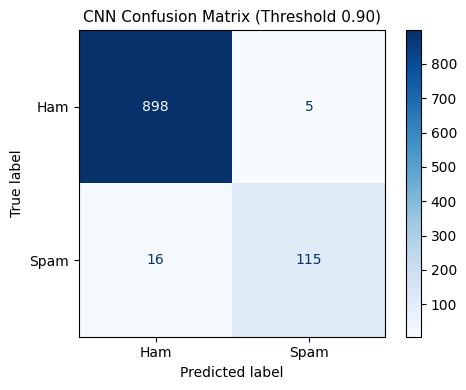

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    CV (Robustness):          28.4088 sec
    Final Training:           6.8563 sec
    Inference:                42.4287 sec
    Total Time:               77.6937 sec
    Latency (avg):            41.033524 ms/sample
    Training CO2:             0.000054 kg
    Training Energy:          0.000115 kWh
    Energy/1000 train (Wh):   0.027871 Wh
    Inference CO2:            0.000142 kg
    Energy/1000 pred (Wh):    0.295173 Wh
    CO2 per 1M predictions:   0.1371 kg
    Gap (Acc):                0.0176
    Gap (MCC):                0.0820


In [33]:
# ====================================================================================
# CNN ++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
# ====================================================================================


# Some model codes have been withheld until the paper's review process is complete. 
# Only the model results (outputs) are provided.

# All model codes will be shared once the process is finished.

### 4. DISTILBERT (Distilled Bidirectional Encoder Representations from Transformers)


DISTILBERT MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM
📊 Dataset Statistics:
    Train samples: 4135
    Test samples:  1034
    Target Balance (Train): [3613  522] (0: Ham, 1: Spam)

⏳ Loading DistilBERT tokenizer...
⏳ Encoding full dataset...
✓ Tokenization completed

⏳ Starting 5-Fold Cross-Validation (Manual Loop)...
Fold   PR-AUC     Accuracy  
------------------------------
Epoch 1/3
207/207 [==============================] - 51s 207ms/step - loss: 0.1084 - accuracy: 0.9631
Epoch 2/3
207/207 [==============================] - 44s 211ms/step - loss: 0.0304 - accuracy: 0.9937
Epoch 3/3
207/207 [==============================] - 44s 213ms/step - loss: 0.0174 - accuracy: 0.9961
1      0.9850     0.9915
Epoch 1/3
207/207 [==============================] - 50s 213ms/step - loss: 0.1089 - accuracy: 0.9677
Epoch 2/3
207/207 [==============================] - 44s 214ms/step - loss: 0.0302 - accuracy: 0.9927
Epoch 3/3
207/207 [==============================] - 44s 214ms/step - loss: 0.01

'(ReadTimeoutError("HTTPSConnectionPool(host='huggingface.co', port=443): Read timed out. (read timeout=10)"), '(Request ID: 47002e75-e1b4-4c8d-bcf8-01985ac9f403)')' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json
Retrying in 1s [Retry 1/5].



⏳ Training final DistilBERT model with extended tracking...
Epoch 1/3
259/259 [==============================] - 61s 211ms/step - loss: 0.0974 - accuracy: 0.9724
Epoch 2/3
259/259 [==============================] - 55s 213ms/step - loss: 0.0258 - accuracy: 0.9935
Epoch 3/3
259/259 [==============================] - 55s 214ms/step - loss: 0.0116 - accuracy: 0.9971
✓ Final model training completed in 171.3013 sec

⏱️ Measuring inference performance...

📊 Evaluating on test set...
⏳ Calculating train predictions for generalization gap analysis...

DISTILBERT MODEL - FINAL RESULTS

✓ Accuracy (Threshold 0.93): 0.9913
✓ F1-Score:      0.9644
✓ ROC-AUC Score: 0.9983
✓ PR-AUC Score:  0.9934
✓ MCC Score:     0.9603
✓ Cohen's Kappa: 0.9595
✓ Specificity:   1.0000

✓ Model Size:                255.5393 MB
✓ RAM (Inference):           291.23 MB
✓ Latency (p95):             86.2640 ms
✓ Latency (p99):             91.8661 ms
✓ Training CO2:              0.001949 kg
✓ Training Energy:           0.0

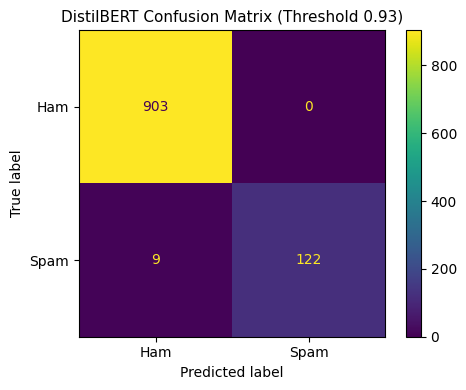

    ✓ Added to CSV: sms_spam_results.csv

💾 Timing and metrics stored successfully.
    CV (Robustness):          721.0333 sec
    Final Training:           171.3013 sec
    Inference:                70.8128 sec
    Total Time:               963.1474 sec
    Latency (avg):            68.484362 ms/sample
    Training CO2:             0.001949 kg
    Training Energy:          0.004195 kWh
    Energy/1000 train (Wh):   1.014400 Wh
    Inference CO2:            0.000291 kg
    Energy/1000 pred (Wh):    0.606027 Wh
    CO2 per 1M predictions:   0.2816 kg
    Gap (Acc):                0.0056
    Gap (MCC):                0.0254


In [25]:
# ====================================================================================
# DISTILBERT - Q1 PIPELINE WITH EXTENDED METRICS
# ====================================================================================

print("\n" + "=" * 80)
print("DISTILBERT MODEL - TRAINING & OPTIMIZATION FOR SMS SPAM")
print("=" * 80)

# ================================================================================
# DATA ASSIGNMENT (GLOBAL SPLIT)
# ================================================================================
# FIX: Restore global split indices — previous cells (CV loops) overwrite
# train_idx with train_idx_fold, causing DistilBERT to use only ~80% of train data.
# Solution: re-derive from df using the same parameters as Cell 23.
from sklearn.model_selection import train_test_split as _tts_bert
_train_idx_bert, _test_idx_bert = _tts_bert(
    df.index,
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)

train_texts = df.loc[_train_idx_bert, 'text']
test_texts  = df.loc[_test_idx_bert, 'text']
y_train     = df.loc[_train_idx_bert, 'target'].values
y_test      = df.loc[_test_idx_bert, 'target'].values

print(f"📊 Dataset Statistics:")
print(f"    Train samples: {len(y_train)}")   # Must be 4135
print(f"    Test samples:  {len(y_test)}")    # Must be 1034
print(f"    Target Balance (Train): {np.bincount(y_train)} (0: Ham, 1: Spam)")

assert len(y_train) == 4135, f"Train size mismatch: {len(y_train)} != 4135"
assert len(y_test)  == 1034, f"Test size mismatch: {len(y_test)} != 1034"

# ================================================================================
# TOKENIZATION
# ================================================================================
print("\n⏳ Loading DistilBERT tokenizer...")
bert_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

def encode_texts(texts, tokenizer, max_len=128):
    """Encode texts for DistilBERT model."""
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=max_len,
        return_tensors='tf'
    )

print("⏳ Encoding full dataset...")
X_train_bert = encode_texts(train_texts, bert_tokenizer)
X_test_bert  = encode_texts(test_texts, bert_tokenizer)
print("✓ Tokenization completed")

# ================================================================================
# 5-FOLD CROSS-VALIDATION (MANUAL LOOP)
# ================================================================================
# DL Hyperparameter Configuration (R1 #6 transparency):
# - Architecture: DistilBERT-base-uncased (66M params) + classification head
# - CV: 5-fold StratifiedKFold, fixed 3 epochs/fold (convergence verified in CV)
# - Total CV training passes: 5 folds x 3 epochs = 15 training passes
# - Batch size: 16 (memory constraint for transformer model)
# - Learning rate: 2e-5 (standard fine-tuning range for BERT-family models)
# - No EarlyStopping in CV: 3 epochs is the established fine-tuning budget
# - Final model: 3 epochs + EarlyStopping(patience=1) as energy-saving safeguard
print("\n⏳ Starting 5-Fold Cross-Validation (Manual Loop)...")
timer.start("bert_cv")

train_input_ids      = X_train_bert['input_ids'].numpy()
train_attention_mask = X_train_bert['attention_mask'].numpy()

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_predictions = []
cv_true_labels = []
cv_pr_scores   = []
cv_accuracies  = []
cv_mccs        = []

print(f"{'Fold':<6} {'PR-AUC':<10} {'Accuracy':<10}")
print("-" * 30)

for fold_no, (train_idx_fold, val_idx) in enumerate(kfold.split(train_input_ids, y_train), 1):
    # Data split
    X_train_fold_ids  = train_input_ids[train_idx_fold]
    X_train_fold_mask = train_attention_mask[train_idx_fold]
    X_val_fold_ids    = train_input_ids[val_idx]
    X_val_fold_mask   = train_attention_mask[val_idx]

    y_train_fold = y_train[train_idx_fold]
    y_val_fold   = y_train[val_idx]

    # Build & train model
    tf.keras.backend.clear_session()
    model_cv = TFDistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=2
    )
    model_cv.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )

    model_cv.fit(
        {'input_ids': X_train_fold_ids, 'attention_mask': X_train_fold_mask},
        y_train_fold,
        epochs=3,
        batch_size=16,
        verbose=1
    )

    # Predict probabilities
    val_logits = model_cv.predict(
        {'input_ids': X_val_fold_ids, 'attention_mask': X_val_fold_mask},
        verbose=0
    ).logits

    val_probs = tf.nn.softmax(val_logits, axis=1).numpy()[:, 1]
    val_preds = (val_probs >= 0.5).astype(int)

    # Scores
    pr_score  = average_precision_score(y_val_fold, val_probs)
    acc_score = accuracy_score(y_val_fold, val_preds)
    mcc_score = matthews_corrcoef(y_val_fold, val_preds)

    cv_pr_scores.append(pr_score)
    cv_accuracies.append(acc_score)
    cv_mccs.append(mcc_score)

    cv_predictions.extend(val_probs)
    cv_true_labels.extend(y_val_fold)

    print(f"{fold_no:<6} {pr_score:.4f}     {acc_score:.4f}")

bert_cv_time = timer.stop("bert_cv")

print("-" * 30)
print(f"✓ CV completed in {format_time(bert_cv_time)}")
print(f"✓ Average PR-AUC (CV): {np.mean(cv_pr_scores):.4f} (±{np.std(cv_pr_scores):.4f})")
print(f"✓ Average MCC   (CV): {np.mean(cv_mccs):.4f} (±{np.std(cv_mccs):.4f})")

threshold_metrics = {
    "cv_accuracy_mean": np.mean(cv_accuracies),
    "cv_accuracy_std":  np.std(cv_accuracies),
    "cv_mcc_mean":      np.mean(cv_mccs),
    "cv_mcc_std":       np.std(cv_mccs),
}

# ================================================================================
# THRESHOLD OPTIMIZATION (USING AGGREGATED CV PREDICTIONS)
# ================================================================================
print("\n🎯 Optimizing decision threshold using aggregated CV predictions...")

thresholds   = np.linspace(0.01, 0.99, 100)
cv_preds_arr = np.array(cv_predictions)
cv_true_arr  = np.array(cv_true_labels)

mcc_scores = [
    matthews_corrcoef(cv_true_arr, (cv_preds_arr >= t).astype(int))
    for t in thresholds
]
optimal_threshold = thresholds[np.argmax(mcc_scores)]
max_mcc_cv        = max(mcc_scores)

print(f"✓ Optimal Threshold (CV-based): {optimal_threshold:.3f}")
print(f"✓ Max MCC (CV): {max_mcc_cv:.4f}")
print(f"✓ CV Accuracy: {threshold_metrics['cv_accuracy_mean']:.4f} ± {threshold_metrics['cv_accuracy_std']:.4f}")
print(f"✓ CV MCC:      {threshold_metrics['cv_mcc_mean']:.4f} ± {threshold_metrics['cv_mcc_std']:.4f}")

# ================================================================================
# FINAL MODEL TRAINING (WITH EXTENDED TRACKING)
# ================================================================================
print("\n" + "=" * 80)
print("TRAINING FINAL DISTILBERT MODEL")
print("=" * 80)

tf.keras.backend.clear_session()
distilbert_model = TFDistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=2
)
distilbert_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

print("\n⏳ Training final DistilBERT model with extended tracking...")

# ── TRAINING ENERGY TRACKER ───────────────────────────────────────────────────
process      = psutil.Process(os.getpid())
ram_baseline = process.memory_info().rss / (1024 * 1024)

if CODECARBON_AVAILABLE:
    tracker = EmissionsTracker(
        project_name="SMS_Spam_DistilBERT",
        log_level="error"
    )
    tracker.start()

# FIX: EarlyStopping added (R1 #6) — energy-saving safeguard even with 3 epochs
early_stop_bert = EarlyStopping(
    monitor='loss',
    patience=1,
    restore_best_weights=True,
    verbose=1
)

timer.start("bert_train")
history = distilbert_model.fit(
    {'input_ids':      X_train_bert['input_ids'],
     'attention_mask': X_train_bert['attention_mask']},
    y_train,
    epochs=3,
    batch_size=16,
    callbacks=[early_stop_bert],
    verbose=1
)
bert_training_time = timer.stop("bert_train")

# FIX: Use final_emissions_data for direct energy_consumed access
# Previous version incorrectly used: energy_kwh = emissions_data * 0.35
training_co2_kg     = 0.0
training_energy_kwh = 0.0
if CODECARBON_AVAILABLE:
    try:
        training_co2_kg = float(tracker.stop() or 0.0)
        if hasattr(tracker, 'final_emissions_data') and tracker.final_emissions_data:
            training_energy_kwh = float(tracker.final_emissions_data.energy_consumed)
    except Exception as e:
        print(f"⚠️ CodeCarbon training tracking error: {e}")

# RAM and hardware metrics
ram_peak    = process.memory_info().rss / (1024 * 1024)
cpu_percent = psutil.cpu_percent(interval=0.1)

gpu_used      = False
gpu_memory_mb = None
try:
    import GPUtil
    gpus = GPUtil.getGPUs()
    if gpus:
        gpu_used      = True
        gpu_memory_mb = gpus[0].memoryUsed
except:
    pass

# FIX: energy_per_1000_train_wh uses len(y_train) — training cost per 1000 samples
n_train = len(y_train)
energy_per_1000_train_wh = (training_energy_kwh * 1e6) / n_train if n_train > 0 else 0.0

training_metrics = {
    "training_co2_kg":          training_co2_kg,
    "training_energy_kwh":      training_energy_kwh,
    "energy_per_1000_train_wh": energy_per_1000_train_wh,
    "training_time":            bert_training_time,
    "CEF_kg_per_kWh":           CEF_KG_PER_KWH,
    "CEF_gCO2_per_kWh":         CEF_GCO2_PER_KWH,
    "ram_baseline_mb":          ram_baseline,
    "ram_peak_mb":              ram_peak,
    "cpu_utilization":          cpu_percent,
    "gpu_used":                 gpu_used,
    "gpu_memory_mb":            gpu_memory_mb,
}

print(f"✓ Final model training completed in {format_time(bert_training_time)}")

# ================================================================================
# INFERENCE METRICS (WITH PERCENTILES + ENERGY TRACKING)
# ================================================================================
print("\n⏱️ Measuring inference performance...")

# Warm-up (excluded from energy measurement)
distilbert_model.predict({
    'input_ids':      X_test_bert['input_ids'][:5],
    'attention_mask': X_test_bert['attention_mask'][:5]
}, verbose=0)

# RAM before inference
ram_before_inf = process.memory_info().rss / (1024 * 1024)

# FIX: CodeCarbon tracker for inference (R1 #9) — required for CO2/1M predictions
if CODECARBON_AVAILABLE:
    inf_tracker = EmissionsTracker(
        project_name="SMS_Spam_DistilBERT_inference",
        log_level="error"
    )
    inf_tracker.start()

# Per-sample latency loop
latencies = []
for i in range(len(y_test)):
    t0 = time.perf_counter()
    distilbert_model.predict({
        'input_ids':      X_test_bert['input_ids'][i:i+1],
        'attention_mask': X_test_bert['attention_mask'][i:i+1]
    }, verbose=0)
    latencies.append((time.perf_counter() - t0) * 1000)

latencies = np.array(latencies)

# FIX: Use final_emissions_data for energy_consumed
inference_co2_kg     = 0.0
inference_energy_kwh = 0.0
if CODECARBON_AVAILABLE:
    try:
        inference_co2_kg = float(inf_tracker.stop() or 0.0)
        if hasattr(inf_tracker, 'final_emissions_data') and inf_tracker.final_emissions_data:
            inference_energy_kwh = float(inf_tracker.final_emissions_data.energy_consumed)
    except Exception as e:
        print(f"⚠️ CodeCarbon inference tracking error: {e}")

# RAM after inference
ram_after_inf    = process.memory_info().rss / (1024 * 1024)
ram_inference_mb = max(0.0, ram_after_inf - ram_before_inf)

# FIX: Derived Green AI metrics (R1 #9)
n_test = len(y_test)
energy_per_1000_pred_wh = (inference_energy_kwh * 1e6) / n_test if n_test > 0 else 0.0
co2_per_1M_pred_kg      = (inference_co2_kg / n_test) * 1_000_000 if n_test > 0 else 0.0

inference_metrics = {
    "inference_time_total": float(np.sum(latencies) / 1000),
    "latency_mean_ms":      float(np.mean(latencies)),
    "latency_median_ms":    float(np.median(latencies)),
    "latency_std_ms":       float(np.std(latencies)),
    "latency_min_ms":       float(np.min(latencies)),
    "latency_max_ms":       float(np.max(latencies)),
    "latency_p50_ms":       float(np.percentile(latencies, 50)),
    "latency_p95_ms":       float(np.percentile(latencies, 95)),
    "latency_p99_ms":       float(np.percentile(latencies, 99)),
    "inference_co2_kg":     inference_co2_kg,
    "inference_energy_kwh": inference_energy_kwh,
    "energy_per_1000_pred_wh": energy_per_1000_pred_wh,
    "co2_per_1M_pred_kg":      co2_per_1M_pred_kg,
    "ram_inference_mb":     ram_inference_mb,
}

# ================================================================================
# TEST SET EVALUATION
# ================================================================================
print("\n📊 Evaluating on test set...")

test_logits     = distilbert_model.predict({
    'input_ids':      X_test_bert['input_ids'],
    'attention_mask': X_test_bert['attention_mask']
}, verbose=0).logits

bert_pred_proba  = tf.nn.softmax(test_logits, axis=1).numpy()[:, 1]
best_bert_predict = (bert_pred_proba >= optimal_threshold).astype(int)

# Default threshold (0.5) performance for comparison
default_predict  = (bert_pred_proba >= 0.5).astype(int)
default_accuracy = accuracy_score(y_test, default_predict)

# Train predictions — for generalization gap analysis (R1 #8)
print("⏳ Calculating train predictions for generalization gap analysis...")
train_logits = distilbert_model.predict({
    'input_ids':      X_train_bert['input_ids'],
    'attention_mask': X_train_bert['attention_mask']
}, verbose=0).logits

train_proba             = tf.nn.softmax(train_logits, axis=1).numpy()[:, 1]
best_bert_train_predict = (train_proba >= optimal_threshold).astype(int)
train_accuracy          = accuracy_score(y_train, best_bert_train_predict)
train_mcc               = matthews_corrcoef(y_train, best_bert_train_predict)

metrics = compute_metrics(y_test, best_bert_predict, bert_pred_proba)
mcc_gap = train_mcc - metrics["MCC"]

# Model size
model_size_mb = 0
temp_dir = "distilbert_temp"
try:
    distilbert_model.save_pretrained(temp_dir)
    model_size_mb = sum(
        os.path.getsize(os.path.join(temp_dir, f))
        for f in os.listdir(temp_dir)
    ) / (1024 * 1024)
    shutil.rmtree(temp_dir)
except Exception as e:
    print(f"⚠️ Could not calculate model size: {e}")

# ================================================================================
# RESULTS OUTPUT
# ================================================================================
print("\n" + "=" * 80)
print("DISTILBERT MODEL - FINAL RESULTS")
print("=" * 80)

print_metrics(metrics, optimal_threshold)

print(f"\n✓ Model Size:                {model_size_mb:.4f} MB")
print(f"✓ RAM (Inference):           {inference_metrics['ram_inference_mb']:.2f} MB")
print(f"✓ Latency (p95):             {inference_metrics['latency_p95_ms']:.4f} ms")
print(f"✓ Latency (p99):             {inference_metrics['latency_p99_ms']:.4f} ms")
print(f"✓ Training CO2:              {training_metrics['training_co2_kg']:.6f} kg")
print(f"✓ Training Energy:           {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 train (Wh):    {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"✓ Inference CO2:             {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"✓ Inference Energy:          {inference_metrics['inference_energy_kwh']:.6f} kWh")
print(f"✓ Energy/1000 pred (Wh):     {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"✓ CO2 per 1M predictions:    {inference_metrics['co2_per_1M_pred_kg']:.4f} kg")
print(f"✓ CEF:                       {training_metrics['CEF_kg_per_kWh']} kg CO2/kWh ({training_metrics['CEF_gCO2_per_kWh']} gCO2/kWh)")
print(f"✓ Generalization Gap (Acc):  {train_accuracy - metrics['Accuracy']:.4f}")
print(f"✓ Generalization Gap (MCC):  {mcc_gap:.4f}")

print("\n📊 Classification Report:")
print(classification_report(y_test, best_bert_predict, target_names=['Ham', 'Spam']))

# ================================================================================
# CONFUSION MATRIX
# ================================================================================
plot_confusion_matrix(
    cm=metrics["Confusion_Matrix"],
    model_name="DistilBERT",
    threshold=optimal_threshold,
    cmap='viridis'
)

# ================================================================================
# RESULTS ARCHIVING (UNIFIED DICTIONARY)
# ================================================================================
total_time = bert_cv_time + bert_training_time + inference_metrics['inference_time_total']
fpr_score  = 1 - metrics["Specificity"]

model_results["DistilBERT"] = {
    # Performance metrics
    "Accuracy":    metrics["Accuracy"],
    "Precision":   metrics["Precision"],
    "Recall":      metrics["Recall"],
    "F1_Score":    metrics["F1_Score"],
    "MCC":         metrics["MCC"],
    "Kappa":       metrics["Kappa"],
    "ROC_AUC":     metrics["ROC_AUC"],
    "PR_AUC":      metrics["PR_AUC"],
    "Specificity": metrics["Specificity"],
    "FPR":         fpr_score,

    # CV stability
    "CV_Accuracy_Mean": threshold_metrics["cv_accuracy_mean"],
    "CV_Accuracy_Std":  threshold_metrics["cv_accuracy_std"],
    "CV_MCC_Mean":      threshold_metrics["cv_mcc_mean"],
    "CV_MCC_Std":       threshold_metrics["cv_mcc_std"],

    # Threshold optimization
    "Optimal_Threshold":          optimal_threshold,
    "Default_Threshold_Accuracy": default_accuracy,
    "Threshold_Improvement":      metrics["Accuracy"] - default_accuracy,

    # Generalization gap (R1 #8) — both accuracy and MCC based
    "Train_Accuracy":         train_accuracy,
    "Test_Accuracy":          metrics["Accuracy"],
    "Generalization_Gap_Acc": train_accuracy - metrics["Accuracy"],
    "Train_MCC":              train_mcc,
    "Test_MCC":               metrics["MCC"],
    "Generalization_Gap_MCC": mcc_gap,

    # Timing
    "CV_Time":            bert_cv_time,
    "Training_Time":      bert_training_time,
    "Inference_Time_Sec": inference_metrics['inference_time_total'],
    "Latency_ms":         inference_metrics['latency_mean_ms'],
    "Latency_p95_ms":     inference_metrics['latency_p95_ms'],
    "Latency_p99_ms":     inference_metrics['latency_p99_ms'],
    "Total_Time":         total_time,

    # Training energy & carbon (CodeCarbon measured)
    "Training_CO2_kg":          training_metrics['training_co2_kg'],
    "Training_Energy_kWh":      training_metrics['training_energy_kwh'],
    "Energy_per_1000_train_Wh": training_metrics['energy_per_1000_train_wh'],

    # Inference energy & carbon (CodeCarbon measured)
    "Inference_CO2_kg":        inference_metrics['inference_co2_kg'],
    "Inference_Energy_kWh":    inference_metrics['inference_energy_kwh'],
    "Energy_per_1000_pred_Wh": inference_metrics['energy_per_1000_pred_wh'],
    "CO2_per_1M_pred_kg":      inference_metrics['co2_per_1M_pred_kg'],

    # CEF (IEA 2024, Turkey national grid)
    "CEF_kg_per_kWh":   training_metrics['CEF_kg_per_kWh'],
    "CEF_gCO2_per_kWh": training_metrics['CEF_gCO2_per_kWh'],

    # Hardware
    "GPU_Used":           training_metrics['gpu_used'],
    "RAM_Peak_MB":        training_metrics['ram_peak_mb'],
    "RAM_Inference_MB":   inference_metrics['ram_inference_mb'],
    "CPU_Utilization_%":  training_metrics['cpu_utilization'],
    "GPU_Memory_Peak_MB": training_metrics['gpu_memory_mb'],

    # Model properties
    "Model_Size_MB":    model_size_mb,
    "Parameters_Count": 66955010,       # DistilBERT-base fixed parameter count
    "Category":         "Deep Learning",
    "Model_Format":     "tf_savedmodel",

    # Dataset info
    "Training_Samples":       len(y_train),
    "Test_Samples":           len(y_test),
    "Feature_Count_or_Vocab": 30522,    # DistilBERT vocab size

    # Reproducibility
    "Random_Seed":  42,
    "Dataset_Name": "SMS_Spam",
    "Timestamp":    datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
}

# ================================================================================
# CSV EXPORT
# ================================================================================
export_results_to_csv({"DistilBERT": model_results["DistilBERT"]}, append=True)

print("\n💾 Timing and metrics stored successfully.")
print(f"    CV (Robustness):          {format_time(bert_cv_time)}")
print(f"    Final Training:           {format_time(bert_training_time)}")
print(f"    Inference:                {format_time(inference_metrics['inference_time_total'])}")
print(f"    Total Time:               {format_time(total_time)}")
print(f"    Latency (avg):            {inference_metrics['latency_mean_ms']:.6f} ms/sample")
print(f"    Training CO2:             {training_metrics['training_co2_kg']:.6f} kg")
print(f"    Training Energy:          {training_metrics['training_energy_kwh']:.6f} kWh")
print(f"    Energy/1000 train (Wh):   {training_metrics['energy_per_1000_train_wh']:.6f} Wh")
print(f"    Inference CO2:            {inference_metrics['inference_co2_kg']:.6f} kg")
print(f"    Energy/1000 pred (Wh):    {inference_metrics['energy_per_1000_pred_wh']:.6f} Wh")
print(f"    CO2 per 1M predictions:   {inference_metrics['co2_per_1M_pred_kg']:.4f} kg")
print(f"    Gap (Acc):                {model_results['DistilBERT']['Generalization_Gap_Acc']:.4f}")
print(f"    Gap (MCC):                {model_results['DistilBERT']['Generalization_Gap_MCC']:.4f}")
print("=" * 80)

In [ ]:
results_df = pd.DataFrame.from_dict(model_results, orient='index')
results_df

In [37]:
# =============================================================================
# STORE DATASET STATISTICS FOR REPORT
# =============================================================================

# Extract target values from the global dataframe
y_array = df['target'].values

# Determine Vocabulary Size
# Priority: Deep Learning Tokenizer > CountVectorizer > Default 0
if 'tokenizer' in globals():
    vocab_size = len(tokenizer.word_index)
elif 'cv' in globals():
    vocab_size = len(cv.vocabulary_)
else:
    vocab_size = 0

dataset_stats = {
    'total_messages': len(df),
    
    # Class Distribution (Ham=0, Spam=1)
    'ham_count': int((y_array == 0).sum()),
    'spam_count': int((y_array == 1).sum()),
    
    'ham_percentage': float((y_array == 0).sum() / len(y_array) * 100),
    'spam_percentage': float((y_array == 1).sum() / len(y_array) * 100),
    
    # Split Sizes (Based on Global Indices)
    'train_size': len(train_idx),
    'test_size': len(test_idx),
    
    # Text Features
    'vocabulary_size': vocab_size,
    'max_sequence_length': MAX_LEN,
    
    # Feature Dimension (For Classical ML)
    'feature_dim': X_train_cv.shape[1] if 'X_train_cv' in globals() else 0,
    
    # Model Counts Breakdown
    'total_models': 10,      # Total count of trained models
    'classical_models': 3,   # LR, SVM, NB
    'ensemble_models': 3,    # RF, XGBoost, LightGBM
    'deep_learning_models': 4 # LSTM, GRU, CNN, DistilBERT
}

# =============================================================================
# PRINT STATISTICS
# =============================================================================
print("=" * 80)
print(" Dataset Statistics Saved Successfully ")
print("=" * 80)
print(f"  • Total Messages:     {dataset_stats['total_messages']}")
print(f"  • Ham Messages:       {dataset_stats['ham_count']} ({dataset_stats['ham_percentage']:.2f}%)")
print(f"  • Spam Messages:      {dataset_stats['spam_count']} ({dataset_stats['spam_percentage']:.2f}%)")
print("-" * 80)
print(f"  • Train Set Size:     {dataset_stats['train_size']}")
print(f"  • Test Set Size:      {dataset_stats['test_size']}")
print(f"  • Vocabulary Size:    {dataset_stats['vocabulary_size']}")
print(f"  • Max Sequence Len:   {dataset_stats['max_sequence_length']}")
print("-" * 80)
print(f"  • Total Models:       {dataset_stats['total_models']}")
print(f"    - Classical:        {dataset_stats['classical_models']}")
print(f"    - Ensemble:         {dataset_stats['ensemble_models']}")
print(f"    - Deep Learning:    {dataset_stats['deep_learning_models']}")
print("=" * 80 + "\n")

 Dataset Statistics Saved Successfully 
  • Total Messages:     5169
  • Ham Messages:       4516 (87.37%)
  • Spam Messages:      653 (12.63%)
--------------------------------------------------------------------------------
  • Train Set Size:     4135
  • Test Set Size:      1034
  • Vocabulary Size:    7816
  • Max Sequence Len:   100
--------------------------------------------------------------------------------
  • Total Models:       10
    - Classical:        3
    - Ensemble:         3
    - Deep Learning:    4



## Comparison Models

### 1. Performance Metrics Table

In [38]:
# ====================================================================================
# HÜCRE 1: PERFORMANCE METRICS TABLE
# ====================================================================================

print("\n" + "=" * 120)
print("PERFORMANCE METRICS LEADERBOARD (Sorted by MCC)")
print("=" * 120)

# Prepare data
performance_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model": model_name,
        "Category": metrics.get("Category", "Unknown"),
        "Accuracy": metrics.get("Accuracy", 0),
        "Precision": metrics.get("Precision", 0),
        "Recall": metrics.get("Recall", 0),
        "F1-Score": metrics.get("F1_Score", 0),
        "MCC": metrics.get("MCC", 0),
        "Kappa": metrics.get("Kappa", 0),
        "ROC-AUC": metrics.get("ROC_AUC", 0),
        "PR-AUC": metrics.get("PR_AUC", 0),
        "Specificity": metrics.get("Specificity", 0),
        "FPR": metrics.get("FPR", 0)
    }
    performance_data.append(row)

# Create DataFrame
df_performance = pd.DataFrame(performance_data)

# Sort by MCC (primary), F1-Score (secondary), Precision (tertiary)
df_performance = df_performance.sort_values(
    by=["MCC", "F1-Score", "Precision"],
    ascending=[False, False, False]
).reset_index(drop=True)

# Add rank
df_performance.insert(0, "Rank", range(1, len(df_performance) + 1))

# Display table
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_performance.to_string(index=False, float_format="%.4f"))
print("=" * 120)

# Category-wise summary
print("\n📊 CATEGORY-WISE AVERAGE PERFORMANCE:")
print("-" * 100)
summary_perf = df_performance.groupby("Category")[
    ["Accuracy", "Precision", "Recall", "F1-Score", "MCC", "ROC-AUC"]
].mean().sort_values(by="MCC", ascending=False)
print(summary_perf.to_string(float_format="%.4f"))
print("-" * 100)

# Champion model
champion = df_performance.iloc[0]
print("\n" + "=" * 120)
print(f"🏆 CHAMPION MODEL: {champion['Model'].upper()}")
print("-" * 120)
print(f"   Category:      {champion['Category']}")
print(f"   MCC:           {champion['MCC']:.4f}")
print(f"   F1-Score:      {champion['F1-Score']:.4f}")
print(f"   Accuracy:      {champion['Accuracy']:.4f}")
print(f"   ROC-AUC:       {champion['ROC-AUC']:.4f}")
print("=" * 120)


PERFORMANCE METRICS LEADERBOARD (Sorted by MCC)
 Rank        Model      Category  Accuracy  Precision  Recall  F1-Score    MCC  Kappa  ROC-AUC  PR-AUC  Specificity    FPR
    1   DistilBERT Deep Learning    0.9913     1.0000  0.9313    0.9644 0.9603 0.9595   0.9983  0.9934       1.0000 0.0000
    2          GRU Deep Learning    0.9865     1.0000  0.8931    0.9435 0.9378 0.9359   0.9897  0.9749       1.0000 0.0000
    3         LSTM Deep Learning    0.9865     0.9916  0.9008    0.9440 0.9377 0.9363   0.9871  0.9688       0.9989 0.0011
    4   NaiveBayes     Classical    0.9836     0.9453  0.9237    0.9344 0.9250 0.9250   0.9841  0.9680       0.9922 0.0078
    5           LR     Classical    0.9826     0.9248  0.9389    0.9318 0.9219 0.9218   0.9911  0.9666       0.9889 0.0111
    6          SVM     Classical    0.9807     0.9111  0.9389    0.9248 0.9139 0.9137   0.9935  0.9698       0.9867 0.0133
    7      XGBoost      Ensemble    0.9807     0.9302  0.9160    0.9231 0.9121 0.9120   0.

### 2. Efficiency & Mobile Metrics Table

In [39]:
# ====================================================================================
# HÜCRE 2: EFFICIENCY & MOBILE METRICS TABLE
# ====================================================================================

print("\n" + "=" * 120)
print("EFFICIENCY & MOBILE DEPLOYMENT METRICS (Sorted by Latency p95)")
print("=" * 120)

# Prepare data
efficiency_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model": model_name,
        "Category": metrics.get("Category", "Unknown"),
        "Model Size (MB)": metrics.get("Model_Size_MB", 0),
        "RAM Inference (MB)": metrics.get("RAM_Inference_MB", 0),
        "Latency Mean (ms)": metrics.get("Latency_ms", 0),
        "Latency p95 (ms)": metrics.get("Latency_p95_ms", 0),
        "Latency p99 (ms)": metrics.get("Latency_p99_ms", 0),
        "Training Time (s)": metrics.get("Training_Time", 0),
        "Inference Time (s)": metrics.get("Inference_Time_Sec", 0)
    }
    efficiency_data.append(row)

# Create DataFrame
df_efficiency = pd.DataFrame(efficiency_data)

# Sort by Latency p95 (ascending - lower is better)
df_efficiency = df_efficiency.sort_values(
    by=["Latency p95 (ms)", "Model Size (MB)"],
    ascending=[True, True]
).reset_index(drop=True)

# Add rank
df_efficiency.insert(0, "Rank", range(1, len(df_efficiency) + 1))

# Display table
print(df_efficiency.to_string(index=False, float_format="%.4f"))
print("=" * 120)

# Category-wise summary
print("\n📱 CATEGORY-WISE EFFICIENCY SUMMARY:")
print("-" * 100)
summary_eff = df_efficiency.groupby("Category")[
    ["Model Size (MB)", "RAM Inference (MB)", "Latency Mean (ms)", "Latency p95 (ms)"]
].mean().sort_values(by="Latency p95 (ms)", ascending=True)
print(summary_eff.to_string(float_format="%.4f"))
print("-" * 100)

# Most efficient model
most_efficient = df_efficiency.iloc[0]
print("\n" + "=" * 120)
print(f"⚡ MOST EFFICIENT MODEL (Mobile): {most_efficient['Model'].upper()}")
print("-" * 120)
print(f"   Category:          {most_efficient['Category']}")
print(f"   Latency p95:       {most_efficient['Latency p95 (ms)']:.4f} ms")
print(f"   Model Size:        {most_efficient['Model Size (MB)']:.4f} MB")
print(f"   RAM (Inference):   {most_efficient['RAM Inference (MB)']:.2f} MB")
print("=" * 120)


EFFICIENCY & MOBILE DEPLOYMENT METRICS (Sorted by Latency p95)
 Rank        Model      Category  Model Size (MB)  RAM Inference (MB)  Latency Mean (ms)  Latency p95 (ms)  Latency p99 (ms)  Training Time (s)  Inference Time (s)
    1           LR     Classical           0.4386              0.0117             0.2882            0.3052            0.4881             0.0648              0.2980
    2   NaiveBayes     Classical           1.7517              0.0117             0.3671            0.4797            0.6272             0.0029              0.3796
    3      XGBoost      Ensemble           0.1324              0.0117             0.7768            0.8091            0.9589             1.3179              0.8032
    4          SVM     Classical           0.3440              0.0273             0.7770            0.8797            0.9696             2.0084              0.8034
    5 RandomForest      Ensemble           0.8720              0.0234             9.5983           10.9491          

### 3. Sustainability Metrics Table

In [40]:
# ====================================================================================
# HÜCRE 3: SUSTAINABILITY METRICS TABLE
# ====================================================================================
print("\n" + "=" * 120)
print("SUSTAINABILITY & ENERGY METRICS (Sorted by Inference CO2 Emissions)")
print("=" * 120)

sustainability_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model":                     model_name,
        "Category":                  metrics.get("Category", "Unknown"),
        # Training energy (CodeCarbon measured)
        "Training CO2 (kg)":         metrics.get("Training_CO2_kg", 0),
        "Training Energy (kWh)":     metrics.get("Training_Energy_kWh", 0),
        "Energy/1000 train (Wh)":    metrics.get("Energy_per_1000_train_Wh", 0),
        # Inference energy (CodeCarbon measured)
        "Inference CO2 (kg)":        metrics.get("Inference_CO2_kg", 0),
        "Inference Energy (kWh)":    metrics.get("Inference_Energy_kWh", 0),
        "Energy/1000 pred (Wh)":     metrics.get("Energy_per_1000_pred_Wh", 0),
        # Table 7 metric (R1 #9)
        "CO2/1M pred (kg)":          metrics.get("CO2_per_1M_pred_kg", 0),
        # CEF (R1 #7)
        "CEF (gCO2/kWh)":            metrics.get("CEF_gCO2_per_kWh", 465),
        # Timing
        "Training Time (s)":         metrics.get("Training_Time", 0),
        "CV Time (s)":               metrics.get("CV_Time", 0),
        "Total Time (s)":            metrics.get("Total_Time", 0),
        "GPU Used":                  "Yes" if metrics.get("GPU_Used", False) else "No"
    }
    sustainability_data.append(row)

df_sustainability = pd.DataFrame(sustainability_data)

# Sort by Inference CO2 (ascending - lower is better)
df_sustainability = df_sustainability.sort_values(
    by=["Inference CO2 (kg)", "Inference Energy (kWh)"],
    ascending=[True, True]
).reset_index(drop=True)

df_sustainability.insert(0, "Rank", range(1, len(df_sustainability) + 1))

print(df_sustainability.to_string(index=False, float_format="%.6f"))
print("=" * 120)

# Category-wise summary
print("\n🌍 CATEGORY-WISE SUSTAINABILITY SUMMARY:")
print("-" * 100)
summary_sust = df_sustainability.groupby("Category")[
    ["Training CO2 (kg)", "Inference CO2 (kg)", "Energy/1000 pred (Wh)", "CO2/1M pred (kg)"]
].mean().sort_values(by="Inference CO2 (kg)", ascending=True)
print(summary_sust.to_string(float_format="%.6f"))
print("-" * 100)

# Most sustainable model
most_sustainable = df_sustainability.iloc[0]
print("\n" + "=" * 120)
print(f"🌱 MOST SUSTAINABLE MODEL: {most_sustainable['Model'].upper()}")
print("-" * 120)
print(f"   Category:                  {most_sustainable['Category']}")
print(f"   Training CO2:              {most_sustainable['Training CO2 (kg)']:.6f} kg")
print(f"   Inference CO2:             {most_sustainable['Inference CO2 (kg)']:.6f} kg")
print(f"   Energy/1000 pred (Wh):     {most_sustainable['Energy/1000 pred (Wh)']:.6f} Wh")
print(f"   CO2 per 1M predictions:    {most_sustainable['CO2/1M pred (kg)']:.4f} kg")
print(f"   CEF:                       {most_sustainable['CEF (gCO2/kWh)']:.0f} gCO2/kWh (IEA 2024, Turkey)")
print(f"   Total Time:                {most_sustainable['Total Time (s)']:.2f} s")
print("=" * 120)


SUSTAINABILITY & ENERGY METRICS (Sorted by Inference CO2 Emissions)
 Rank        Model      Category  Training CO2 (kg)  Training Energy (kWh)  Energy/1000 train (Wh)  Inference CO2 (kg)  Inference Energy (kWh)  Energy/1000 pred (Wh)  CO2/1M pred (kg)  CEF (gCO2/kWh)  Training Time (s)  CV Time (s)  Total Time (s) GPU Used
    1           LR     Classical           0.000003               0.000006                0.001355            0.000003                0.000007               0.006879          0.003196             465           0.064817     1.321976        1.684837      Yes
    2   NaiveBayes     Classical           0.000002               0.000005                0.001256            0.000004                0.000008               0.007655          0.003557             465           0.002876     0.177586        0.560090      Yes
    3          SVM     Classical           0.000008               0.000018                0.004392            0.000005                0.000010               0.0

### 4. Statistical Rigor & Stability Table

In [41]:
# ====================================================================================
# HÜCRE 4: STATISTICAL RIGOR & STABILITY TABLE
# ====================================================================================
print("\n" + "=" * 120)
print("STATISTICAL RIGOR & STABILITY METRICS (Sorted by Generalization Gap)")
print("=" * 120)

stability_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model":                model_name,
        "Category":             metrics.get("Category", "Unknown"),
        "CV Acc Mean":          metrics.get("CV_Accuracy_Mean", 0),
        "CV Acc Std":           metrics.get("CV_Accuracy_Std", 0),
        "CV MCC Mean":          metrics.get("CV_MCC_Mean", 0),
        "CV MCC Std":           metrics.get("CV_MCC_Std", 0),
        "Train Accuracy":       metrics.get("Train_Accuracy", 0),
        "Test Accuracy":        metrics.get("Test_Accuracy", 0),
        # FIX: key renamed from Generalization_Gap to Generalization_Gap_Acc
        "Gen. Gap (Acc)":       metrics.get("Generalization_Gap_Acc", 0),
        # NEW: MCC-based generalization gap (R1 #8)
        "Train MCC":            metrics.get("Train_MCC", 0),
        "Test MCC":             metrics.get("Test_MCC", 0),
        "Gen. Gap (MCC)":       metrics.get("Generalization_Gap_MCC", 0),
        "Optimal Threshold":    metrics.get("Optimal_Threshold", 0),
        "Threshold Improvement": metrics.get("Threshold_Improvement", 0)
    }
    stability_data.append(row)

df_stability = pd.DataFrame(stability_data)

# Sort by Generalization Gap Acc (ascending - lower is better)
df_stability = df_stability.sort_values(
    by=["Gen. Gap (Acc)", "CV Acc Std"],
    ascending=[True, True]
).reset_index(drop=True)

df_stability.insert(0, "Rank", range(1, len(df_stability) + 1))

print(df_stability.to_string(index=False, float_format="%.4f"))
print("=" * 120)

# Category-wise summary
print("\n📊 CATEGORY-WISE STABILITY SUMMARY:")
print("-" * 100)
summary_stab = df_stability.groupby("Category")[
    ["CV Acc Mean", "CV Acc Std", "CV MCC Mean", "CV MCC Std",
     "Gen. Gap (Acc)", "Gen. Gap (MCC)"]
].mean().sort_values(by="Gen. Gap (Acc)", ascending=True)
print(summary_stab.to_string(float_format="%.4f"))
print("-" * 100)

# Most stable model
most_stable = df_stability.iloc[0]
print("\n" + "=" * 120)
print(f"🎯 MOST STABLE MODEL (Best Generalization): {most_stable['Model'].upper()}")
print("-" * 120)
print(f"   Category:                  {most_stable['Category']}")
print(f"   Generalization Gap (Acc):  {most_stable['Gen. Gap (Acc)']:.4f}")
print(f"   Generalization Gap (MCC):  {most_stable['Gen. Gap (MCC)']:.4f}")
print(f"   CV Accuracy:               {most_stable['CV Acc Mean']:.4f} ± {most_stable['CV Acc Std']:.4f}")
print(f"   CV MCC:                    {most_stable['CV MCC Mean']:.4f} ± {most_stable['CV MCC Std']:.4f}")
print("=" * 120)


STATISTICAL RIGOR & STABILITY METRICS (Sorted by Generalization Gap)
 Rank        Model      Category  CV Acc Mean  CV Acc Std  CV MCC Mean  CV MCC Std  Train Accuracy  Test Accuracy  Gen. Gap (Acc)  Train MCC  Test MCC  Gen. Gap (MCC)  Optimal Threshold  Threshold Improvement
    1 RandomForest      Ensemble       0.9799      0.0041       0.9070      0.0192          0.9826         0.9778          0.0048     0.9196    0.8980          0.0216             0.1864                 0.0513
    2   DistilBERT Deep Learning       0.9889      0.0034       0.9501      0.0145          0.9969         0.9913          0.0056     0.9857    0.9603          0.0254             0.9306                -0.0029
    3          GRU Deep Learning       0.9780      0.0037       0.8998      0.0170          0.9971         0.9865          0.0106     0.9868    0.9378          0.0490             0.6930                 0.0010
    4      XGBoost      Ensemble       0.9780      0.0027       0.8989      0.0130          0.

### 5. Performance Visualization


GENERATING PERFORMANCE VISUALIZATIONS...


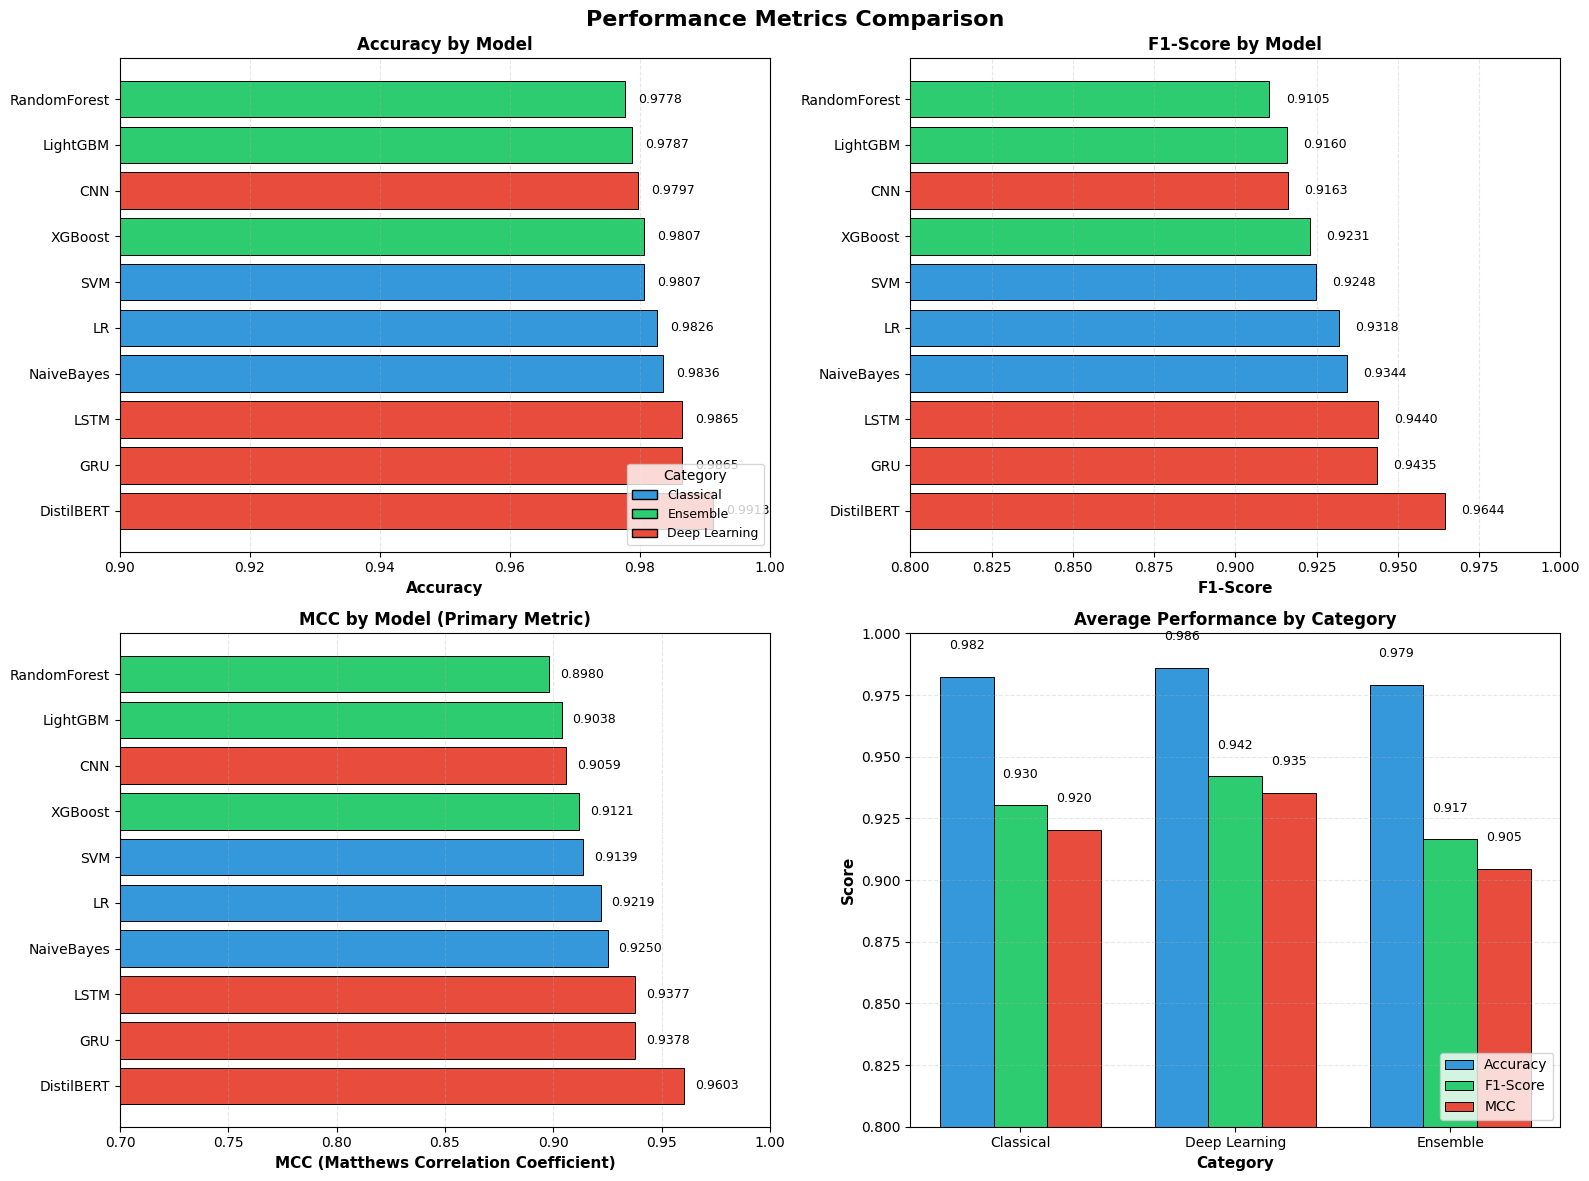

✓ Performance visualizations generated successfully!


In [42]:
# ====================================================================================
# HÜCRE 5: PERFORMANCE VISUALIZATION
# ====================================================================================

import matplotlib.pyplot as plt
import numpy as np

print("\n" + "=" * 80)
print("GENERATING PERFORMANCE VISUALIZATIONS...")
print("=" * 80)

# Prepare data from model_results
models = []
categories = []
accuracy = []
f1_scores = []
mcc_scores = []

for model_name, metrics in model_results.items():
    models.append(model_name)
    categories.append(metrics.get("Category", "Unknown"))
    accuracy.append(metrics.get("Accuracy", 0))
    f1_scores.append(metrics.get("F1_Score", 0))
    mcc_scores.append(metrics.get("MCC", 0))

# Create DataFrame for easier plotting
df_viz = pd.DataFrame({
    'Model': models,
    'Category': categories,
    'Accuracy': accuracy,
    'F1-Score': f1_scores,
    'MCC': mcc_scores
})

# Sort by MCC
df_viz = df_viz.sort_values('MCC', ascending=False)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performance Metrics Comparison', fontsize=16, fontweight='bold')

# Color mapping for categories
category_colors = {
    'Classical': '#3498db',
    'Ensemble': '#2ecc71',
    'Deep Learning': '#e74c3c'
}
colors = [category_colors.get(cat, '#95a5a6') for cat in df_viz['Category']]

# Plot 1: Accuracy comparison
ax1 = axes[0, 0]
bars1 = ax1.barh(df_viz['Model'], df_viz['Accuracy'], color=colors, edgecolor='black', linewidth=0.7)
ax1.set_xlabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Accuracy by Model', fontsize=12, fontweight='bold')
ax1.set_xlim([0.9, 1.0])
ax1.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(df_viz['Accuracy']):
    ax1.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# Plot 2: F1-Score comparison
ax2 = axes[0, 1]
bars2 = ax2.barh(df_viz['Model'], df_viz['F1-Score'], color=colors, edgecolor='black', linewidth=0.7)
ax2.set_xlabel('F1-Score', fontsize=11, fontweight='bold')
ax2.set_title('F1-Score by Model', fontsize=12, fontweight='bold')
ax2.set_xlim([0.8, 1.0])
ax2.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(df_viz['F1-Score']):
    ax2.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# Plot 3: MCC comparison
ax3 = axes[1, 0]
bars3 = ax3.barh(df_viz['Model'], df_viz['MCC'], color=colors, edgecolor='black', linewidth=0.7)
ax3.set_xlabel('MCC (Matthews Correlation Coefficient)', fontsize=11, fontweight='bold')
ax3.set_title('MCC by Model (Primary Metric)', fontsize=12, fontweight='bold')
ax3.set_xlim([0.7, 1.0])
ax3.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(df_viz['MCC']):
    ax3.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)

# Plot 4: Category-wise grouped comparison
ax4 = axes[1, 1]
category_summary = df_viz.groupby('Category')[['Accuracy', 'F1-Score', 'MCC']].mean()
x_pos = np.arange(len(category_summary))
width = 0.25

bars_acc = ax4.bar(x_pos - width, category_summary['Accuracy'], width, 
                   label='Accuracy', color='#3498db', edgecolor='black', linewidth=0.7)
bars_f1 = ax4.bar(x_pos, category_summary['F1-Score'], width, 
                  label='F1-Score', color='#2ecc71', edgecolor='black', linewidth=0.7)
bars_mcc = ax4.bar(x_pos + width, category_summary['MCC'], width, 
                   label='MCC', color='#e74c3c', edgecolor='black', linewidth=0.7)

ax4.set_xlabel('Category', fontsize=11, fontweight='bold')
ax4.set_ylabel('Score', fontsize=11, fontweight='bold')
ax4.set_title('Average Performance by Category', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(category_summary.index, fontsize=10)
ax4.legend(loc='lower right', fontsize=10)
ax4.set_ylim([0.8, 1.0])
ax4.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bars_acc, bars_f1, bars_mcc]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Legend for categories (add to first plot)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor='black', label=cat) 
                   for cat, color in category_colors.items()]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9, title='Category')

plt.tight_layout()
plt.savefig('performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Performance visualizations generated successfully!")

### 6. Efficiency Trade-offs


GENERATING EFFICIENCY TRADE-OFF VISUALIZATIONS...


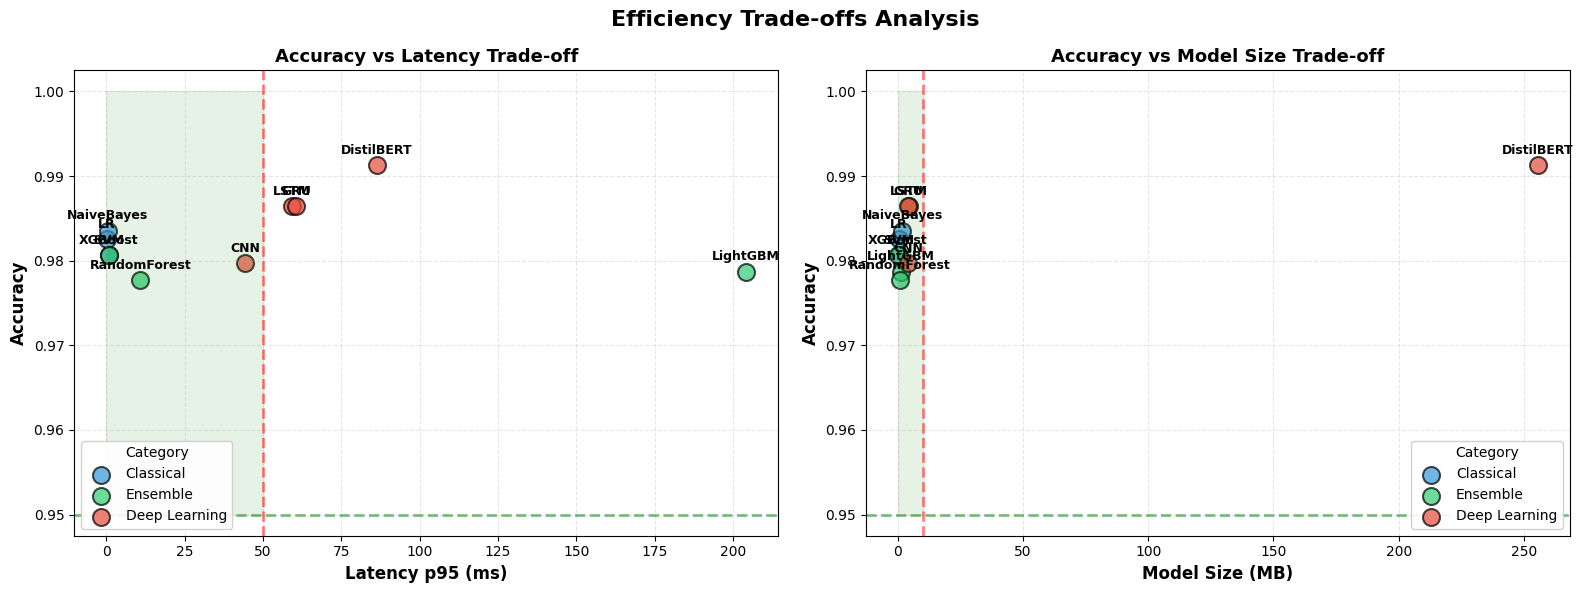

✓ Efficiency trade-off visualizations generated successfully!


In [43]:
# ====================================================================================
# HÜCRE 6: EFFICIENCY TRADE-OFFS
# ====================================================================================

print("\n" + "=" * 80)
print("GENERATING EFFICIENCY TRADE-OFF VISUALIZATIONS...")
print("=" * 80)

# Prepare data
models = []
categories = []
accuracy = []
latency_p95 = []
model_size = []

for model_name, metrics in model_results.items():
    models.append(model_name)
    categories.append(metrics.get("Category", "Unknown"))
    accuracy.append(metrics.get("Accuracy", 0))
    latency_p95.append(metrics.get("Latency_p95_ms", 0))
    model_size.append(metrics.get("Model_Size_MB", 0))

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Efficiency Trade-offs Analysis', fontsize=16, fontweight='bold')

# Color mapping
category_colors = {
    'Classical': '#3498db',
    'Ensemble': '#2ecc71',
    'Deep Learning': '#e74c3c'
}

# Plot 1: Accuracy vs Latency (p95)
ax1 = axes[0]
for category in set(categories):
    mask = [c == category for c in categories]
    acc_cat = [a for a, m in zip(accuracy, mask) if m]
    lat_cat = [l for l, m in zip(latency_p95, mask) if m]
    mod_cat = [m for m, ma in zip(models, mask) if ma]
    
    ax1.scatter(lat_cat, acc_cat, s=150, alpha=0.7, 
                color=category_colors.get(category, '#95a5a6'),
                edgecolors='black', linewidth=1.5, label=category)
    
    # Add labels
    for i, model in enumerate(mod_cat):
        ax1.annotate(model, (lat_cat[i], acc_cat[i]), 
                    textcoords="offset points", xytext=(0,8), 
                    ha='center', fontsize=9, fontweight='bold')

ax1.set_xlabel('Latency p95 (ms)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Accuracy vs Latency Trade-off', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(loc='lower left', fontsize=10, title='Category', framealpha=0.9)

# Mobile suitability zone (Latency < 50ms, Accuracy > 0.95)
ax1.axvline(x=50, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Mobile threshold (50ms)')
ax1.axhline(y=0.95, color='green', linestyle='--', linewidth=2, alpha=0.5, label='High accuracy (95%)')
ax1.fill_between([0, 50], 0.95, 1.0, alpha=0.1, color='green', label='Mobile suitability zone')

# Plot 2: Accuracy vs Model Size
ax2 = axes[1]
for category in set(categories):
    mask = [c == category for c in categories]
    acc_cat = [a for a, m in zip(accuracy, mask) if m]
    size_cat = [s for s, m in zip(model_size, mask) if m]
    mod_cat = [m for m, ma in zip(models, mask) if ma]
    
    ax2.scatter(size_cat, acc_cat, s=150, alpha=0.7,
                color=category_colors.get(category, '#95a5a6'),
                edgecolors='black', linewidth=1.5, label=category)
    
    # Add labels
    for i, model in enumerate(mod_cat):
        ax2.annotate(model, (size_cat[i], acc_cat[i]),
                    textcoords="offset points", xytext=(0,8),
                    ha='center', fontsize=9, fontweight='bold')

ax2.set_xlabel('Model Size (MB)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax2.set_title('Accuracy vs Model Size Trade-off', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(loc='lower right', fontsize=10, title='Category', framealpha=0.9)

# Mobile suitability zone (Size < 10MB, Accuracy > 0.95)
ax2.axvline(x=10, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Mobile threshold (10MB)')
ax2.axhline(y=0.95, color='green', linestyle='--', linewidth=2, alpha=0.5, label='High accuracy (95%)')
ax2.fill_between([0, 10], 0.95, 1.0, alpha=0.1, color='green', label='Mobile suitability zone')

plt.tight_layout()
plt.savefig('efficiency_tradeoffs.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Efficiency trade-off visualizations generated successfully!")

### 7. Sustainability Analysis


GENERATING SUSTAINABILITY VISUALIZATIONS...


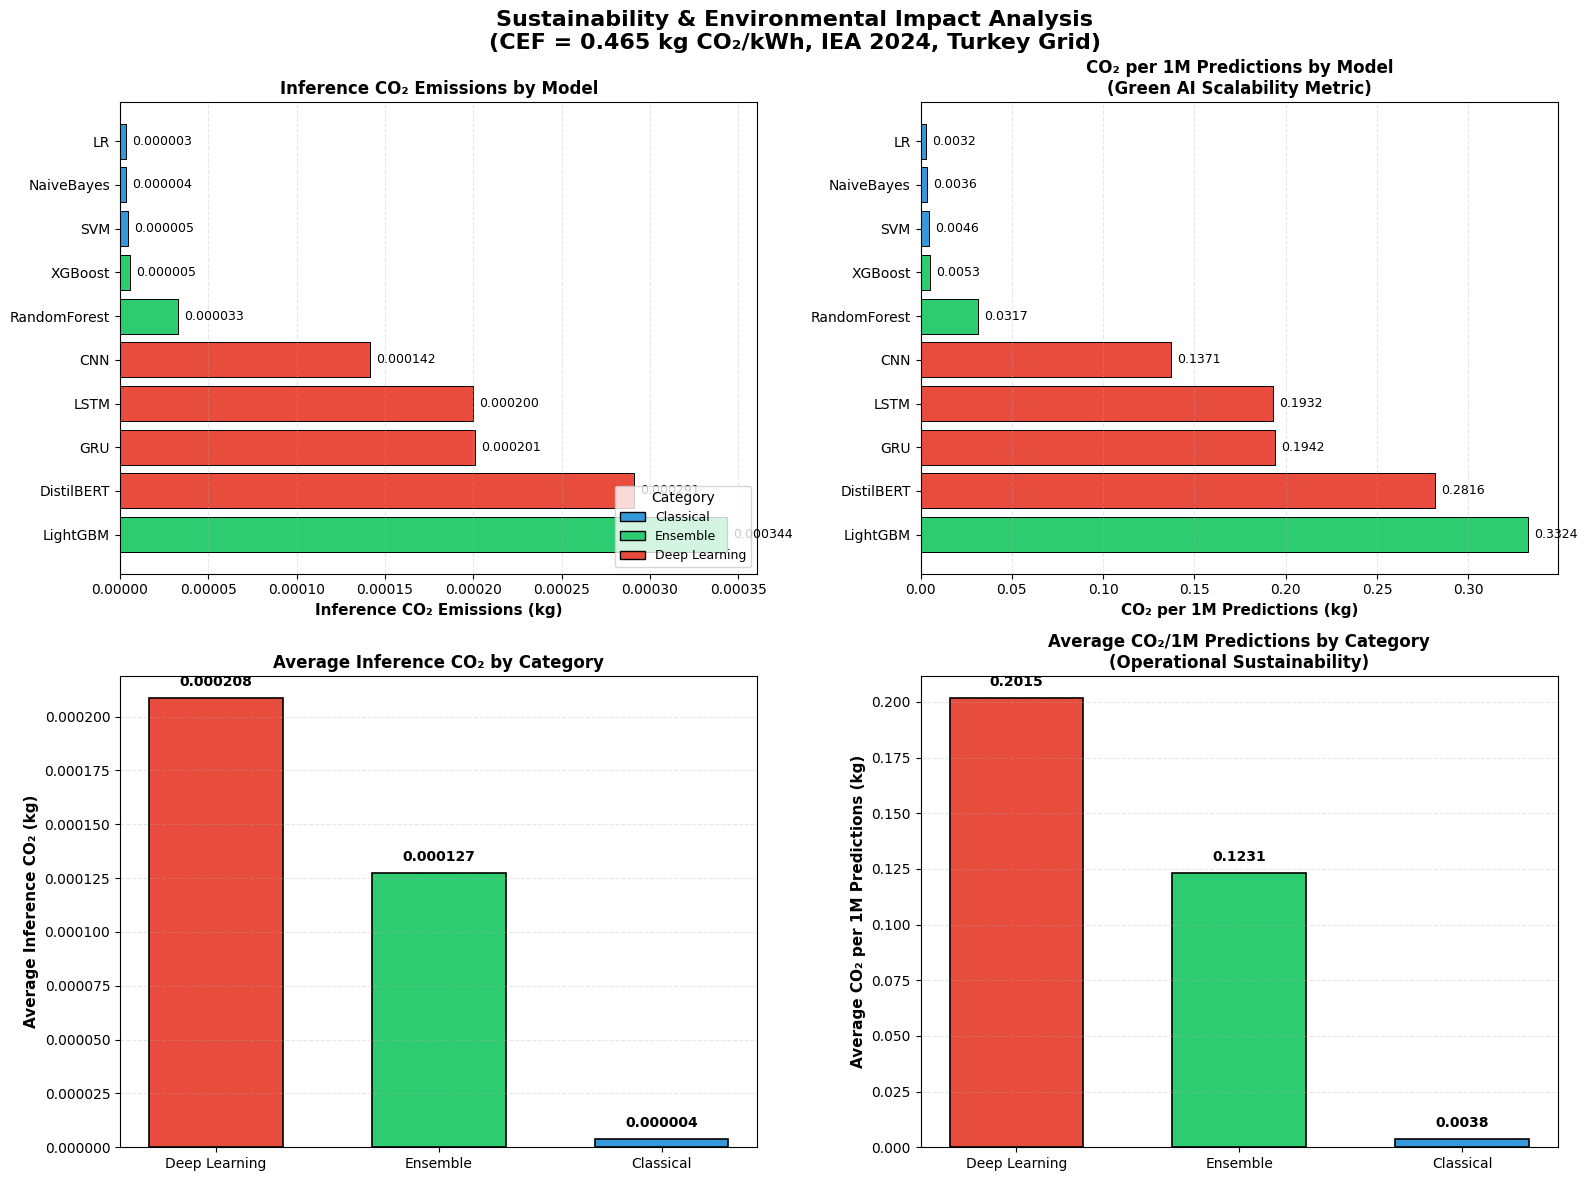

✓ Sustainability visualizations generated successfully!

📊 Summary:
   Most sustainable (inference):  LR (0.000003 kg CO₂)
   Least sustainable (inference): LightGBM (0.000344 kg CO₂)
   Average inference CO₂:         0.000123 kg
   Average CO₂/1M predictions:    0.1187 kg
   CEF (IEA 2024, Turkey):         0.465 kg CO₂/kWh = 465 gCO₂/kWh


In [44]:
# ====================================================================================
# HÜCRE 7: SUSTAINABILITY ANALYSIS
# ====================================================================================

print("\n" + "=" * 80)
print("GENERATING SUSTAINABILITY VISUALIZATIONS...")
print("=" * 80)

# Prepare data
models        = []
categories    = []
training_co2  = []
inference_co2 = []
co2_per_1M    = []
energy_kwh    = []

for model_name, metrics in model_results.items():
    models.append(model_name)
    categories.append(metrics.get("Category", "Unknown"))
    # FIX: split into training and inference CO2
    training_co2.append(metrics.get("Training_CO2_kg", 0))
    inference_co2.append(metrics.get("Inference_CO2_kg", 0))
    co2_per_1M.append(metrics.get("CO2_per_1M_pred_kg", 0))
    energy_kwh.append(metrics.get("Inference_Energy_kWh", 0))

# Create DataFrame
df_sust = pd.DataFrame({
    'Model':            models,
    'Category':         categories,
    'Training CO2 (kg)': training_co2,
    'Inference CO2 (kg)': inference_co2,
    'CO2/1M pred (kg)': co2_per_1M,
    'Inference Energy (kWh)': energy_kwh,
})

# Sort by Inference CO2 (descending for chart — highest at top)
df_sust = df_sust.sort_values('Inference CO2 (kg)', ascending=False)

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sustainability & Environmental Impact Analysis\n(CEF = 0.465 kg CO₂/kWh, IEA 2024, Turkey Grid)',
             fontsize=16, fontweight='bold')

# Color mapping
category_colors = {
    'Classical':     '#3498db',
    'Ensemble':      '#2ecc71',
    'Deep Learning': '#e74c3c'
}
colors = [category_colors.get(cat, '#95a5a6') for cat in df_sust['Category']]

# Plot 1: Inference CO2 by model
ax1 = axes[0, 0]
ax1.barh(df_sust['Model'], df_sust['Inference CO2 (kg)'], color=colors,
         edgecolor='black', linewidth=0.7)
ax1.set_xlabel('Inference CO₂ Emissions (kg)', fontsize=11, fontweight='bold')
ax1.set_title('Inference CO₂ Emissions by Model', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(df_sust['Inference CO2 (kg)']):
    ax1.text(v + max(df_sust['Inference CO2 (kg)']) * 0.01, i,
             f'{v:.6f}', va='center', fontsize=9)

# Plot 2: CO2 per 1M predictions (R1 #9 — Table 7 metric)
ax2 = axes[0, 1]
ax2.barh(df_sust['Model'], df_sust['CO2/1M pred (kg)'], color=colors,
         edgecolor='black', linewidth=0.7)
ax2.set_xlabel('CO₂ per 1M Predictions (kg)', fontsize=11, fontweight='bold')
ax2.set_title('CO₂ per 1M Predictions by Model\n(Green AI Scalability Metric)',
              fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(df_sust['CO2/1M pred (kg)']):
    ax2.text(v + max(df_sust['CO2/1M pred (kg)']) * 0.01, i,
             f'{v:.4f}', va='center', fontsize=9)

# Plot 3: Category-wise Inference CO2 comparison
ax3 = axes[1, 0]
category_co2 = df_sust.groupby('Category')['Inference CO2 (kg)'].mean().sort_values(ascending=False)
colors_cat   = [category_colors.get(cat, '#95a5a6') for cat in category_co2.index]
bars3 = ax3.bar(category_co2.index, category_co2.values, color=colors_cat,
                edgecolor='black', linewidth=1.2, width=0.6)
ax3.set_ylabel('Average Inference CO₂ (kg)', fontsize=11, fontweight='bold')
ax3.set_title('Average Inference CO₂ by Category', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(category_co2.values):
    ax3.text(i, v + max(category_co2.values) * 0.02, f'{v:.6f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: Category-wise CO2/1M predictions
ax4 = axes[1, 1]
category_1m   = df_sust.groupby('Category')['CO2/1M pred (kg)'].mean().sort_values(ascending=False)
colors_cat    = [category_colors.get(cat, '#95a5a6') for cat in category_1m.index]
bars4 = ax4.bar(category_1m.index, category_1m.values, color=colors_cat,
                edgecolor='black', linewidth=1.2, width=0.6)
ax4.set_ylabel('Average CO₂ per 1M Predictions (kg)', fontsize=11, fontweight='bold')
ax4.set_title('Average CO₂/1M Predictions by Category\n(Operational Sustainability)',
              fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3, linestyle='--')
for i, v in enumerate(category_1m.values):
    ax4.text(i, v + max(category_1m.values) * 0.02, f'{v:.4f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Category legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, edgecolor='black', label=cat)
                   for cat, color in category_colors.items()]
ax1.legend(handles=legend_elements, loc='lower right', fontsize=9, title='Category')

plt.tight_layout()
plt.savefig('sustainability_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Sustainability visualizations generated successfully!")
print("\n📊 Summary:")
print(f"   Most sustainable (inference):  {df_sust.iloc[-1]['Model']} "
      f"({df_sust.iloc[-1]['Inference CO2 (kg)']:.6f} kg CO₂)")
print(f"   Least sustainable (inference): {df_sust.iloc[0]['Model']} "
      f"({df_sust.iloc[0]['Inference CO2 (kg)']:.6f} kg CO₂)")
print(f"   Average inference CO₂:         {df_sust['Inference CO2 (kg)'].mean():.6f} kg")
print(f"   Average CO₂/1M predictions:    {df_sust['CO2/1M pred (kg)'].mean():.4f} kg")
print(f"   CEF (IEA 2024, Turkey):         0.465 kg CO₂/kWh = 465 gCO₂/kWh")
print("=" * 80)

### 8. Time Analysis


COMPREHENSIVE TIME & EFFICIENCY ANALYSIS

📊 DETAILED TIME BREAKDOWN:
------------------------------------------------------------------------------------------------------------------------
       Model      Category  CV Time (s)  Training Time (s)  Inference Time (s)  Total Time (s)  Latency Mean (ms)  Latency p95 (ms)  Latency p99 (ms)
  NaiveBayes     Classical       0.1776             0.0029              0.3796          0.5601             0.3671            0.4797            0.6272
          LR     Classical       1.3220             0.0648              0.2980          1.6848             0.2882            0.3052            0.4881
         SVM     Classical      19.2389             2.0084              0.8034         22.0507             0.7770            0.8797            0.9696
RandomForest      Ensemble      36.2483             0.6655              9.9246         46.8384             9.5983           10.9491           12.2899
     XGBoost      Ensemble      58.0378             1.3179 

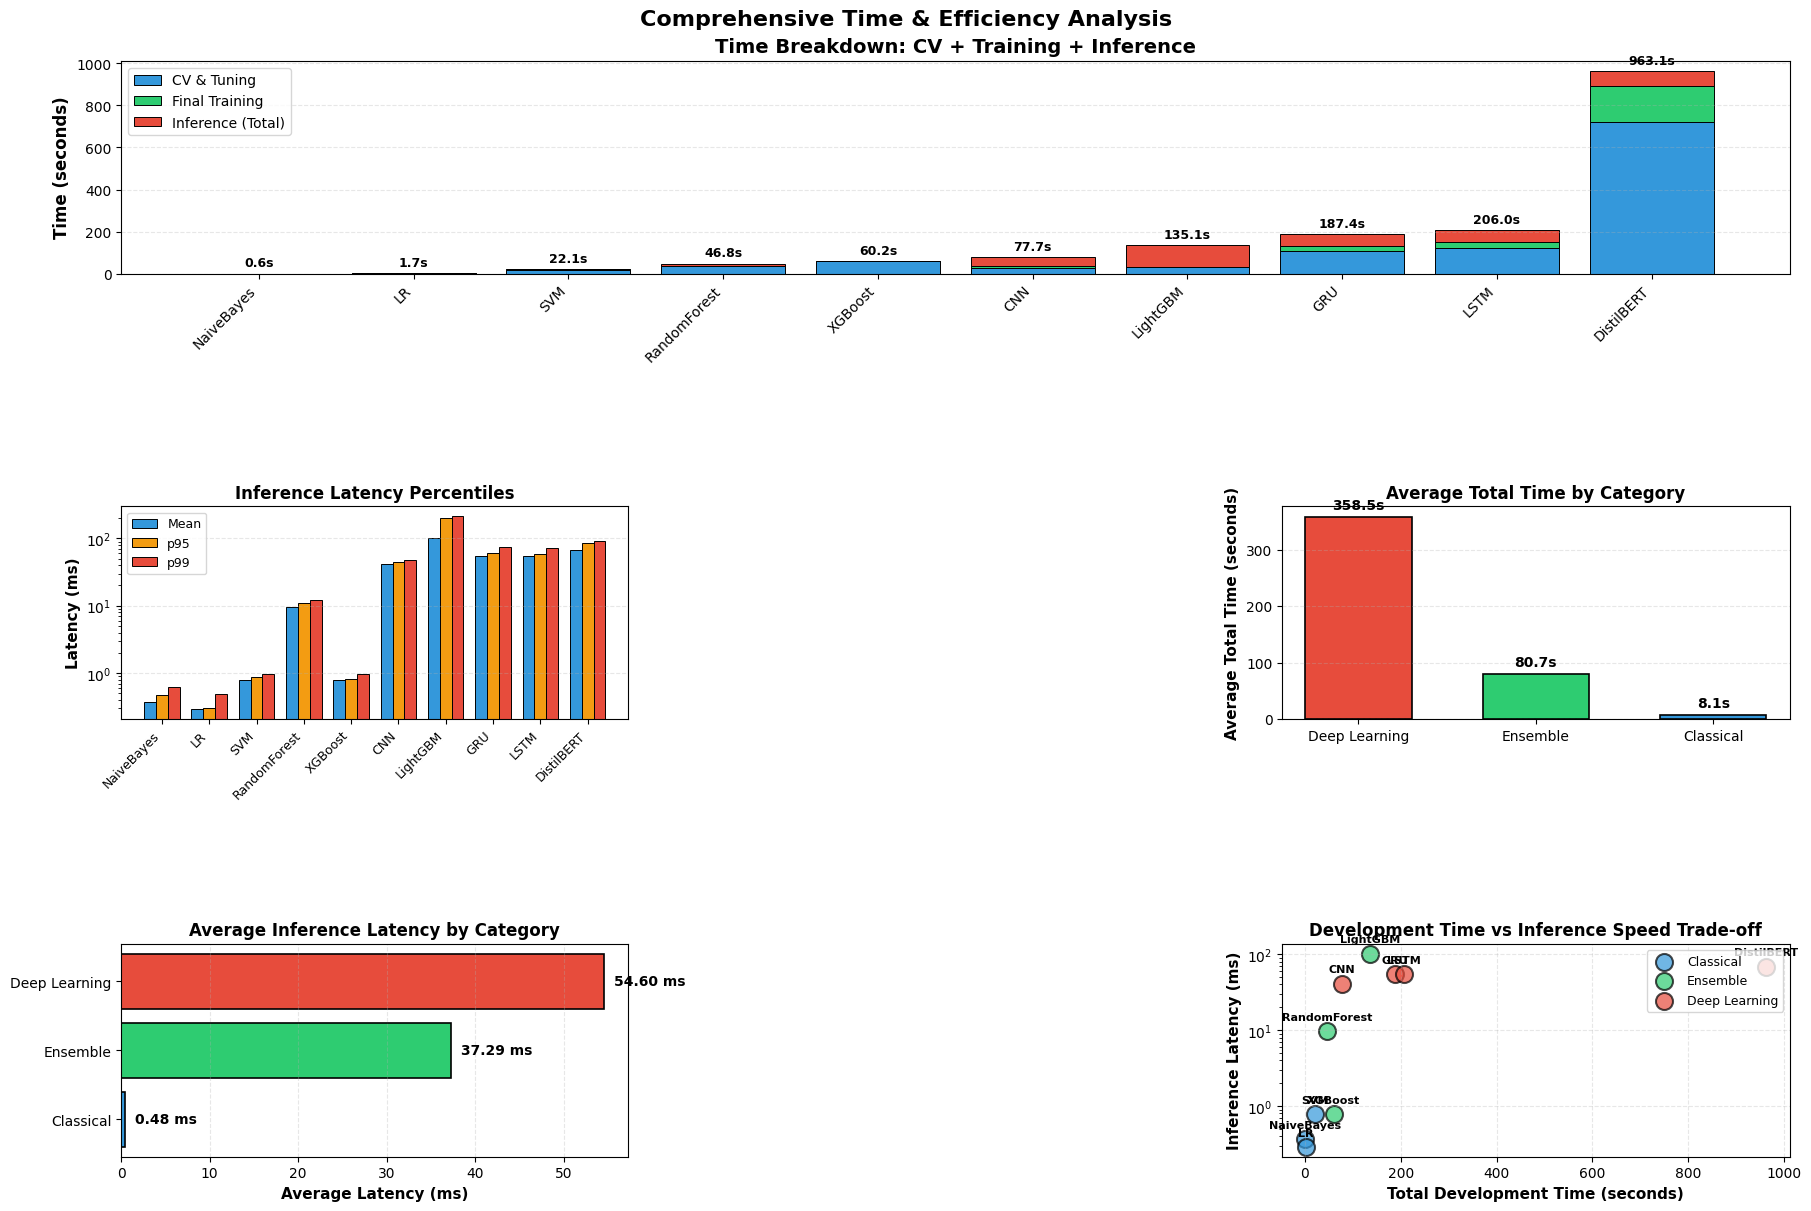


✓ Time analysis visualizations generated successfully!


In [45]:
# ====================================================================================
# HÜCRE 8: COMPREHENSIVE TIME ANALYSIS
# ====================================================================================

print("\n" + "=" * 120)
print("COMPREHENSIVE TIME & EFFICIENCY ANALYSIS")
print("=" * 120)

# Prepare data from model_results
timing_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model": model_name,
        "Category": metrics.get("Category", "Unknown"),
        "CV Time (s)": metrics.get("CV_Time", 0),
        "Training Time (s)": metrics.get("Training_Time", 0),
        "Inference Time (s)": metrics.get("Inference_Time_Sec", 0),
        "Total Time (s)": metrics.get("Total_Time", 0),
        "Latency Mean (ms)": metrics.get("Latency_ms", 0),
        "Latency p95 (ms)": metrics.get("Latency_p95_ms", 0),
        "Latency p99 (ms)": metrics.get("Latency_p99_ms", 0)
    }
    timing_data.append(row)

# Create DataFrame
df_time = pd.DataFrame(timing_data)

# Sort by Total Time
df_time = df_time.sort_values("Total Time (s)", ascending=True).reset_index(drop=True)

# Display table
print("\n📊 DETAILED TIME BREAKDOWN:")
print("-" * 120)
print(df_time.to_string(index=False, float_format="%.4f"))
print("-" * 120)

# Summary statistics
print("\n📈 TIME STATISTICS:")
print(f"   Fastest Total:     {df_time.iloc[0]['Model']:<15} ({df_time.iloc[0]['Total Time (s)']:.2f} s)")
print(f"   Slowest Total:     {df_time.iloc[-1]['Model']:<15} ({df_time.iloc[-1]['Total Time (s)']:.2f} s)")
print(f"   Fastest Inference: {df_time.nsmallest(1, 'Latency Mean (ms)').iloc[0]['Model']:<15} "
      f"({df_time.nsmallest(1, 'Latency Mean (ms)').iloc[0]['Latency Mean (ms)']:.4f} ms)")
print(f"   Slowest Inference: {df_time.nlargest(1, 'Latency Mean (ms)').iloc[0]['Model']:<15} "
      f"({df_time.nlargest(1, 'Latency Mean (ms)').iloc[0]['Latency Mean (ms)']:.4f} ms)")

# Create visualization
fig = plt.figure(figsize=(18, 12), constrained_layout=True)
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# Color mapping
category_colors = {
    'Classical': '#3498db',
    'Ensemble': '#2ecc71',
    'Deep Learning': '#e74c3c'
}

# Panel 1: Stacked Time Breakdown (CV + Training + Inference)
ax1 = fig.add_subplot(gs[0, :])
models = df_time['Model'].values
cv_times = df_time['CV Time (s)'].values
train_times = df_time['Training Time (s)'].values
inf_times = df_time['Inference Time (s)'].values

x_pos = np.arange(len(models))
p1 = ax1.bar(x_pos, cv_times, label='CV & Tuning', color='#3498db', edgecolor='black', linewidth=0.7)
p2 = ax1.bar(x_pos, train_times, bottom=cv_times, label='Final Training', 
             color='#2ecc71', edgecolor='black', linewidth=0.7)
p3 = ax1.bar(x_pos, inf_times, bottom=cv_times+train_times, label='Inference (Total)', 
             color='#e74c3c', edgecolor='black', linewidth=0.7)

ax1.set_ylabel('Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_title('Time Breakdown: CV + Training + Inference', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models, rotation=45, ha='right', fontsize=10)
ax1.legend(loc='upper left', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add total time labels on top
for i, (cv, tr, inf) in enumerate(zip(cv_times, train_times, inf_times)):
    total = cv + tr + inf
    ax1.text(i, total + max(cv_times+train_times+inf_times)*0.02, f'{total:.1f}s', 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 2: Latency Percentiles Comparison
ax2 = fig.add_subplot(gs[1, 0])
lat_mean = df_time['Latency Mean (ms)'].values
lat_p95 = df_time['Latency p95 (ms)'].values
lat_p99 = df_time['Latency p99 (ms)'].values

x_pos2 = np.arange(len(models))
width = 0.25

bars1 = ax2.bar(x_pos2 - width, lat_mean, width, label='Mean', 
                color='#3498db', edgecolor='black', linewidth=0.7)
bars2 = ax2.bar(x_pos2, lat_p95, width, label='p95', 
                color='#f39c12', edgecolor='black', linewidth=0.7)
bars3 = ax2.bar(x_pos2 + width, lat_p99, width, label='p99', 
                color='#e74c3c', edgecolor='black', linewidth=0.7)

ax2.set_ylabel('Latency (ms)', fontsize=11, fontweight='bold')
ax2.set_title('Inference Latency Percentiles', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos2)
ax2.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
ax2.legend(loc='upper left', fontsize=9)
ax2.set_yscale('log')  # Log scale for better visibility
ax2.grid(axis='y', alpha=0.3, linestyle='--')

# Panel 3: Category-wise Total Time Comparison
ax3 = fig.add_subplot(gs[1, 1])
category_time = df_time.groupby('Category')['Total Time (s)'].mean().sort_values(ascending=False)
colors_cat = [category_colors.get(cat, '#95a5a6') for cat in category_time.index]

bars_cat = ax3.bar(category_time.index, category_time.values, color=colors_cat,
                   edgecolor='black', linewidth=1.2, width=0.6)
ax3.set_ylabel('Average Total Time (seconds)', fontsize=11, fontweight='bold')
ax3.set_title('Average Total Time by Category', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, v in enumerate(category_time.values):
    ax3.text(i, v + max(category_time.values)*0.02, f'{v:.1f}s', 
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 4: Category-wise Inference Latency
ax4 = fig.add_subplot(gs[2, 0])
category_latency = df_time.groupby('Category')['Latency Mean (ms)'].mean().sort_values(ascending=True)
colors_cat2 = [category_colors.get(cat, '#95a5a6') for cat in category_latency.index]

bars_lat = ax4.barh(category_latency.index, category_latency.values, color=colors_cat2,
                    edgecolor='black', linewidth=1.2)
ax4.set_xlabel('Average Latency (ms)', fontsize=11, fontweight='bold')
ax4.set_title('Average Inference Latency by Category', fontsize=12, fontweight='bold')
ax4.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, v in enumerate(category_latency.values):
    ax4.text(v + max(category_latency.values)*0.02, i, f'{v:.2f} ms', 
            va='center', fontsize=10, fontweight='bold')

# Panel 5: Efficiency Matrix (Time vs Latency)
ax5 = fig.add_subplot(gs[2, 1])
for category in set(df_time['Category']):
    mask = df_time['Category'] == category
    ax5.scatter(df_time[mask]['Total Time (s)'], 
               df_time[mask]['Latency Mean (ms)'],
               s=150, alpha=0.7, 
               color=category_colors.get(category, '#95a5a6'),
               edgecolors='black', linewidth=1.5, 
               label=category)
    
    # Add labels
    for _, row in df_time[mask].iterrows():
        ax5.annotate(row['Model'], 
                    (row['Total Time (s)'], row['Latency Mean (ms)']),
                    textcoords="offset points", xytext=(0, 8),
                    ha='center', fontsize=8, fontweight='bold')

ax5.set_xlabel('Total Development Time (seconds)', fontsize=11, fontweight='bold')
ax5.set_ylabel('Inference Latency (ms)', fontsize=11, fontweight='bold')
ax5.set_title('Development Time vs Inference Speed Trade-off', fontsize=12, fontweight='bold')
ax5.set_yscale('log')
ax5.legend(loc='upper right', fontsize=9)
ax5.grid(True, alpha=0.3, linestyle='--')

plt.suptitle('Comprehensive Time & Efficiency Analysis', fontsize=16, fontweight='bold')
plt.savefig('comprehensive_time_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Time analysis visualizations generated successfully!")
print("=" * 120)

### 9. Overfitting Analysis


OVERFITTING & GENERALIZATION ANALYSIS

📊 GENERALIZATION PERFORMANCE:
------------------------------------------------------------------------------------------------------------------------
       Model      Category  Train Accuracy  Test Accuracy  Gen. Gap (Acc)  Train MCC  Test MCC  Gen. Gap (MCC)  CV Accuracy Mean  CV Accuracy Std  CV MCC Mean  CV MCC Std Risk Level
RandomForest      Ensemble          0.9826         0.9778          0.0048     0.9196    0.8980          0.0216            0.9799           0.0041       0.9070      0.0192      ✅ LOW
  DistilBERT Deep Learning          0.9969         0.9913          0.0056     0.9857    0.9603          0.0254            0.9889           0.0034       0.9501      0.0145      ✅ LOW
         GRU Deep Learning          0.9971         0.9865          0.0106     0.9868    0.9378          0.0490            0.9780           0.0037       0.8998      0.0170      ✅ LOW
     XGBoost      Ensemble          0.9918         0.9807          0.0111     0.9

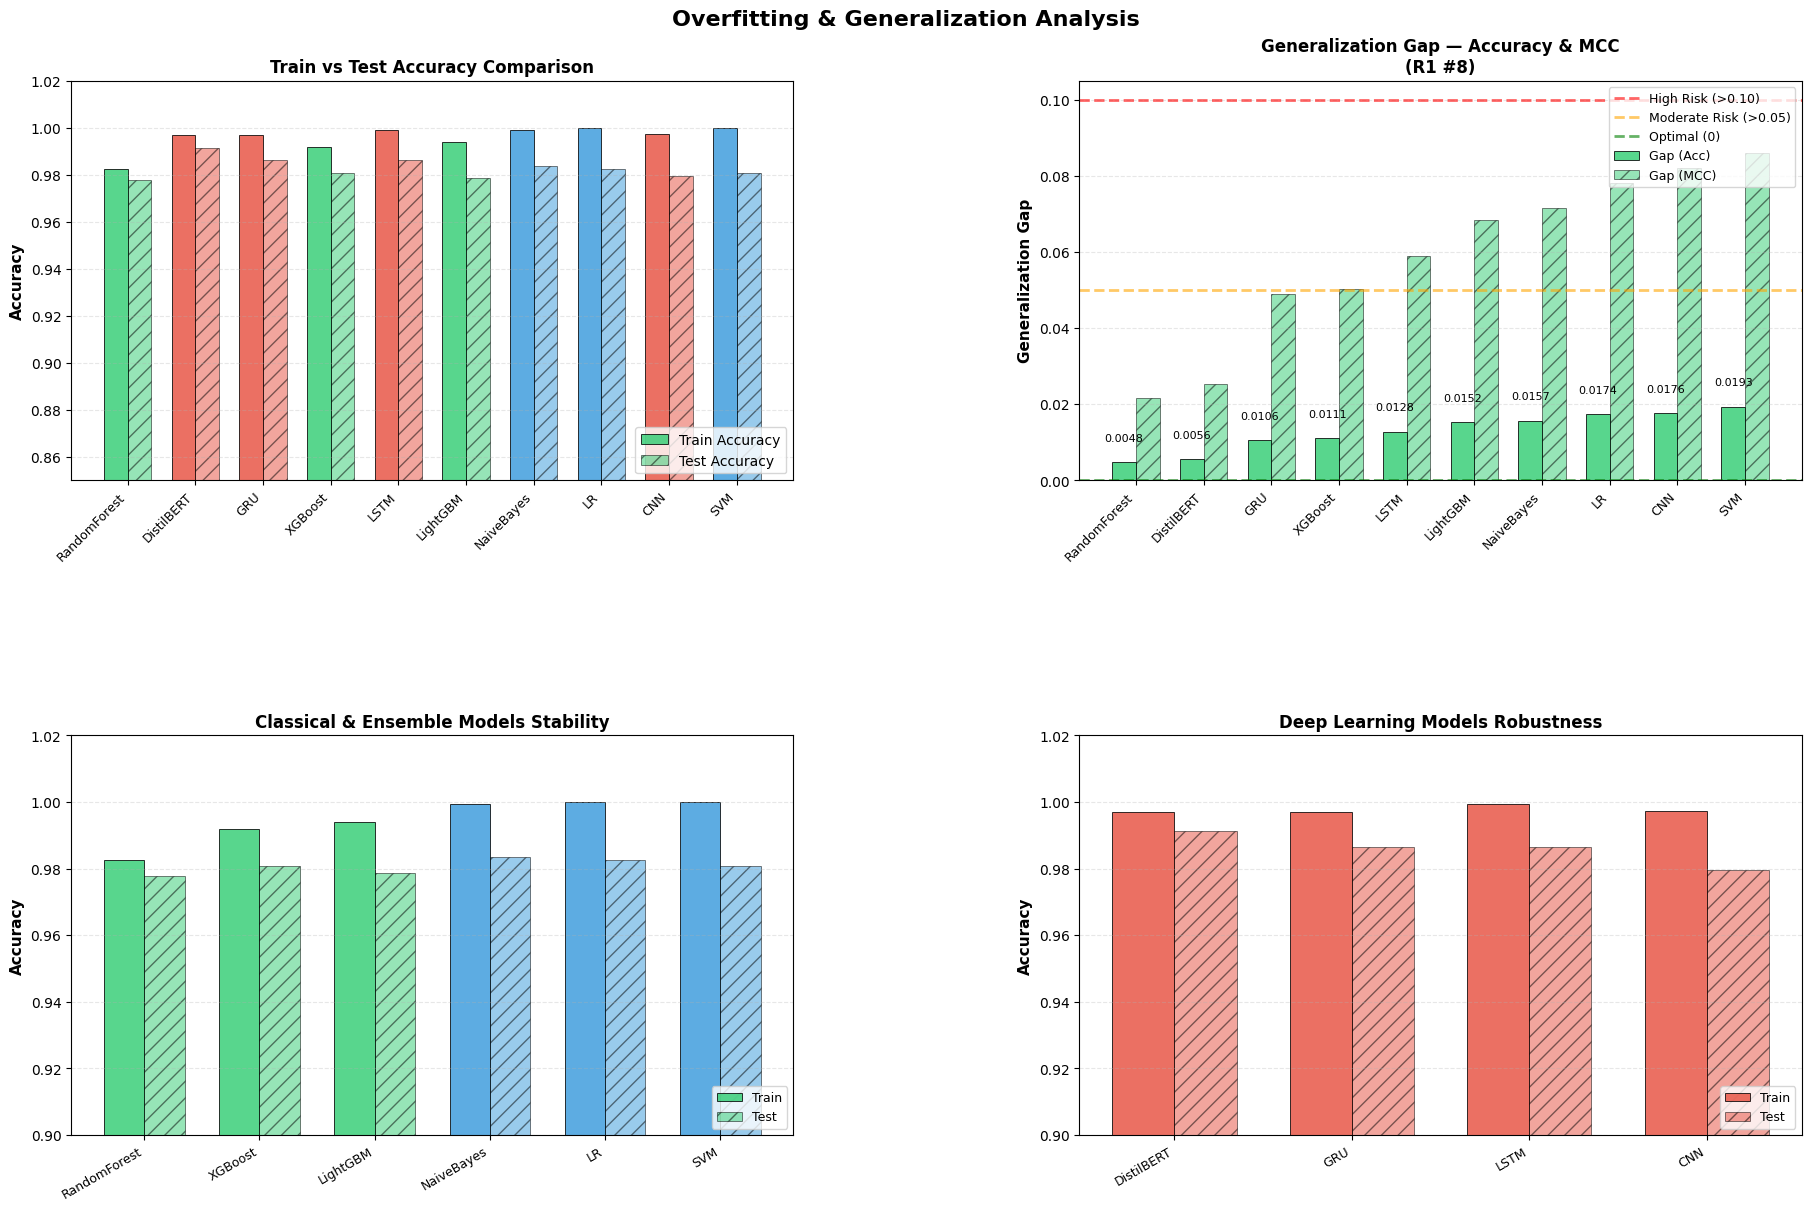


✓ Overfitting analysis visualizations generated successfully!


In [46]:
# ====================================================================================
# HÜCRE 9: OVERFITTING & GENERALIZATION ANALYSIS
# ====================================================================================

print("\n" + "=" * 120)
print("OVERFITTING & GENERALIZATION ANALYSIS")
print("=" * 120)

# Prepare data from model_results
overfitting_data = []
for model_name, metrics in model_results.items():
    row = {
        "Model":              model_name,
        "Category":           metrics.get("Category", "Unknown"),
        "Train Accuracy":     metrics.get("Train_Accuracy", 0),
        "Test Accuracy":      metrics.get("Test_Accuracy", 0),
        # FIX: key renamed to Generalization_Gap_Acc (R1 #8)
        "Gen. Gap (Acc)":     metrics.get("Generalization_Gap_Acc", 0),
        # NEW: MCC-based gap (R1 #8)
        "Train MCC":          metrics.get("Train_MCC", 0),
        "Test MCC":           metrics.get("Test_MCC", 0),
        "Gen. Gap (MCC)":     metrics.get("Generalization_Gap_MCC", 0),
        "CV Accuracy Mean":   metrics.get("CV_Accuracy_Mean", 0),
        "CV Accuracy Std":    metrics.get("CV_Accuracy_Std", 0),
        "CV MCC Mean":        metrics.get("CV_MCC_Mean", 0),
        "CV MCC Std":         metrics.get("CV_MCC_Std", 0),
    }
    overfitting_data.append(row)

df_overfit = pd.DataFrame(overfitting_data)

# Sort by Generalization Gap Acc (ascending - lower is better)
df_overfit = df_overfit.sort_values("Gen. Gap (Acc)", ascending=True).reset_index(drop=True)

# Risk classification — based on accuracy gap
df_overfit['Risk Level'] = df_overfit['Gen. Gap (Acc)'].apply(
    lambda x: "🚨 HIGH" if x > 0.10 else ("⚠️ MODERATE" if x > 0.05 else "✅ LOW")
)

# Display table
print("\n📊 GENERALIZATION PERFORMANCE:")
print("-" * 120)
print(df_overfit.to_string(index=False, float_format="%.4f"))
print("-" * 120)

# Summary statistics
print("\n📈 OVERFITTING STATISTICS:")
print(f"   Best Generalization:  {df_overfit.iloc[0]['Model']:<15} "
      f"(Gap Acc: {df_overfit.iloc[0]['Gen. Gap (Acc)']:.4f} | "
      f"Gap MCC: {df_overfit.iloc[0]['Gen. Gap (MCC)']:.4f})")
print(f"   Worst Generalization: {df_overfit.iloc[-1]['Model']:<15} "
      f"(Gap Acc: {df_overfit.iloc[-1]['Gen. Gap (Acc)']:.4f} | "
      f"Gap MCC: {df_overfit.iloc[-1]['Gen. Gap (MCC)']:.4f})")
print(f"   Average Gap (Acc):    {df_overfit['Gen. Gap (Acc)'].mean():.4f}")
print(f"   Average Gap (MCC):    {df_overfit['Gen. Gap (MCC)'].mean():.4f}")
print(f"   High Risk Models:     {len(df_overfit[df_overfit['Gen. Gap (Acc)'] > 0.10])}")
print(f"   Low Risk Models:      {len(df_overfit[df_overfit['Gen. Gap (Acc)'] <= 0.05])}")

# Category-wise summary
print("\n📊 CATEGORY-WISE GENERALIZATION:")
category_summary = df_overfit.groupby('Category').agg({
    'Gen. Gap (Acc)': ['mean', 'std', 'min', 'max'],
    'Gen. Gap (MCC)': ['mean', 'std', 'min', 'max'],
}).round(4)
print(category_summary)

# Create visualization
fig = plt.figure(figsize=(18, 12), constrained_layout=True)
gs  = fig.add_gridspec(2, 2, hspace=0.25, wspace=0.25)

category_colors = {
    'Classical':     '#3498db',
    'Ensemble':      '#2ecc71',
    'Deep Learning': '#e74c3c'
}

# Panel 1: Train vs Test Accuracy
ax1   = fig.add_subplot(gs[0, 0])
x_pos = np.arange(len(df_overfit))
width = 0.35

colors_cat = [category_colors.get(cat, '#95a5a6') for cat in df_overfit['Category']]

ax1.bar(x_pos - width/2, df_overfit['Train Accuracy'], width,
        label='Train Accuracy', color=colors_cat, alpha=0.8,
        edgecolor='black', linewidth=0.7)
ax1.bar(x_pos + width/2, df_overfit['Test Accuracy'], width,
        label='Test Accuracy', color=colors_cat, alpha=0.5,
        edgecolor='black', linewidth=0.7, hatch='//')

ax1.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
ax1.set_title('Train vs Test Accuracy Comparison', fontsize=12, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(df_overfit['Model'], rotation=45, ha='right', fontsize=9)
ax1.legend(loc='lower right', fontsize=10)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_ylim([0.85, 1.02])

# Panel 2: Generalization Gap Acc + MCC side by side
ax2 = fig.add_subplot(gs[0, 1])
gap_colors = ['#e74c3c' if g > 0.10 else '#f39c12' if g > 0.05 else '#2ecc71'
              for g in df_overfit['Gen. Gap (Acc)']]

x_pos2 = np.arange(len(df_overfit))
ax2.bar(x_pos2 - width/2, df_overfit['Gen. Gap (Acc)'], width,
        color=gap_colors, edgecolor='black', linewidth=0.7, alpha=0.8, label='Gap (Acc)')
ax2.bar(x_pos2 + width/2, df_overfit['Gen. Gap (MCC)'], width,
        color=gap_colors, edgecolor='black', linewidth=0.7, alpha=0.5,
        hatch='//', label='Gap (MCC)')

ax2.set_ylabel('Generalization Gap', fontsize=11, fontweight='bold')
ax2.set_title('Generalization Gap — Accuracy & MCC\n(R1 #8)', fontsize=12, fontweight='bold')
ax2.set_xticks(x_pos2)
ax2.set_xticklabels(df_overfit['Model'], rotation=45, ha='right', fontsize=9)
ax2.axhline(y=0.10, color='red',    linestyle='--', linewidth=2, alpha=0.6, label='High Risk (>0.10)')
ax2.axhline(y=0.05, color='orange', linestyle='--', linewidth=2, alpha=0.6, label='Moderate Risk (>0.05)')
ax2.axhline(y=0.00, color='green',  linestyle='--', linewidth=2, alpha=0.6, label='Optimal (0)')
ax2.legend(loc='upper right', fontsize=9)
ax2.grid(axis='y', alpha=0.3, linestyle='--')

for i, v in enumerate(df_overfit['Gen. Gap (Acc)']):
    ax2.text(i - width/2, v + 0.005, f'{v:.4f}', ha='center', va='bottom', fontsize=8)

# Panel 3: Classical & Ensemble stability
ax3 = fig.add_subplot(gs[1, 0])
df_ce = df_overfit[df_overfit['Category'].isin(['Classical', 'Ensemble'])]

if not df_ce.empty:
    x_ce     = np.arange(len(df_ce))
    colors_ce = [category_colors.get(cat, '#95a5a6') for cat in df_ce['Category']]

    ax3.bar(x_ce - width/2, df_ce['Train Accuracy'], width,
            label='Train', color=colors_ce, alpha=0.8, edgecolor='black', linewidth=0.7)
    ax3.bar(x_ce + width/2, df_ce['Test Accuracy'], width,
            label='Test',  color=colors_ce, alpha=0.5, edgecolor='black',
            linewidth=0.7, hatch='//')

    ax3.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax3.set_title('Classical & Ensemble Models Stability', fontsize=12, fontweight='bold')
    ax3.set_xticks(x_ce)
    ax3.set_xticklabels(df_ce['Model'], rotation=30, ha='right', fontsize=9)
    ax3.legend(loc='lower right', fontsize=9)
    ax3.grid(axis='y', alpha=0.3, linestyle='--')
    ax3.set_ylim([0.90, 1.02])

# Panel 4: Deep Learning robustness
ax4 = fig.add_subplot(gs[1, 1])
df_dl = df_overfit[df_overfit['Category'] == 'Deep Learning']

if not df_dl.empty:
    x_dl     = np.arange(len(df_dl))
    color_dl = category_colors.get('Deep Learning', '#e74c3c')

    ax4.bar(x_dl - width/2, df_dl['Train Accuracy'], width,
            label='Train', color=color_dl, alpha=0.8, edgecolor='black', linewidth=0.7)
    ax4.bar(x_dl + width/2, df_dl['Test Accuracy'], width,
            label='Test',  color=color_dl, alpha=0.5, edgecolor='black',
            linewidth=0.7, hatch='//')

    ax4.set_ylabel('Accuracy', fontsize=11, fontweight='bold')
    ax4.set_title('Deep Learning Models Robustness', fontsize=12, fontweight='bold')
    ax4.set_xticks(x_dl)
    ax4.set_xticklabels(df_dl['Model'], rotation=30, ha='right', fontsize=9)
    ax4.legend(loc='lower right', fontsize=9)
    ax4.grid(axis='y', alpha=0.3, linestyle='--')
    ax4.set_ylim([0.90, 1.02])

plt.suptitle('Overfitting & Generalization Analysis', fontsize=16, fontweight='bold')
plt.savefig('overfitting_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Overfitting analysis visualizations generated successfully!")
print("=" * 120)

### 10. ALL CONFUSION MATRICES


 Final styled confusion matrices saved as 'confusion_matrices_final_styled.png'


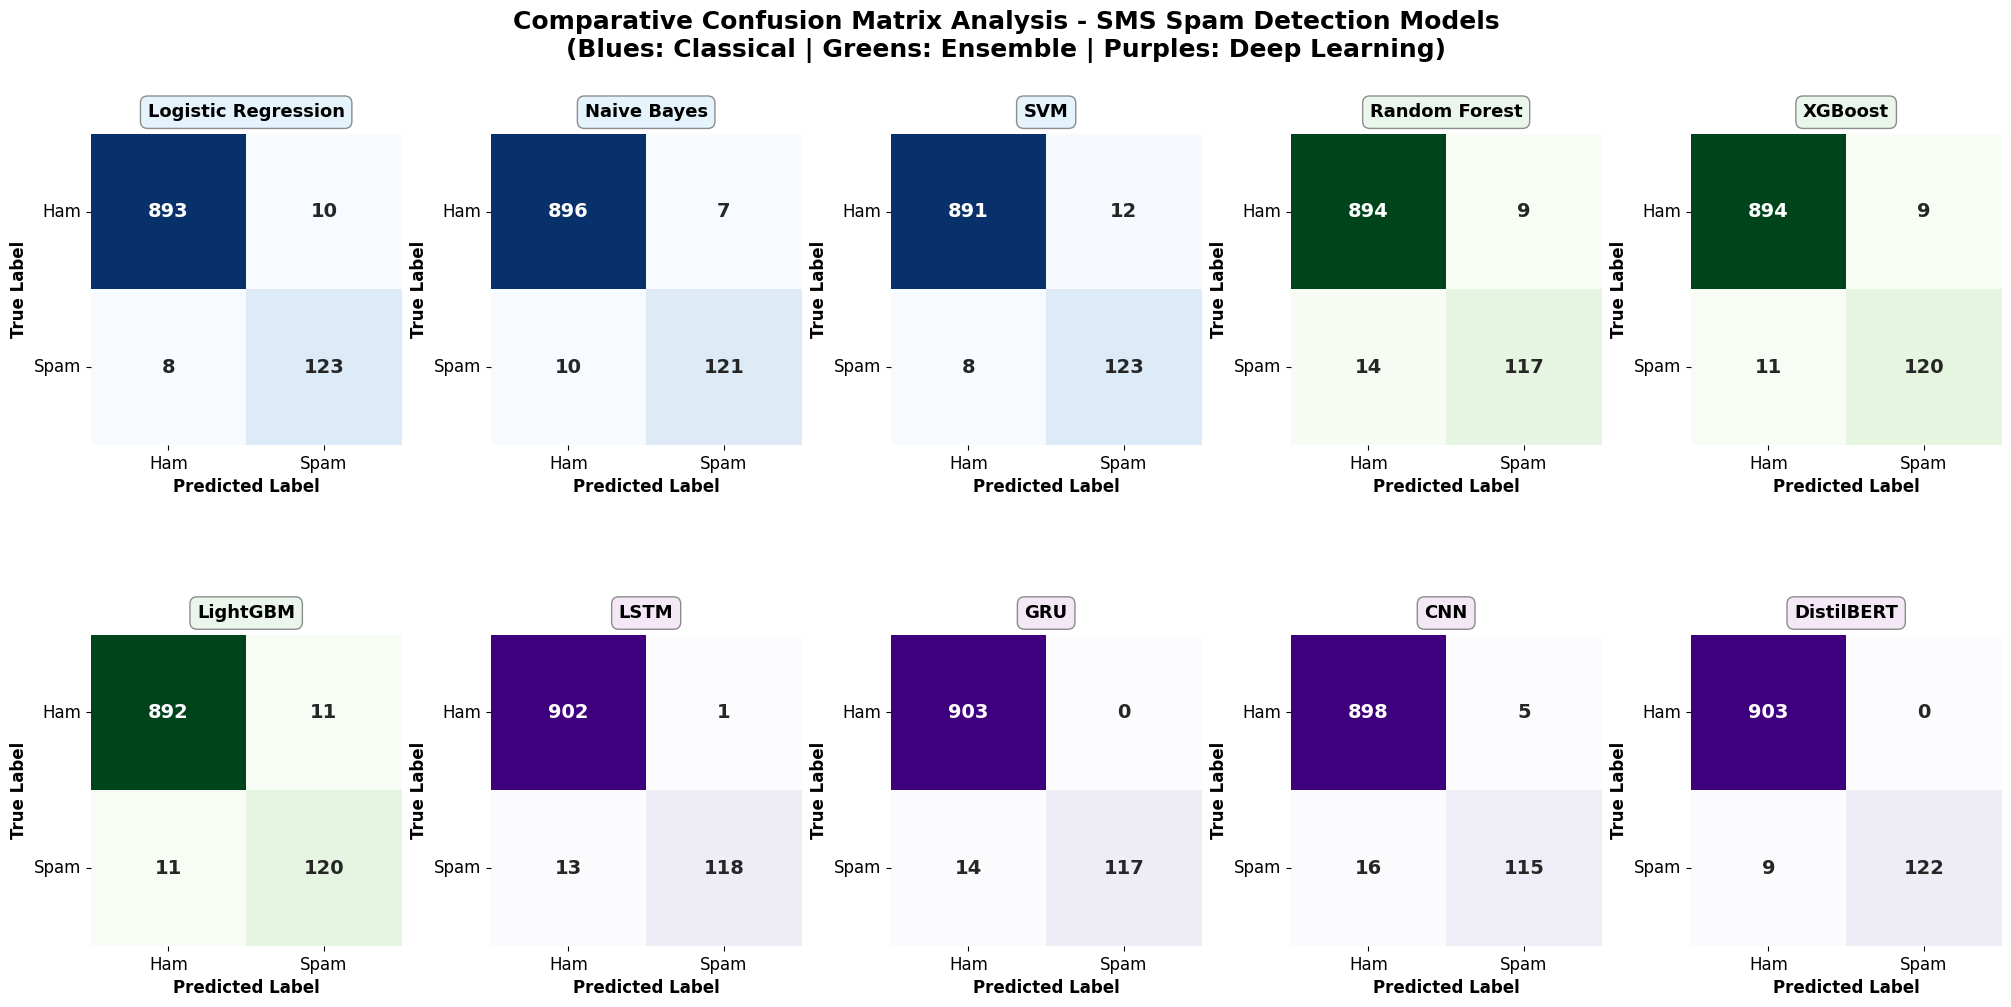

In [47]:
# =============================================================================
# CELL 18: ALL CONFUSION MATRICES - CATEGORIZED BY COLOR (FINAL 10 MODELS)
# =============================================================================

# 1. Memory Cleanup and Layout Settings
plt.close('all')

# 2. Define Final 10 Models (Mapped to SMS Spam Project Variables)
model_map_config = [
    # Classical (Blue)
    ("Logistic Regression", "best_lr_predict",  "Classical"),
    ("Naive Bayes",         "best_nb_predict",  "Classical"),
    ("SVM",                 "best_svm_predict", "Classical"),
    
    # Ensemble (Green)
    ("Random Forest",       "best_rf_predict",  "Ensemble"),
    ("XGBoost",             "best_xgb_predict", "Ensemble"),
    ("LightGBM",            "best_lgbm_predict", "Ensemble"),
 
    # Deep Learning (Purple)
    ("LSTM",                "best_lstm_predict", "Deep Learning"),
    ("GRU",                 "best_gru_predict",  "Deep Learning"),
    ("CNN",                 "best_cnn_predict",  "Deep Learning"),
    ("DistilBERT",          "best_bert_predict", "Deep Learning")
]

# Check for active models in memory to avoid errors
active_models = []
for name, var_name, category in model_map_config:
    if var_name in globals():
        active_models.append((name, globals()[var_name], category))
    else:
        print(f" {name} skipped (Not trained yet).")

if not active_models:
    print(" ERROR: No model results found in memory.")
else:
    # 3. Dynamic Grid Setup
    num_models = len(active_models)
    cols = 5  # Optimized for 10 models (2 Rows x 5 Columns)
    rows = (num_models // cols) + (1 if num_models % cols > 0 else 0)
    
    # Adjusted figsize to match the template's proportions
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows), layout='constrained')
    axes = axes.ravel() 
    
    # 4. Color Palettes and Themes (Template Style)
    category_colors = {
        'Classical': 'Blues',
        'Ensemble': 'Greens', 
        'Deep Learning': 'Purples' # Template requested Purples
    }
    
    background_colors = {
        'Classical': '#E3F2FD', 
        'Ensemble': '#E8F5E9', 
        'Deep Learning': '#F3E5F5'
    }

    # 5. Drawing Loop
    for idx, (name, pred, category) in enumerate(active_models):
        y_true = y_test 
        
        # Flatten deep learning predictions if necessary
        if hasattr(pred, "ndim") and pred.ndim > 1: 
            pred = pred.flatten()
        
        cm = confusion_matrix(y_true, pred)
        
        # Heatmap plotting (Template styling)
        sns.heatmap(cm, annot=True, fmt='d', cmap=category_colors[category], 
                    ax=axes[idx], cbar=False, square=True, 
                    annot_kws={'size': 14, 'weight': 'bold'}) # Font size 14 as per template style
        
        # Title and Header Style (Rounded Box)
        axes[idx].set_title(f'{name}', 
                            fontsize=13, fontweight='bold', pad=12,
                            bbox=dict(boxstyle='round,pad=0.4', 
                                      facecolor=background_colors[category],
                                      edgecolor='gray',
                                      alpha=0.9))
                                      
        axes[idx].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('True Label', fontsize=12, fontweight='bold')
        
        # Labels: Ham vs Spam
        axes[idx].set_xticklabels(['Ham', 'Spam'], fontsize=12)
        axes[idx].set_yticklabels(['Ham', 'Spam'], fontsize=12, rotation=0)

    # 6. Hide empty subplots
    for i in range(num_models, len(axes)):
        axes[i].axis('off')

    # 7. Final Suptitle and Save
    plt.suptitle('Comparative Confusion Matrix Analysis - SMS Spam Detection Models\n(Blues: Classical | Greens: Ensemble | Purples: Deep Learning)', 
                 fontsize=18, fontweight='bold', y=1.03)

    try:
        plt.savefig('confusion_matrices_final_styled.png', dpi=300, bbox_inches='tight')
        print("\n Final styled confusion matrices saved as 'confusion_matrices_final_styled.png'")
    except Exception as e:
        print(f"\n Save failed: {e}")

    plt.show()

## 11. FEATURE IMPORTANCE (AUTO-REPAIR & VISUALIZATION)


🛠️ SYSTEM CHECK: CountVectorizer ('cv') Status
⚠️ WARNING: 'cv' is missing, corrupted, or has wrong vocabulary size.
   Expected: 57376 | Found: N/A
🔄 Rebuilding and refitting CountVectorizer...
✅ SUCCESS: CountVectorizer repaired.
   Vocabulary Size: 57376
✅ Array sizes consistent: 57376 features

📊 FEATURE IMPORTANCE VISUALIZATION
✅ Saved: 'Spam_Feature_Importance_LR_XGB.png'


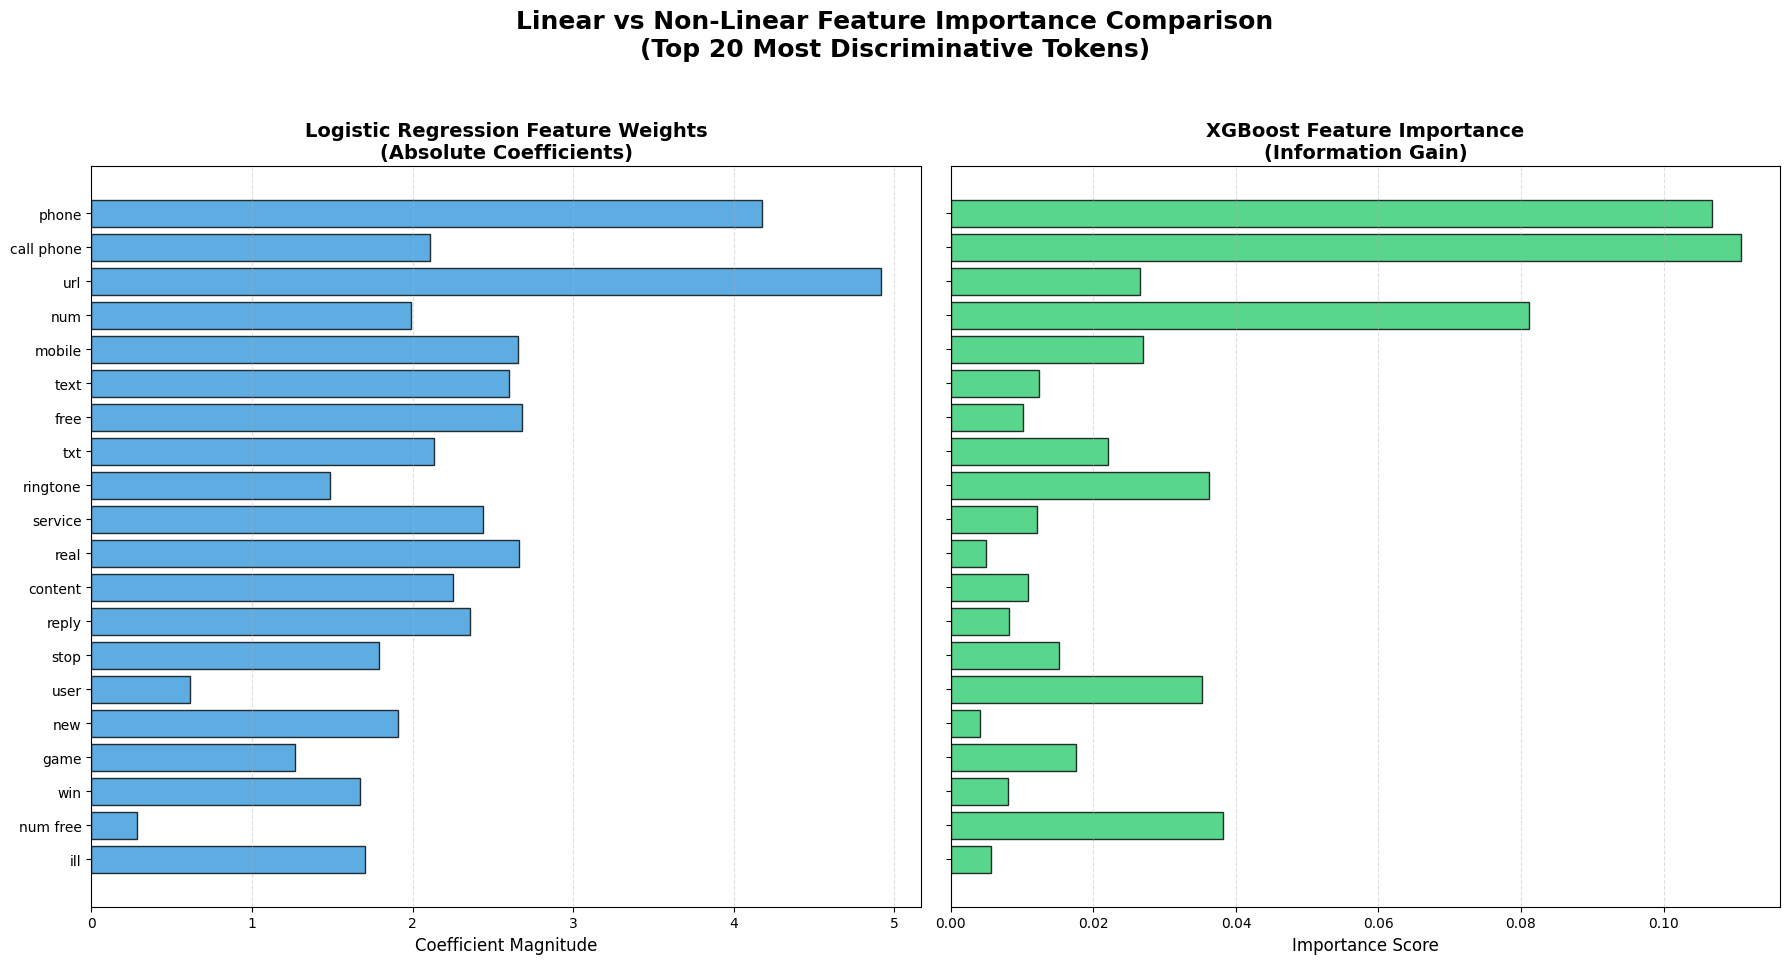


🏆 Top 10 Most Important Words:
   Feature  LogisticRegression  XGBoost
     phone            4.177084 0.106817
call phone            2.106882 0.110805
       url            4.917174 0.026538
       num            1.987624 0.081112
    mobile            2.654856 0.026994
      text            2.602271 0.012406
      free            2.680227 0.010151
       txt            2.134216 0.022042
  ringtone            1.487831 0.036275
   service            2.435210 0.012123


In [49]:
# =============================================================================
# FEATURE IMPORTANCE (AUTO-REPAIR & VISUALIZATION)
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.feature_extraction.text import CountVectorizer

print("\n" + "=" * 100)
print("🛠️ SYSTEM CHECK: CountVectorizer ('cv') Status")
print("=" * 100)

# -----------------------------------------------------------------------------
# 1. AUTO-REPAIR
# -----------------------------------------------------------------------------
# Expected vocabulary size — must match best_lr.coef_ and best_xgb.feature_importances_
EXPECTED_VOCAB_SIZE = best_lr.coef_.shape[1] if 'best_lr' in globals() else 57376

# Repair if: cv missing, lacks get_feature_names_out, OR vocabulary size mismatch
cv_needs_repair = (
    'cv' not in globals()
    or not hasattr(cv, 'get_feature_names_out')
    or len(cv.vocabulary_) != EXPECTED_VOCAB_SIZE
)

if cv_needs_repair:
    print("⚠️ WARNING: 'cv' is missing, corrupted, or has wrong vocabulary size.")
    print(f"   Expected: {EXPECTED_VOCAB_SIZE} | Found: {len(cv.vocabulary_) if 'cv' in globals() and hasattr(cv, 'vocabulary_') else 'N/A'}")
    print("🔄 Rebuilding and refitting CountVectorizer...")

    col_name = "text_classical" if "text_classical" in df.columns else "text"

    try:
        # DATA LEAKAGE PREVENTION (R1 #8):
        # Re-derive train split using same parameters as Cell 23.
        # This is necessary because LSTM/GRU/CNN CV loops overwrite
        # the global train_idx variable with fold indices.
        from sklearn.model_selection import train_test_split as _tts_cv
        _train_idx_cv, _ = _tts_cv(
            df.index, test_size=0.2, random_state=42, stratify=df['target']
        )
        cv = CountVectorizer(min_df=0.0, max_df=1.0, binary=False, ngram_range=(1, 3))
        cv.fit(df.loc[_train_idx_cv, col_name])

        assert len(cv.vocabulary_) == EXPECTED_VOCAB_SIZE, \
            f"Vocabulary size mismatch after repair: {len(cv.vocabulary_)} != {EXPECTED_VOCAB_SIZE}"

        print(f"✅ SUCCESS: CountVectorizer repaired.")
        print(f"   Vocabulary Size: {len(cv.vocabulary_)}")
    except Exception as e:
        print(f"❌ ERROR: Repair failed.\nError: {e}")
        raise
else:
    print(f"✅ STATUS: 'cv' object is intact and ready.")
    print(f"   Vocabulary Size: {len(cv.vocabulary_)}")

# -----------------------------------------------------------------------------
# 2. PRE-FLIGHT CHECK — verify all arrays match before DataFrame creation
# -----------------------------------------------------------------------------
feature_names = cv.get_feature_names_out()
lr_imp        = np.abs(best_lr.coef_[0])  if 'best_lr'  in globals() else None
xgb_imp       = best_xgb.feature_importances_ if 'best_xgb' in globals() else None

if lr_imp is not None and xgb_imp is not None:
    assert len(feature_names) == len(lr_imp),  f"Size mismatch: feature_names={len(feature_names)}, lr_imp={len(lr_imp)}"
    assert len(feature_names) == len(xgb_imp), f"Size mismatch: feature_names={len(feature_names)}, xgb_imp={len(xgb_imp)}"
    print(f"✅ Array sizes consistent: {len(feature_names)} features")

# -----------------------------------------------------------------------------
# 3. FEATURE IMPORTANCE ANALYSIS (LR vs XGBoost)
# -----------------------------------------------------------------------------
print("\n" + "=" * 100)
print("📊 FEATURE IMPORTANCE VISUALIZATION")
print("=" * 100)

if 'best_lr' in globals() and 'best_xgb' in globals():

    df_imp = pd.DataFrame({
        'Feature':            feature_names,
        'LogisticRegression': lr_imp,
        'XGBoost':            xgb_imp
    })

    # Normalize to [0, 1]
    df_imp['LR_Norm']  = df_imp['LogisticRegression'] / df_imp['LogisticRegression'].max()
    df_imp['XGB_Norm'] = df_imp['XGBoost'] / df_imp['XGBoost'].max()

    # Sort by mean importance score and take top 20
    df_imp['Mean_Score'] = (df_imp['LR_Norm'] + df_imp['XGB_Norm']) / 2
    df_plot = df_imp.sort_values('Mean_Score', ascending=False).head(20)
    df_plot = df_plot.sort_values('Mean_Score', ascending=True)  # Reverse for horizontal bar

    # Visualization
    plt.close('all')
    fig, axes = plt.subplots(1, 2, figsize=(18, 10), sharey=True)

    # Plot 1: Logistic Regression
    axes[0].barh(df_plot['Feature'], df_plot['LogisticRegression'],
                 color='#3498db', alpha=0.8, edgecolor='black')
    axes[0].set_title('Logistic Regression Feature Weights\n(Absolute Coefficients)',
                      fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Coefficient Magnitude', fontsize=12)
    axes[0].grid(axis='x', linestyle='--', alpha=0.4)

    # Plot 2: XGBoost
    axes[1].barh(df_plot['Feature'], df_plot['XGBoost'],
                 color='#2ecc71', alpha=0.8, edgecolor='black')
    axes[1].set_title('XGBoost Feature Importance\n(Information Gain)',
                      fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Importance Score', fontsize=12)
    axes[1].grid(axis='x', linestyle='--', alpha=0.4)

    plt.suptitle(
        'Linear vs Non-Linear Feature Importance Comparison\n(Top 20 Most Discriminative Tokens)',
        fontsize=18, fontweight='bold', y=0.96
    )

    plt.tight_layout(rect=[0, 0, 1, 0.93])

    try:
        plt.savefig('Spam_Feature_Importance_LR_XGB.png', dpi=300, bbox_inches='tight')
        print("✅ Saved: 'Spam_Feature_Importance_LR_XGB.png'")
    except:
        pass

    plt.show()

    print("\n🏆 Top 10 Most Important Words:")
    print(df_plot.sort_values('Mean_Score', ascending=False)[
        ['Feature', 'LogisticRegression', 'XGBoost']
    ].head(10).to_string(index=False))

else:
    print("⚠️ ERROR: 'best_lr' or 'best_xgb' not found in memory. Please train models first.")